In [1]:
from ssh_chain import PHOTONICChain as model
import graphics_template
import matplotlib.pyplot as plt
import numpy as np

In [10]:
N = 20
Omega_C = 0.9
Chi_C = 0.1
omega_r = 4
gamma = 0.01
fock_photon = 5
Omega_J = 1.0
Chi_J = 0.0

photonic_chain_obc = model(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, PBC = False)
photonic_chain_pbc = model(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, PBC = True)

conversion_matrix = photonic_chain_obc.inverse_P @ photonic_chain_pbc.P
# photonic_chain.matter_hamiltonians(n_excitations= 1, layers= 0)

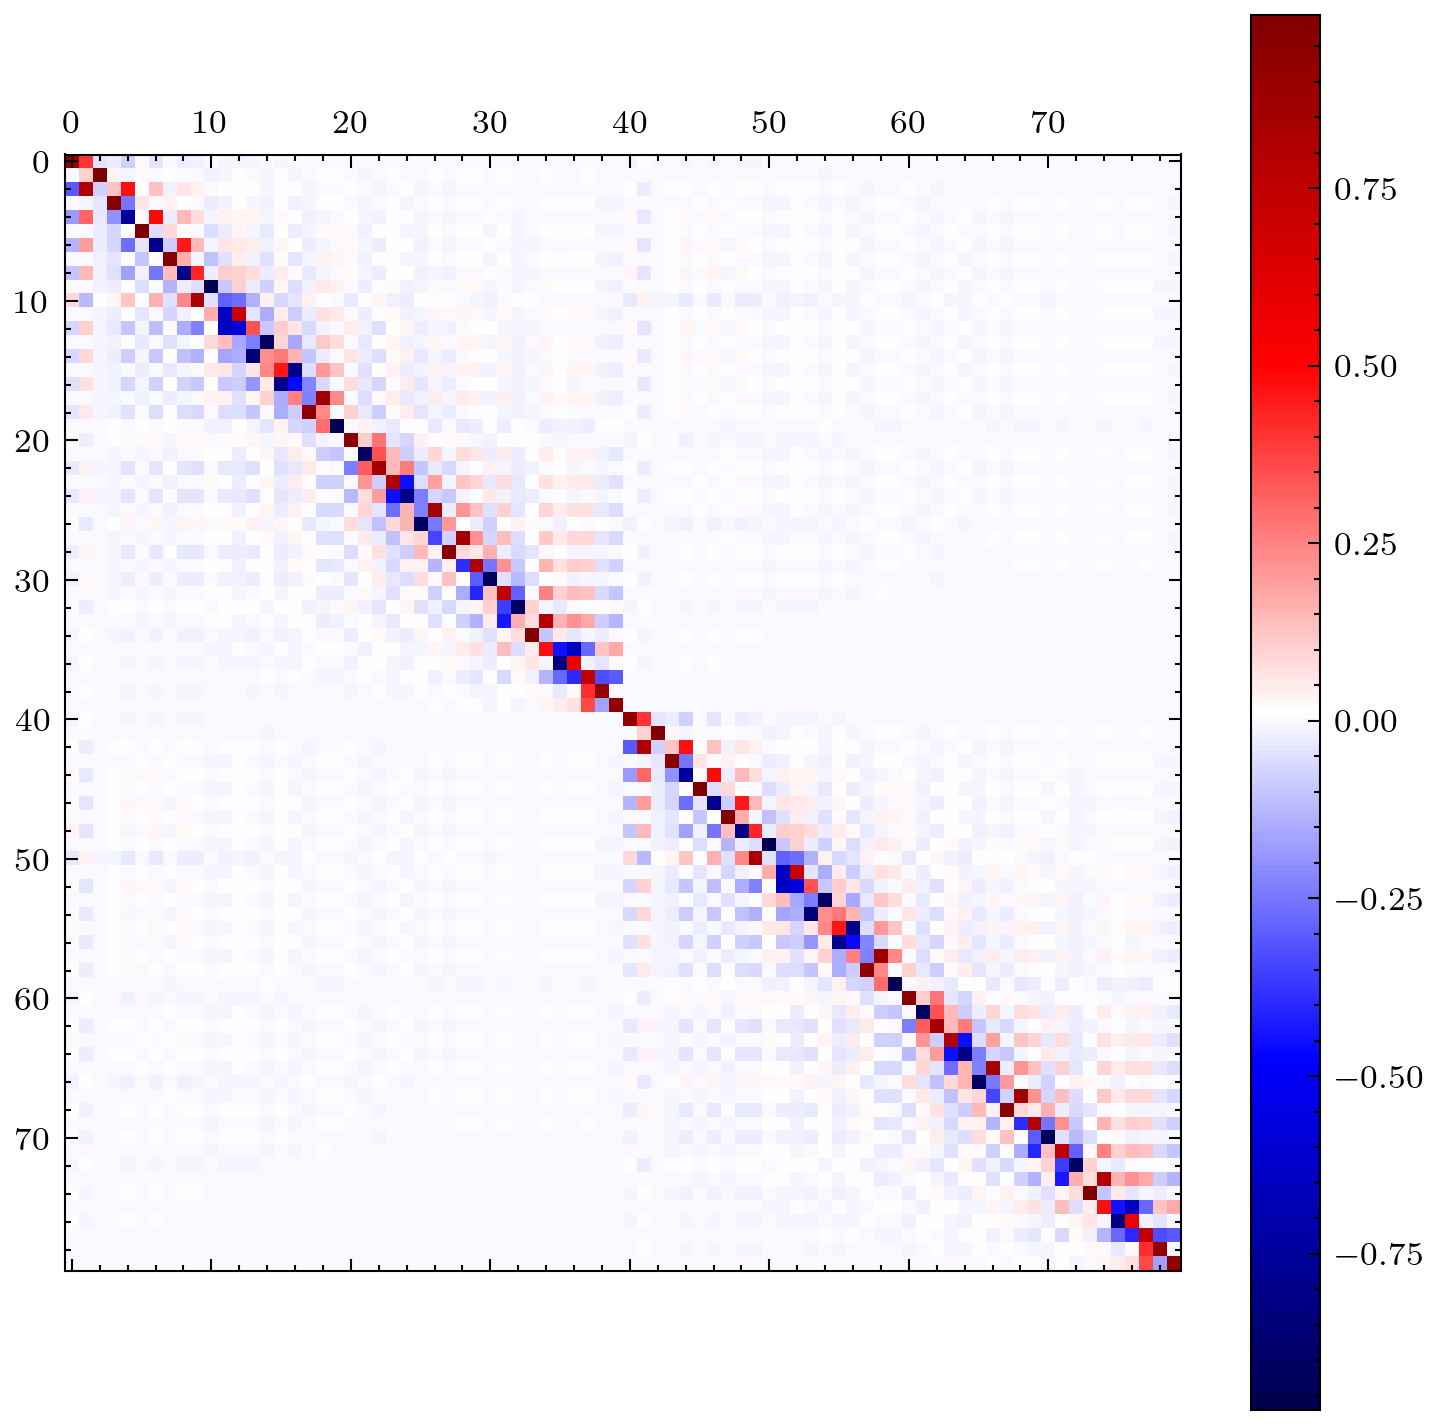

In [11]:
im = plt.matshow(conversion_matrix, cmap = 'seismic')
plt.colorbar(im)

In [6]:
photonic_chain.matter_hamiltonians(n_excitations = 1, layers = 0)
# photonic_chain.build_squeezed_vacuum(truncation = 4)

# print(len(photonic_chain.vacuum))

In [7]:
data = photonic_chain.vacuum.copy()
labels = [str(tuple(int(i) for i in k)) for k in data.keys()]
values = np.abs(np.array(list(data.values())))
excitations = [sum(k) for k in data.keys()]
x = np.arange(len(labels))

cmap = plt.cm.get_cmap('viridis', max(excitations) + 1)
colors_bar = [cmap(e) for e in excitations]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, values, color=colors_bar, width=0.6)
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=5)
ax.set_ylabel(r'$|c_{\mathbf{n}}|$')
ax.set_xlabel(r'Fock state $|\mathbf{n}\rangle$')
ax.set_title(r'Vacuum state coefficients')

handles = [plt.Rectangle((0,0),1,1, color=cmap(e)) for e in range(max(excitations)+1)]
ax.legend(handles, [rf'$n={e}$' for e in range(max(excitations)+1)],
          title='excitation', fontsize=7, title_fontsize=7)

plt.tight_layout()
plt.show()

AttributeError: 'PHOTONICChain' object has no attribute 'vacuum'

In [ ]:
photonic_chain.build_squeezed_vacuum(truncation = 5, threshold= 0.9999)
print(len(photonic_chain.vacuum))

10


/tmp/ipykernel_30109/1600148142.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', max(excitations) + 1)


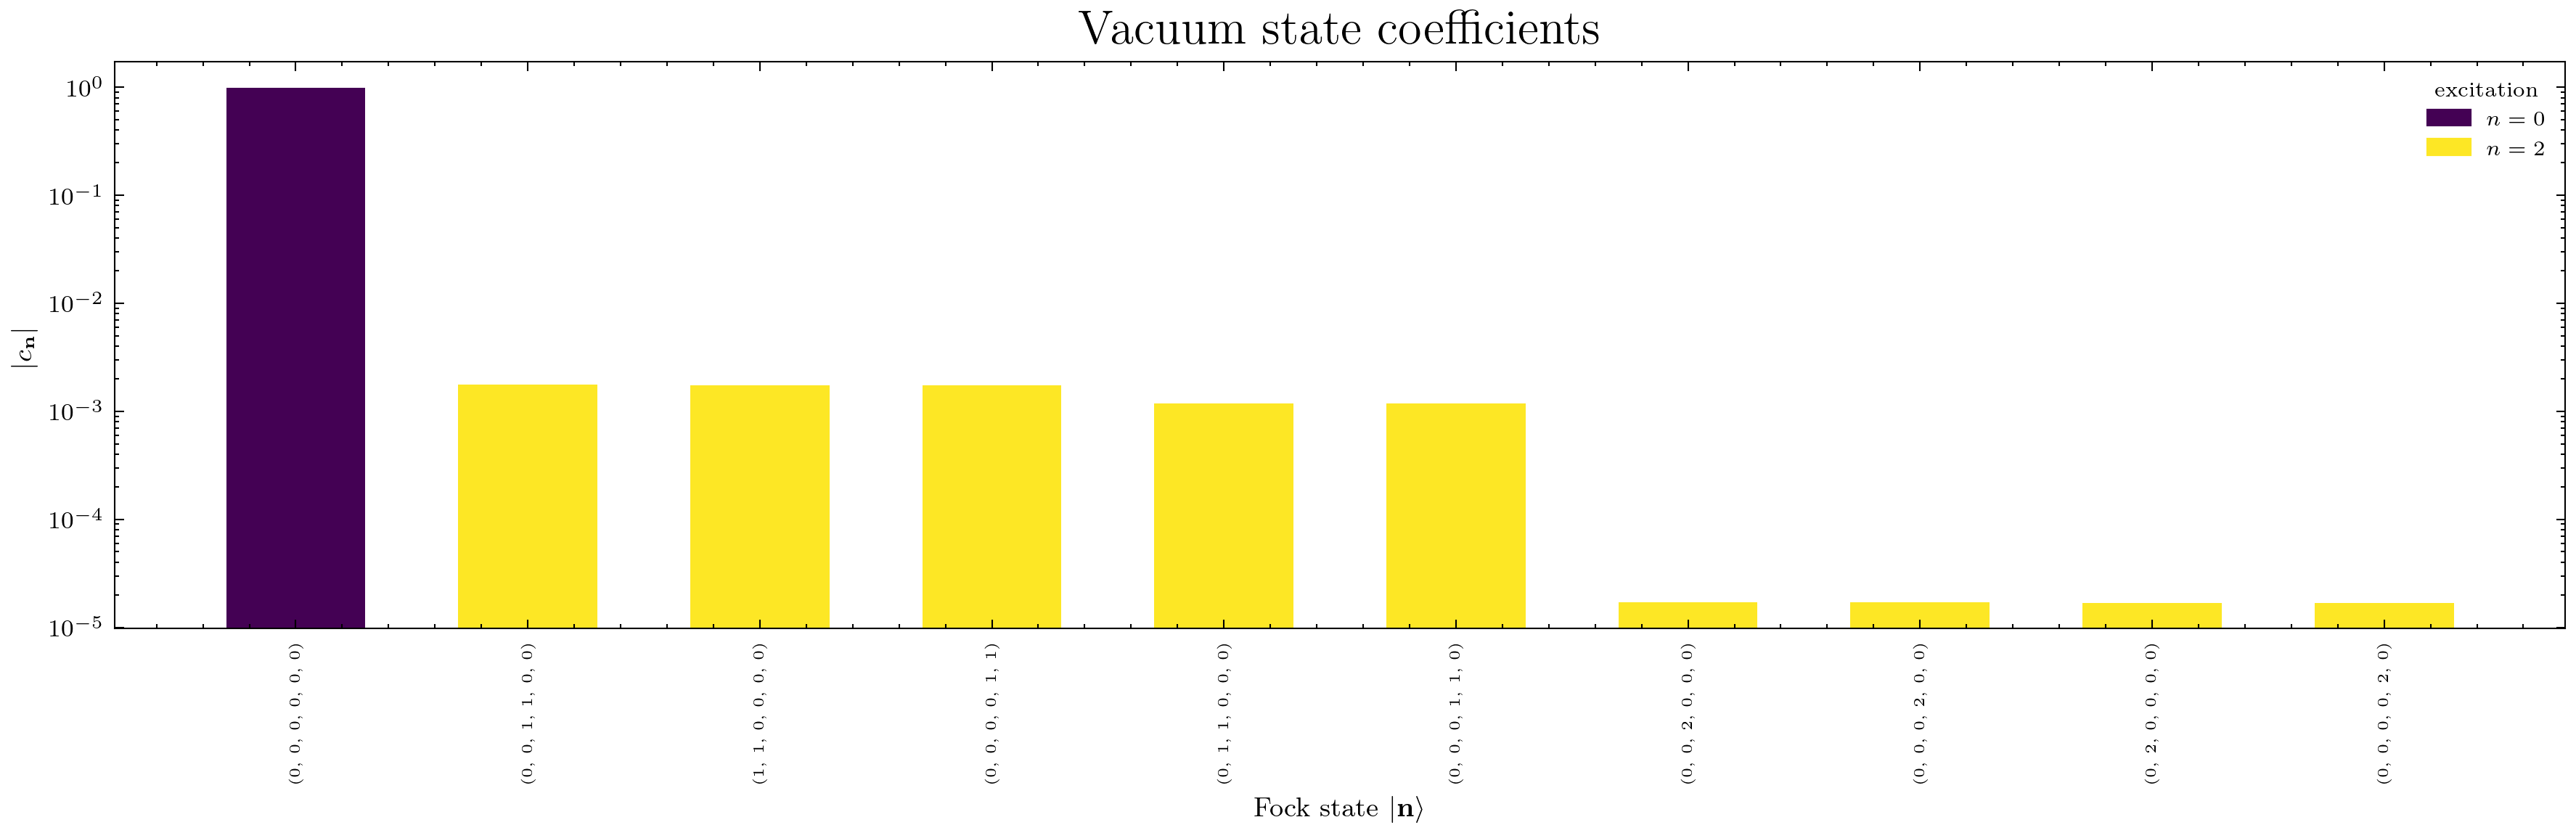

In [ ]:
data = photonic_chain.vacuum.copy()
labels = [str(tuple(int(i) for i in k)) for k in data.keys()]
values = np.abs(np.array(list(data.values())))**2
excitations = [sum(k) for k in data.keys()]
x = np.arange(len(labels))

cmap = plt.cm.get_cmap('viridis', max(excitations) + 1)
colors_bar = [cmap(e) for e in excitations]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, values, color=colors_bar, width=0.6)
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=5)
# ax.set_xticks([])
# ax.set_xticklabels([])
ax.set_ylabel(r'$|c_{\mathbf{n}}|$')
ax.set_xlabel(r'Fock state $|\mathbf{n}\rangle$')
ax.set_title(r'Vacuum state coefficients')

max_exc = max(excitations)
handles = [plt.Rectangle((0,0),1,1, color=cmap(e)) for e in range(0, max_exc+1, 2)]
ax.legend(handles, [rf'$n={e}$' for e in range(0, max_exc+1, 2)],
          title='excitation', fontsize=7, title_fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# --- test: decompose an arbitrary old-basis Fock state onto the new vacuum ---
# pick a test state |m> in the old basis
test_state = tuple([0] * (2 * photonic_chain.N))   # |0,0,...,0> -> should give overlap ~1
# test_state = tuple([1,0,0,0])                     # single excitation -> should be small

# overlap <0_new | test_state_old> = c_{test_state} if it exists, else 0
overlap = photonic_chain.vacuum.get(test_state, 0.0)
print(f"Overlap <0_new | test_state> = {overlap:.6f}")

# more general: decompose a superposition psi = sum_m alpha_m |m>
# defined as a dict {fock_tuple: amplitude}
psi = {
    tuple([0]*2*photonic_chain.N): 1/np.sqrt(2),
    tuple([1,0]*(photonic_chain.N)): 1/np.sqrt(2),
}

overlap_psi = sum(
    np.conj(photonic_chain.vacuum.get(m, 0.0)) * alpha
    for m, alpha in psi.items()
)
print(f"Overlap <0_new | psi> = {overlap_psi:.6f}")

# --- sanity checks ---
# 1. norm of vacuum should be 1
norm_vac = np.sqrt(sum(abs(v)**2 for v in photonic_chain.vacuum.values()))
print(f"Vacuum norm = {norm_vac:.10f}")

# 2. number of states kept
print(f"States in vacuum: {photonic_chain.vacuum_n_states}")

# 3. weight of vacuum |0,0,...,0> component (should dominate for small squeezing)
vac_weight = abs(photonic_chain.vacuum.get(tuple([0]*2*photonic_chain.N), 0.0))**2
print(f"Weight of |0> component = {vac_weight:.6f}")

AttributeError: 'PHOTONICChain' object has no attribute 'vacuum'

Input old-basis state: [0, 2, 0, 0, 0, 0, 0, 0]

New-basis decomposition (37 terms):
  [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]  ->  0.283911
  [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]  ->  0.282481
  [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]  ->  0.242702
  [np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]  ->  -0.241692
  [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]  ->  0.241692
  [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0)]  ->  0.233659
  [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]  ->  -0.207657
  [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)

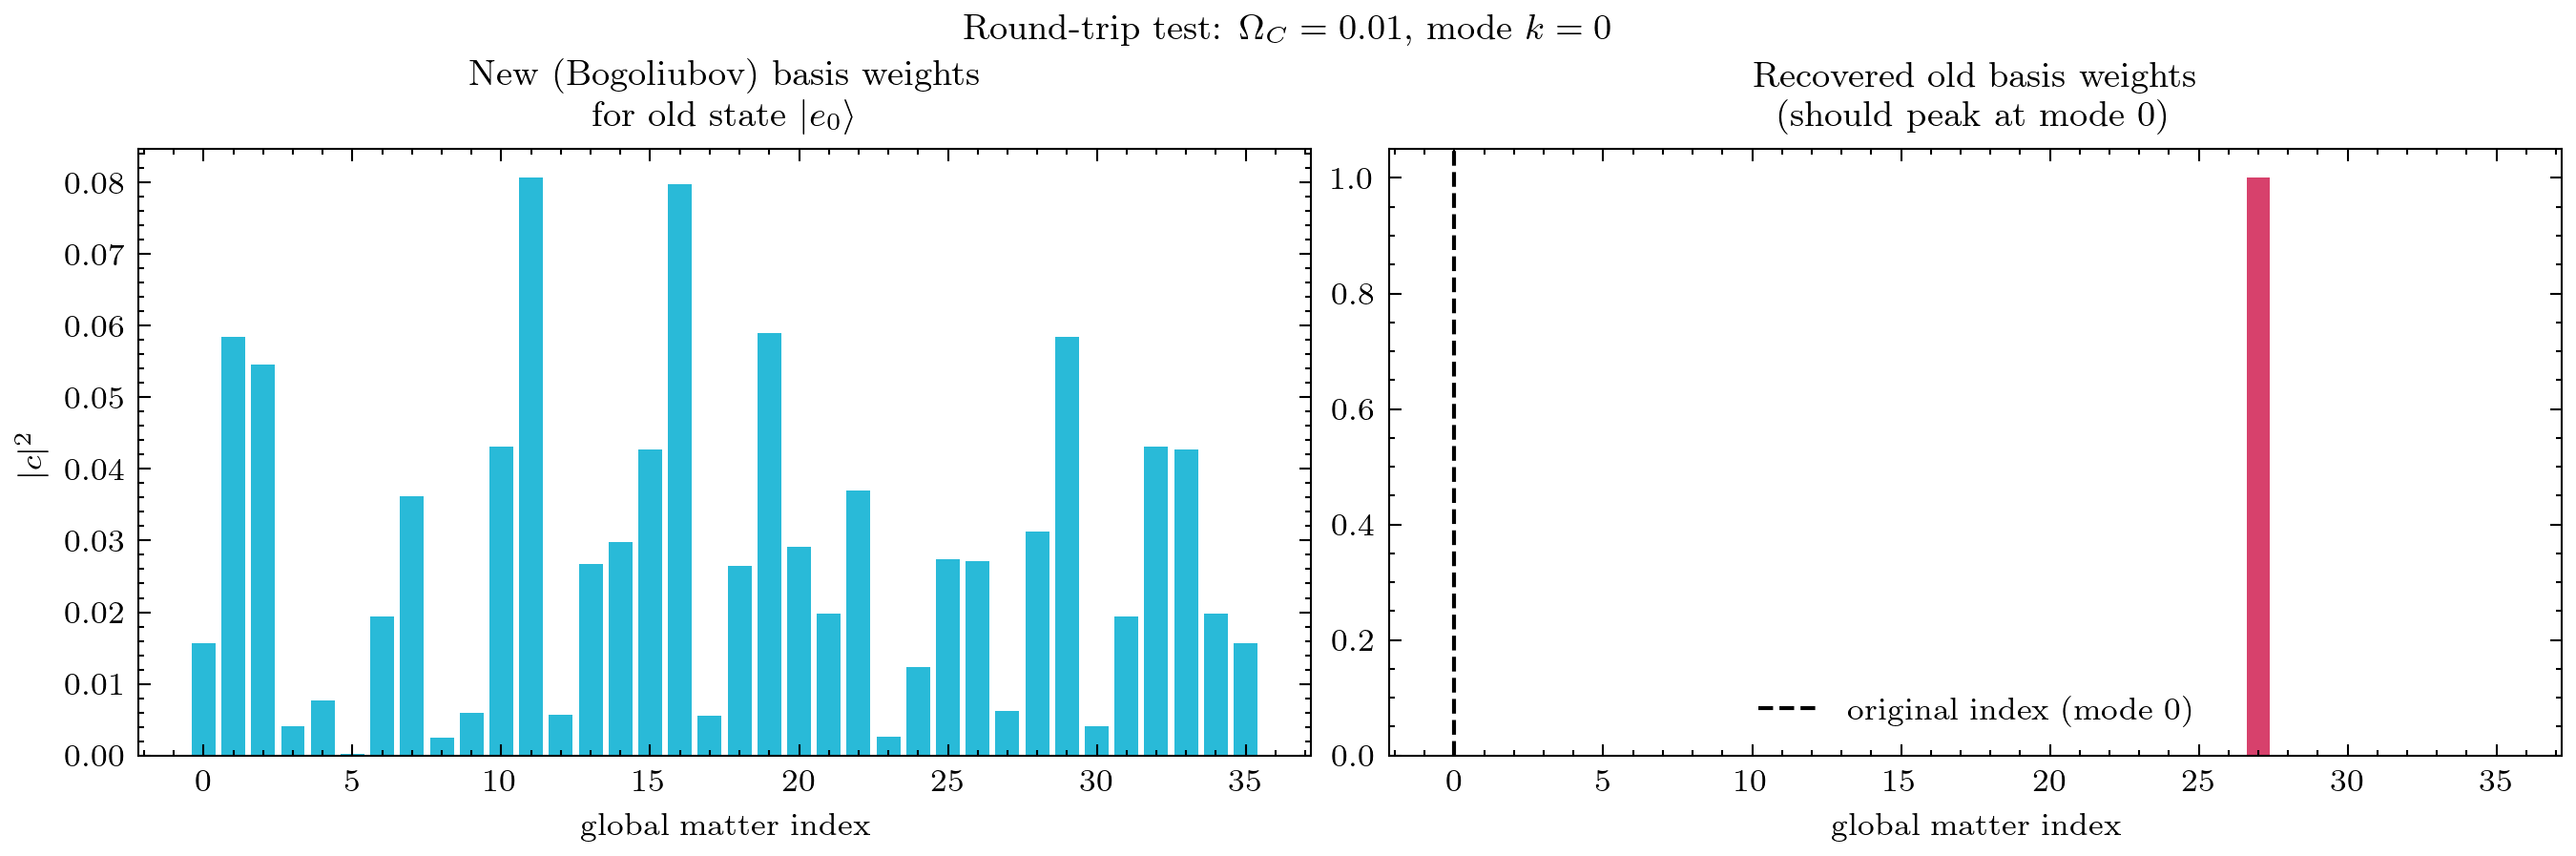

In [6]:
# ================================================================== #
# TEST: old -> new -> old round-trip for a known Fock state
# ================================================================== #

N            = 4
gamma        = 0.01
fock_photon  = 2
Omega_J      = 1.0
Chi_J        = 0.0
Omega_C      = 0.01
Chi_C        = 0.0
base_excitations = 2
fock_layers      = 0

aux     = 0.5 * Omega_C
omega_r = 1.02 * np.sqrt(1 + aux) - np.sqrt(1 - aux)

chain = model(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
              Omega_J, Chi_J, PBC=True)
chain.matter_hamiltonians(n_excitations=base_excitations, layers=fock_layers)
chain.build_full_hamiltonian()

n_modes = 2 * N
d_ph    = chain.fock_photon
d_mat   = chain.fock_dim

# --- pick a test state in the OLD basis ---
k1 = 1
k2 = 0
old_state = np.zeros(n_modes, dtype=int)
old_state[k1] = 2
old_state[k2] = 0
print(f"Input old-basis state: {old_state.tolist()}")

# ------------------------------------------------------------------ #
# STEP 1: old -> new (Bogoliubov) basis
# ------------------------------------------------------------------ #
chain.build_unsqueezed_vacuum(truncation=4, threshold=0.99)
new_repr = chain.old_to_new_fock(old_state)   # dict {tuple(new_state) -> coeff}

print(f"\nNew-basis decomposition ({len(new_repr)} terms):")
for state, coeff in sorted(new_repr.items(), key=lambda x: -abs(x[1])):
    print(f"  {list(state)}  ->  {coeff:.6f}")

# ------------------------------------------------------------------ #
# STEP 2: pack new_repr into a flat matter vector.
#
# The KEY fix: fock_state_index was built by matter_hamiltonians from
# compositions() in the OLD basis ordering.  New-basis tuples happen to
# be drawn from the same integer vectors but their positional mapping
# inside fock_state_index is completely independent of the physics.
#
# We therefore build our OWN ordered list for the new basis directly
# from the keys of new_repr, and keep that list around so that
# decompose_to_old_fock can read the vector back with the same ordering.
# ------------------------------------------------------------------ #
new_basis_states = list(new_repr.keys())                        # defines position i -> tuple
new_basis_index  = {s: i for i, s in enumerate(new_basis_states)}  # tuple -> position i

d_new = len(new_basis_states)
matter_vec_new = np.zeros(d_new, dtype=complex)
for new_state_tuple, coeff in new_repr.items():
    matter_vec_new[new_basis_index[new_state_tuple]] = coeff

norm_new = np.linalg.norm(matter_vec_new)
print(f"\nNorm of new-basis vector: {norm_new:.8f}  (should be 1.0)")

# ------------------------------------------------------------------ #
# STEP 3: new -> old via new_to_old_fock, using our own index.
#
# We bypass decompose_to_old_fock (which assumes fock_state_index
# ordering) and instead loop directly over our new_basis_states list.
# ------------------------------------------------------------------ #
chain.build_squeezed_vacuum(truncation=3, threshold=0.99)

old_matter = {}
for pos, new_state_tuple in enumerate(new_basis_states):
    coeff = matter_vec_new[pos]
    if abs(coeff) < 1e-15:
        continue
    old_part = chain.new_to_old_fock(np.array(new_state_tuple, dtype=int))
    # new_to_old_fock returns a normalized dict; weight by coeff
    for old_state_tuple, old_coeff in old_part.items():
        old_matter[old_state_tuple] = old_matter.get(old_state_tuple, 0.0) + coeff * old_coeff

print(f"\nRecovered old-basis decomposition ({len(old_matter)} terms):")
for state, coeff in sorted(old_matter.items(), key=lambda x: -abs(x[1])):
    print(f"  {list(state)}  ->  {coeff:.6f}  (|c|={abs(coeff):.6f})")

# ------------------------------------------------------------------ #
# STEP 4: round-trip check
# ------------------------------------------------------------------ #
original_key    = tuple(old_state.tolist())
recovered_coeff = old_matter.get(original_key, 0.0)
print(f"\nRound-trip check:")
print(f"  Original state {old_state.tolist()} has recovered |c| = {abs(recovered_coeff):.8f}")
print(f"  (should be ~1.0 for small Omega_C where Bogoliubov ~ identity)")

# ------------------------------------------------------------------ #
# STEP 5: plot
# ------------------------------------------------------------------ #
# Build weight arrays over the compositions-ordered index (for plotting
# both bases on a common axis of the same length d_mat).
# For the new-basis weights we use new_basis_index directly.
# For the old-basis weights we use fock_state_index as usual.

new_weights = np.zeros(d_mat)
for new_state_tuple, coeff in new_repr.items():
    exc = sum(new_state_tuple)
    if exc in chain.fock_state_index and new_state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][new_state_tuple]
        new_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

old_weights = np.zeros(d_mat)
for state_tuple, coeff in old_matter.items():
    exc = sum(state_tuple)
    if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][state_tuple]
        old_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

k = 0
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].bar(np.arange(d_mat), new_weights, color='#03AED2', alpha=0.85)
axes[0].set_title(f'New (Bogoliubov) basis weights\nfor old state $|e_{{{k}}}\\rangle$', fontsize=9)
axes[0].set_xlabel('global matter index', fontsize=8)
axes[0].set_ylabel(r'$|c|^2$', fontsize=8)

axes[1].bar(np.arange(d_mat), old_weights, color='#D12052', alpha=0.85)
axes[1].axvline(x=chain.fock_offsets[base_excitations] + k,
                color='black', linestyle='--', linewidth=1,
                label=f'original index (mode {k})')
axes[1].set_title(f'Recovered old basis weights\n(should peak at mode {k})', fontsize=9)
axes[1].set_xlabel('global matter index', fontsize=8)
axes[1].legend(fontsize=8)

fig.suptitle(rf'Round-trip test: $\Omega_C={Omega_C}$, mode $k={k}$', fontsize=9)
fig.tight_layout(pad=0.4, w_pad=0.6)
plt.show()

In [8]:
# ------------------------------------------------------------------ #
# CORRECTED TEST: old -> new -> old round-trip
# ------------------------------------------------------------------ #
# new_repr already IS the new-basis decomposition, keyed by correct
# new-basis tuples with correct coefficients. No need to pack into a
# flat vector and unpack — that round-trip through fock_state_index
# is exactly where the label scrambling happens.
# ------------------------------------------------------------------ #

chain.build_squeezed_vacuum(truncation=3, threshold=0.99)

old_matter = {}
for new_state_tuple, coeff in new_repr.items():
    old_part = chain.new_to_old_fock(np.array(new_state_tuple, dtype=int))
    for old_state_tuple, old_coeff in old_part.items():
        old_matter[old_state_tuple] = old_matter.get(old_state_tuple, 0.0) + coeff * old_coeff

# round-trip check
original_key    = tuple(old_state.tolist())
recovered_coeff = old_matter.get(original_key, 0.0)
print(f"\nRound-trip check:")
print(f"  |c| = {abs(recovered_coeff):.8f}  (should be ~1.0)")

# plot
new_weights = np.zeros(d_mat)
for new_state_tuple, coeff in new_repr.items():
    exc = sum(new_state_tuple)
    if exc in chain.fock_state_index and new_state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][new_state_tuple]
        new_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

old_weights = np.zeros(d_mat)
for state_tuple, coeff in old_matter.items():
    exc = sum(state_tuple)
    if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][state_tuple]
        old_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2


Round-trip check:
  |c| = 0.99999988  (should be ~1.0)


Input old-basis state: [0, 1, 0, 0, 0, 0, 0, 1]

Round-trip check:
  |c| = 0.99999985  (should be ~1.0)


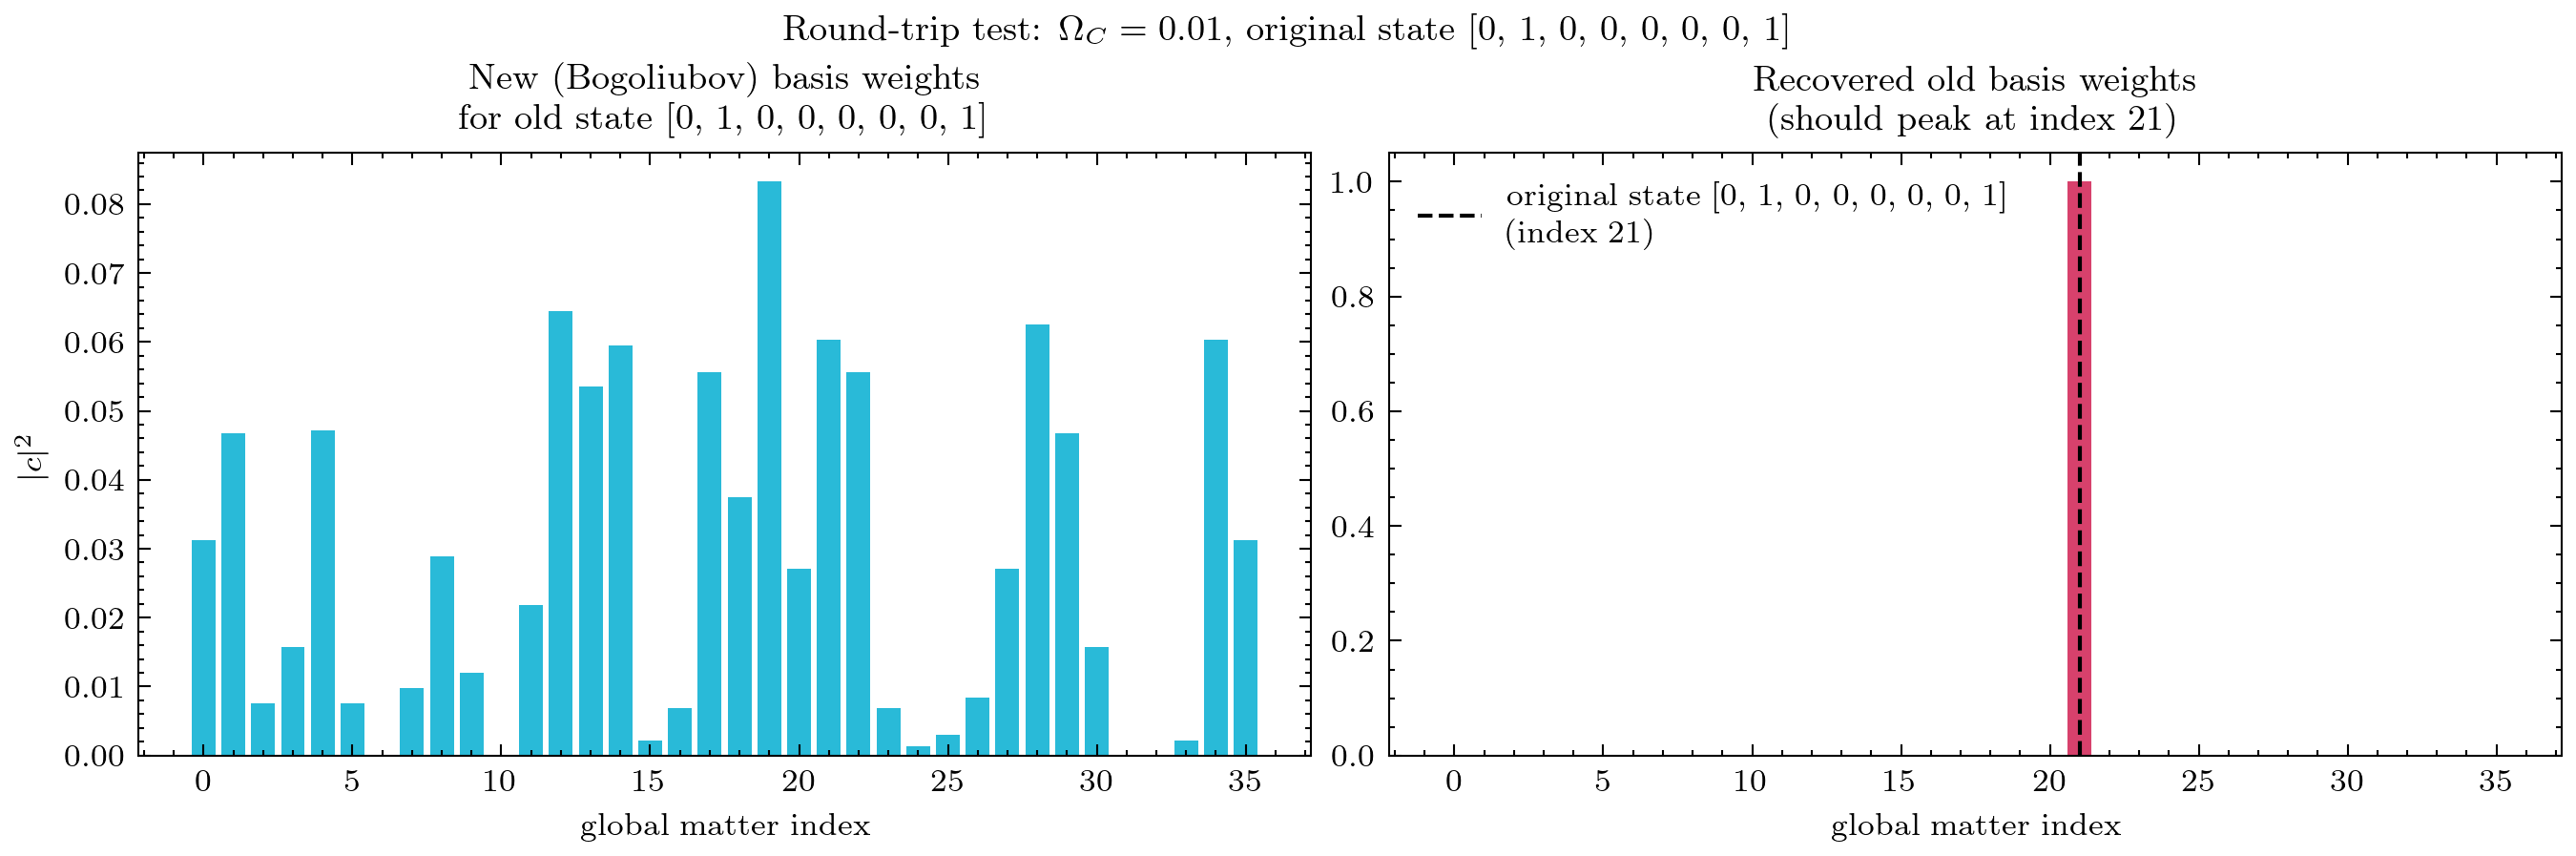

In [13]:
# ------------------------------------------------------------------ #
# PLOT — with correct reference line position
# ------------------------------------------------------------------ #

# ================================================================== #
# TEST: old -> new -> old round-trip for a known Fock state
# ================================================================== #

N            = 4
gamma        = 0.01
fock_photon  = 2
Omega_J      = 1.0
Chi_J        = 0.0
Omega_C      = 0.01
Chi_C        = 0.0
base_excitations = 2
fock_layers      = 0

aux     = 0.5 * Omega_C
omega_r = 1.02 * np.sqrt(1 + aux) - np.sqrt(1 - aux)

chain = model(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
              Omega_J, Chi_J, PBC=True)
chain.matter_hamiltonians(n_excitations=base_excitations, layers=fock_layers)
chain.build_full_hamiltonian()

n_modes = 2 * N
d_ph    = chain.fock_photon
d_mat   = chain.fock_dim

# --- pick a test state in the OLD basis ---
k1 = 1
k2 = 7
old_state = np.zeros(n_modes, dtype=int)
old_state[k1] = 1
old_state[k2] = 1
print(f"Input old-basis state: {old_state.tolist()}")

# ------------------------------------------------------------------ #
# STEP 1: old -> new (Bogoliubov) basis
# ------------------------------------------------------------------ #
chain.build_unsqueezed_vacuum(truncation=4, threshold=0.99)
new_repr = chain.old_to_new_fock(old_state)   # dict {tuple(new_state) -> coeff}
# ------------------------------------------------------------------ #
# CORRECTED TEST: old -> new -> old round-trip
# ------------------------------------------------------------------ #
# new_repr already IS the new-basis decomposition, keyed by correct
# new-basis tuples with correct coefficients. No need to pack into a
# flat vector and unpack — that round-trip through fock_state_index
# is exactly where the label scrambling happens.
# ------------------------------------------------------------------ #

chain.build_squeezed_vacuum(truncation=3, threshold=0.99)

old_matter = {}
for new_state_tuple, coeff in new_repr.items():
    old_part = chain.new_to_old_fock(np.array(new_state_tuple, dtype=int))
    for old_state_tuple, old_coeff in old_part.items():
        old_matter[old_state_tuple] = old_matter.get(old_state_tuple, 0.0) + coeff * old_coeff

# round-trip check
original_key    = tuple(old_state.tolist())
recovered_coeff = old_matter.get(original_key, 0.0)
print(f"\nRound-trip check:")
print(f"  |c| = {abs(recovered_coeff):.8f}  (should be ~1.0)")

# plot
new_weights = np.zeros(d_mat)
for new_state_tuple, coeff in new_repr.items():
    exc = sum(new_state_tuple)
    if exc in chain.fock_state_index and new_state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][new_state_tuple]
        new_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

old_weights = np.zeros(d_mat)
for state_tuple, coeff in old_matter.items():
    exc = sum(state_tuple)
    if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][state_tuple]
        old_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

new_weights = np.zeros(d_mat)
for new_state_tuple, coeff in new_repr.items():
    exc = sum(new_state_tuple)
    if exc in chain.fock_state_index and new_state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][new_state_tuple]
        new_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

old_weights = np.zeros(d_mat)
for state_tuple, coeff in old_matter.items():
    exc = sum(state_tuple)
    if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][state_tuple]
        old_weights[chain.fock_offsets[exc] + s_idx] = abs(coeff)**2

# correct reference: look up where the original state actually sits
original_key   = tuple(old_state.tolist())
original_exc   = int(old_state.sum())
original_s_idx = chain.fock_state_index[original_exc][original_key]
original_plot_idx = chain.fock_offsets[original_exc] + original_s_idx

axes[0].bar(np.arange(d_mat), new_weights, color='#03AED2', alpha=0.85)
axes[0].set_title(f'New (Bogoliubov) basis weights\nfor old state {old_state.tolist()}', fontsize=9)
axes[0].set_xlabel('global matter index', fontsize=8)
axes[0].set_ylabel(r'$|c|^2$', fontsize=8)

axes[1].bar(np.arange(d_mat), old_weights, color='#D12052', alpha=0.85)
axes[1].axvline(x=original_plot_idx,
                color='black', linestyle='--', linewidth=1,
                label=f'original state {old_state.tolist()}\n(index {original_plot_idx})')
axes[1].set_title(f'Recovered old basis weights\n(should peak at index {original_plot_idx})', fontsize=9)
axes[1].set_xlabel('global matter index', fontsize=8)
axes[1].legend(fontsize=8)

fig.suptitle(rf'Round-trip test: $\Omega_C={Omega_C}$, original state {old_state.tolist()}', fontsize=9)
fig.tight_layout(pad=0.4, w_pad=0.6)
plt.show()

In [17]:
# ================================================================== #
# TEST: General Superposition Decomposition
# ================================================================== #

# 1. Define two distinct matter states (ensure they exist in the 2-excitation sector)
# Example: State A with excitations at sites 0,1; State B at sites 2,3
state_A = tuple([1, 1] + [0] * (n_modes - 2)) 
state_B = tuple([0, 0, 1, 1] + [0] * (n_modes - 4)) 

# Get global indices using your established fock_state_index
idx_A = chain.fock_offsets[2] + chain.fock_state_index[2][state_A]
idx_B = chain.fock_offsets[2] + chain.fock_state_index[2][state_B]

# 2. Build the superposition vector: |psi> = 1/sqrt(2) * (|alpha=0, A> + |alpha=1, B>)
full_vec = np.zeros(d_ph * d_mat, dtype=complex)
full_vec[0 * d_mat + idx_A] = 1.0 / np.sqrt(2)
full_vec[1 * d_mat + idx_B] = 1.0 / np.sqrt(2)

# 3. Run decomposition
decomp = chain.decompose_tensor_state(full_vec)

# 4. Assertions
print(f"Testing General Superposition Decomposition:")
passed = True

# Verification logic
try:
    # Check alpha=0
    val_A = decomp.get(0, {}).get(state_A, 0.0)
    if not np.isclose(val_A, 1.0 / np.sqrt(2)):
        print(f"  FAILED: Sector alpha=0, state {state_A} -> got {val_A}")
        passed = False

    # Check alpha=1
    val_B = decomp.get(1, {}).get(state_B, 0.0)
    if not np.isclose(val_B, 1.0 / np.sqrt(2)):
        print(f"  FAILED: Sector alpha=1, state {state_B} -> got {val_B}")
        passed = False

    if passed:
        print("  PASSED: Successfully decomposed superposition across sectors.")
except Exception as e:
    print(f"  FAILED: An error occurred during verification: {e}")

Testing General Superposition Decomposition:
  PASSED: Successfully decomposed superposition across sectors.


In [ ]:
# ================================================================== #
# TEST: quanta_distribution localization detection
# ================================================================== #

N_test = 20
# Initialize chain with parameters where edge states appear (e.g., chi=-0.99)
chain = model(N_test, Omega_C=0.1, Chi_C=-0.6, omega_r=1.0, 
                      gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
chain.matter_hamiltonians(n_excitations=1, layers=0)

# 1. Define a perfectly localized edge state at site 0
edge_state_vec = np.zeros(chain.fock_dim)
edge_idx = chain.fock_state_index[1][tuple([1 if i==0 else 0 for i in range(chain.fock_dim)])]
edge_state_vec[edge_idx] = 1.0

# 2. Define a delocalized (flat) state: sum of all single-excitation states
bulk_state_vec = np.ones(chain.fock_dim) / np.sqrt(chain.fock_dim)

# 3. Get distributions
dist_edge = chain.quanta_distribution(edge_state_vec) # returns {site: prob}
dist_bulk = chain.quanta_distribution(bulk_state_vec)

print("Localization Check:")
print(f"  Edge state distribution: {dist_edge}")
print(f"  Bulk state distribution: {dist_bulk}")

# 4. Validation
# Edge state should have nearly 100% at site 0
if dist_edge[0] > 0.95:
    print("  PASSED: Edge state correctly detected as localized at site 0.")
else:
    print(f"  FAILED: Edge state not localized enough (at site 0). Got {dist_edge[0]}")

# Bulk state check (checking mean probability)
if np.allclose(dist_bulk, 1.0/N_test, atol=0.05):
    print("  PASSED: Bulk state correctly detected as delocalized.")
else:
    print(f"  FAILED: Bulk state distribution appears anomalous. Got {dist_bulk}")

Localization Check:
  Edge state distribution: [1. 0. 0. 0. 0. 0. 0. 0.]
  Bulk state distribution: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
  PASSED: Edge state correctly detected as localized at site 0.
  FAILED: Bulk state distribution appears anomalous. Got [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


In [332]:
import scipy.sparse.linalg as sla
N_test = 20
# Initialize chain with parameters where edge states appear (e.g., chi=-0.99)
Chi_C_values = np.linspace(-0.99, 0.99, 200)
edge_idx = 1
quanta_distributions = []
for Chi_C in Chi_C_values:
    print(Chi_C)
    chain = model(N_test, Omega_C=0.01, Chi_C= Chi_C, omega_r= 10.0, 
                        gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation = 1, threshold= 0.99)
    # print(len(chain.vacuum))
    # energies, states = chain.get_low_lying_spectrum(k = 2 * N_test-1)
    for sigma_try in [1.0 + 1e-9, 1.0 - 1e-9, 1.0 + 1e-8, 1.0 - 1e-8]:
        try:
            energies, states = sla.eigsh(chain.H, k=2, sigma=sigma_try, which='LM')
            break
        except RuntimeError:
            continue
    edge_state_old = chain.decompose_to_old_fock(states.T[edge_idx])[0]
    # zero_photon_edge_state = chain.decompose_general_tensor_state(edge_state_old, fock_photon = 1)[0]
    quanta_distributions.append(chain.quanta_distribution(edge_state_old))
    

-0.99
-0.9800502512562814
-0.9701005025125629
-0.9601507537688442
-0.9502010050251256
-0.940251256281407
-0.9303015075376885
-0.9203517587939698
-0.9104020100502512
-0.9004522613065327
-0.8905025125628141
-0.8805527638190954
-0.8706030150753769
-0.8606532663316583
-0.8507035175879397
-0.840753768844221
-0.8308040201005025
-0.8208542713567839
-0.8109045226130653
-0.8009547738693468
-0.7910050251256281
-0.7810552763819095
-0.771105527638191
-0.7611557788944723
-0.7512060301507537
-0.7412562814070351
-0.7313065326633166
-0.721356783919598
-0.7114070351758794
-0.7014572864321608
-0.6915075376884422
-0.6815577889447235
-0.671608040201005
-0.6616582914572864
-0.6517085427135678
-0.6417587939698493
-0.6318090452261307
-0.6218592964824121
-0.6119095477386934
-0.6019597989949749
-0.5920100502512562
-0.5820603015075376
-0.5721105527638191
-0.5621608040201005
-0.5522110552763819
-0.5422613065326634
-0.5323115577889447
-0.5223618090452261
-0.5124120603015075
-0.5024623115577889
-0.4925125628140703

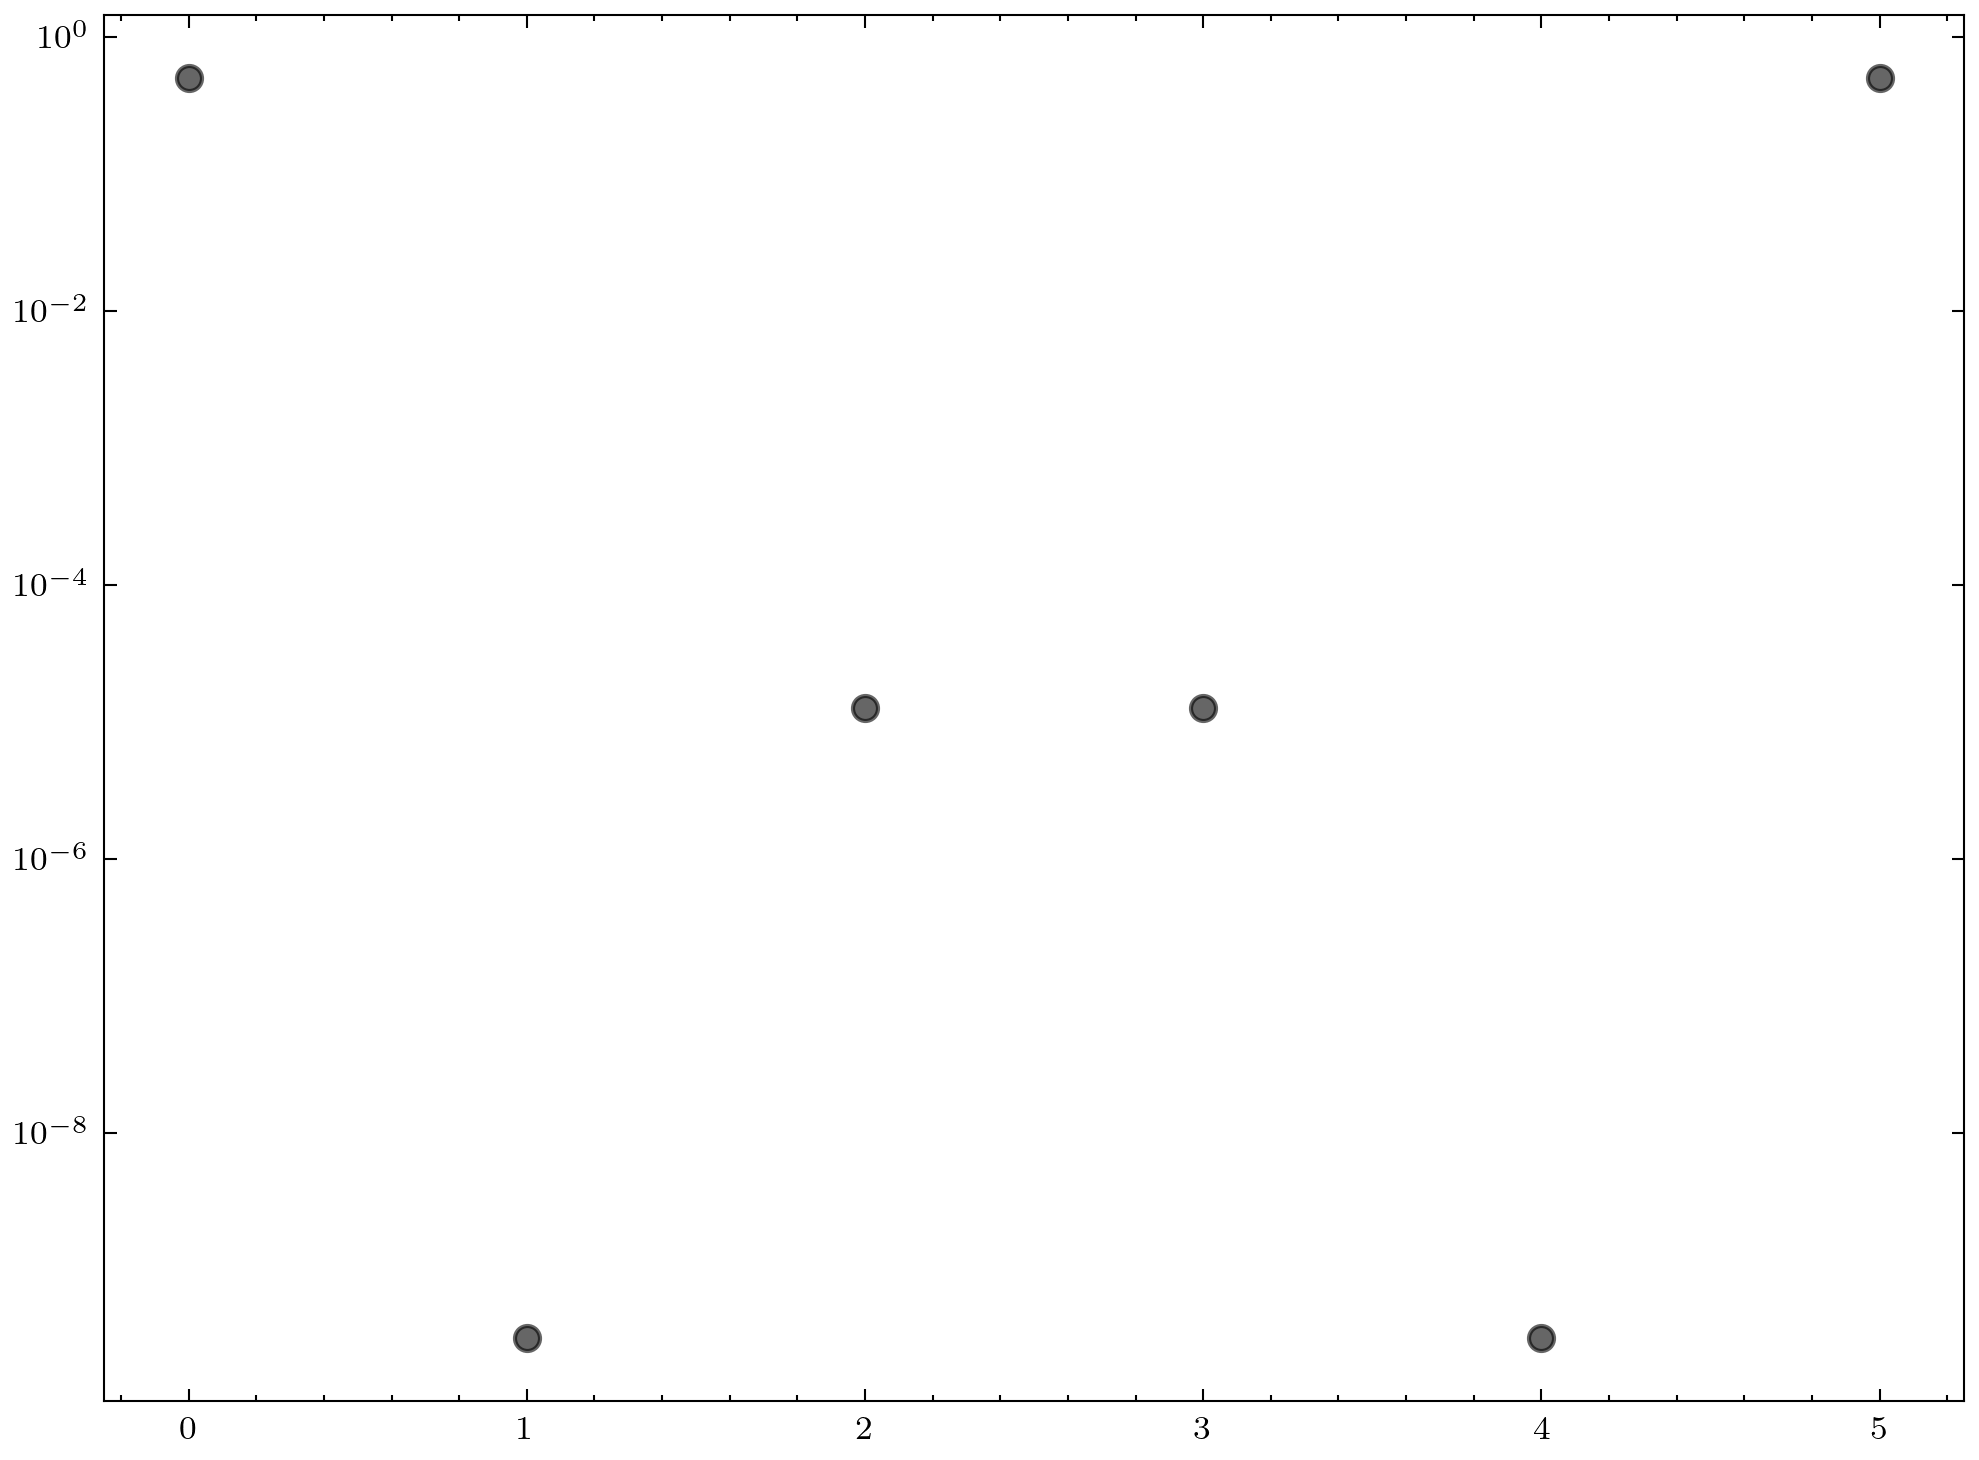

In [309]:
import scipy.sparse.linalg as sla
N_test = 3
chain = model(N_test, Omega_C=0.05, Chi_C= -0.99, omega_r= 10.0, 
                        gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
chain.matter_hamiltonians(n_excitations=1, layers=0)
chain.build_full_hamiltonian()
edge_idx = 0
chain.build_squeezed_vacuum(truncation = 0, threshold= 0.99)
# print(len(chain.vacuum))
# energies, states = chain.get_low_lying_spectrum(k = 2 * N_test-1)
energies, states = sla.eigsh(chain.H, k = 2, sigma = 1.0, which = 'LM')
edge_state_old = chain.decompose_to_old_fock(states.T[edge_idx])[0]
summation = 0.0
# Sort keys so the same basis state always gets the same index
sorted_keys = sorted(edge_state_old.keys()) 

plt.yscale('log')
for idx, key in enumerate(sorted_keys):
    # Using abs() squared to be safe with complex numbers
    val = np.abs(edge_state_old[key])**2
    plt.scatter(idx, val, color='black', alpha=0.6)

In [334]:
import scipy.sparse.linalg as sla

# Get k=4 states around sigma to have buffer around the degenerate pair
for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
    try:
        energies, states = sla.eigsh(chain.H, k=4, sigma=sigma_try, which='LM')
        break
    except RuntimeError:
        continue

idx_sort = np.argsort(energies)
energies = energies[idx_sort]
states   = states[:, idx_sort]

# --- identify the degenerate edge-state subspace ---
# edge states are the two closest to sigma=1.0
diffs = np.abs(energies - 1.0)
edge_mask = np.argsort(diffs)[:2]
E_edge    = energies[edge_mask]
V_edge    = states[:, edge_mask]   # shape (dim, 2): arbitrary basis in subspace

print(f"Edge state energies: {E_edge}")
print(f"Degeneracy splitting: {np.abs(E_edge[1]-E_edge[0]):.2e}")

# --- diagonalize a localization operator within the subspace ---
# Use the projector onto the LEFT half of the chain to disambiguate.
# In the old basis, sites 0..N-1 are the left half.
# We need this in the full tensor-product basis (photon x matter).
d_ph  = chain.fock_photon
d_mat = chain.fock_dim

# build a diagonal operator: +1 on left-half sites, -1 on right-half sites
# in the matter (Bogoliubov) basis using quanta number per site
left_right_diag = np.zeros(d_mat)
for exc, arr in chain.fock_states.items():
    offset = chain.fock_offsets[exc]
    for s_idx, state in enumerate(arr):
        # weight = (quanta on left half) - (quanta on right half)
        left  = sum(state[:chain.N])
        right = sum(state[chain.N:])
        left_right_diag[offset + s_idx] = left - right

# tensor with photon identity: shape (d_ph * d_mat,)
full_diag = np.tile(left_right_diag, d_ph)

# project onto the 2D edge subspace: O_eff = V^dag diag V  (2x2 matrix)
O_eff = V_edge.conj().T * full_diag @ V_edge   # (2,2)

# diagonalize O_eff -> gives the two localized combinations
evals_O, evecs_O = np.linalg.eigh(O_eff)
# columns of evecs_O are the coefficients mixing V_edge columns
V_localized = V_edge @ evecs_O   # shape (dim, 2)

# now V_localized[:,0] is localized on one end, [:,1] on the other
# evals_O[0] < 0 -> right-localized, evals_O[1] > 0 -> left-localized
print(f"Localization operator eigenvalues: {evals_O}")

Edge state energies: [1.00493809 1.00493892]
Degeneracy splitting: 8.31e-07
Localization operator eigenvalues: [-1. -1.]


In [335]:
# --- sublattice parity operator within the subspace ---
# In the SSH chain with 2N modes, even indices are sublattice A, odd are B
sublattice_diag = np.zeros(d_mat)
for exc, arr in chain.fock_states.items():
    offset = chain.fock_offsets[exc]
    for s_idx, state in enumerate(arr):
        # +1 on A sites (even), -1 on B sites (odd)
        weight = sum(n * (1 if i % 2 == 0 else -1)
                     for i, n in enumerate(state))
        sublattice_diag[offset + s_idx] = weight

full_diag_sub = np.tile(sublattice_diag, d_ph)
O_sub = (V_edge.conj().T * full_diag_sub) @ V_edge

evals_O, evecs_O = np.linalg.eigh(O_sub)
V_localized = V_edge @ evecs_O
print(f"Sublattice operator eigenvalues: {evals_O}")

Sublattice operator eigenvalues: [-1.  1.]


Chi_C = -0.9900
Chi_C = -0.9801
Chi_C = -0.9701
Chi_C = -0.9602
Chi_C = -0.9502
Chi_C = -0.9403
Chi_C = -0.9303
Chi_C = -0.9204
Chi_C = -0.9104
Chi_C = -0.9005
Chi_C = -0.8905
Chi_C = -0.8806
Chi_C = -0.8706
Chi_C = -0.8607
Chi_C = -0.8507
Chi_C = -0.8408
Chi_C = -0.8308
Chi_C = -0.8209
Chi_C = -0.8109
Chi_C = -0.8010
Chi_C = -0.7910
Chi_C = -0.7811
Chi_C = -0.7711
Chi_C = -0.7612
Chi_C = -0.7512
Chi_C = -0.7413
Chi_C = -0.7313
Chi_C = -0.7214
Chi_C = -0.7114
Chi_C = -0.7015
Chi_C = -0.6915
Chi_C = -0.6816
Chi_C = -0.6716
Chi_C = -0.6617
Chi_C = -0.6517
Chi_C = -0.6418
Chi_C = -0.6318
Chi_C = -0.6219
Chi_C = -0.6119
Chi_C = -0.6020
Chi_C = -0.5920
Chi_C = -0.5821
Chi_C = -0.5721
Chi_C = -0.5622
Chi_C = -0.5522
Chi_C = -0.5423
Chi_C = -0.5323
Chi_C = -0.5224
Chi_C = -0.5124
Chi_C = -0.5025
Chi_C = -0.4925
Chi_C = -0.4826
Chi_C = -0.4726
Chi_C = -0.4627
Chi_C = -0.4527
Chi_C = -0.4428
Chi_C = -0.4328
Chi_C = -0.4229
Chi_C = -0.4129
Chi_C = -0.4030
Chi_C = -0.3930
Chi_C = -0.3831
Chi_C = 

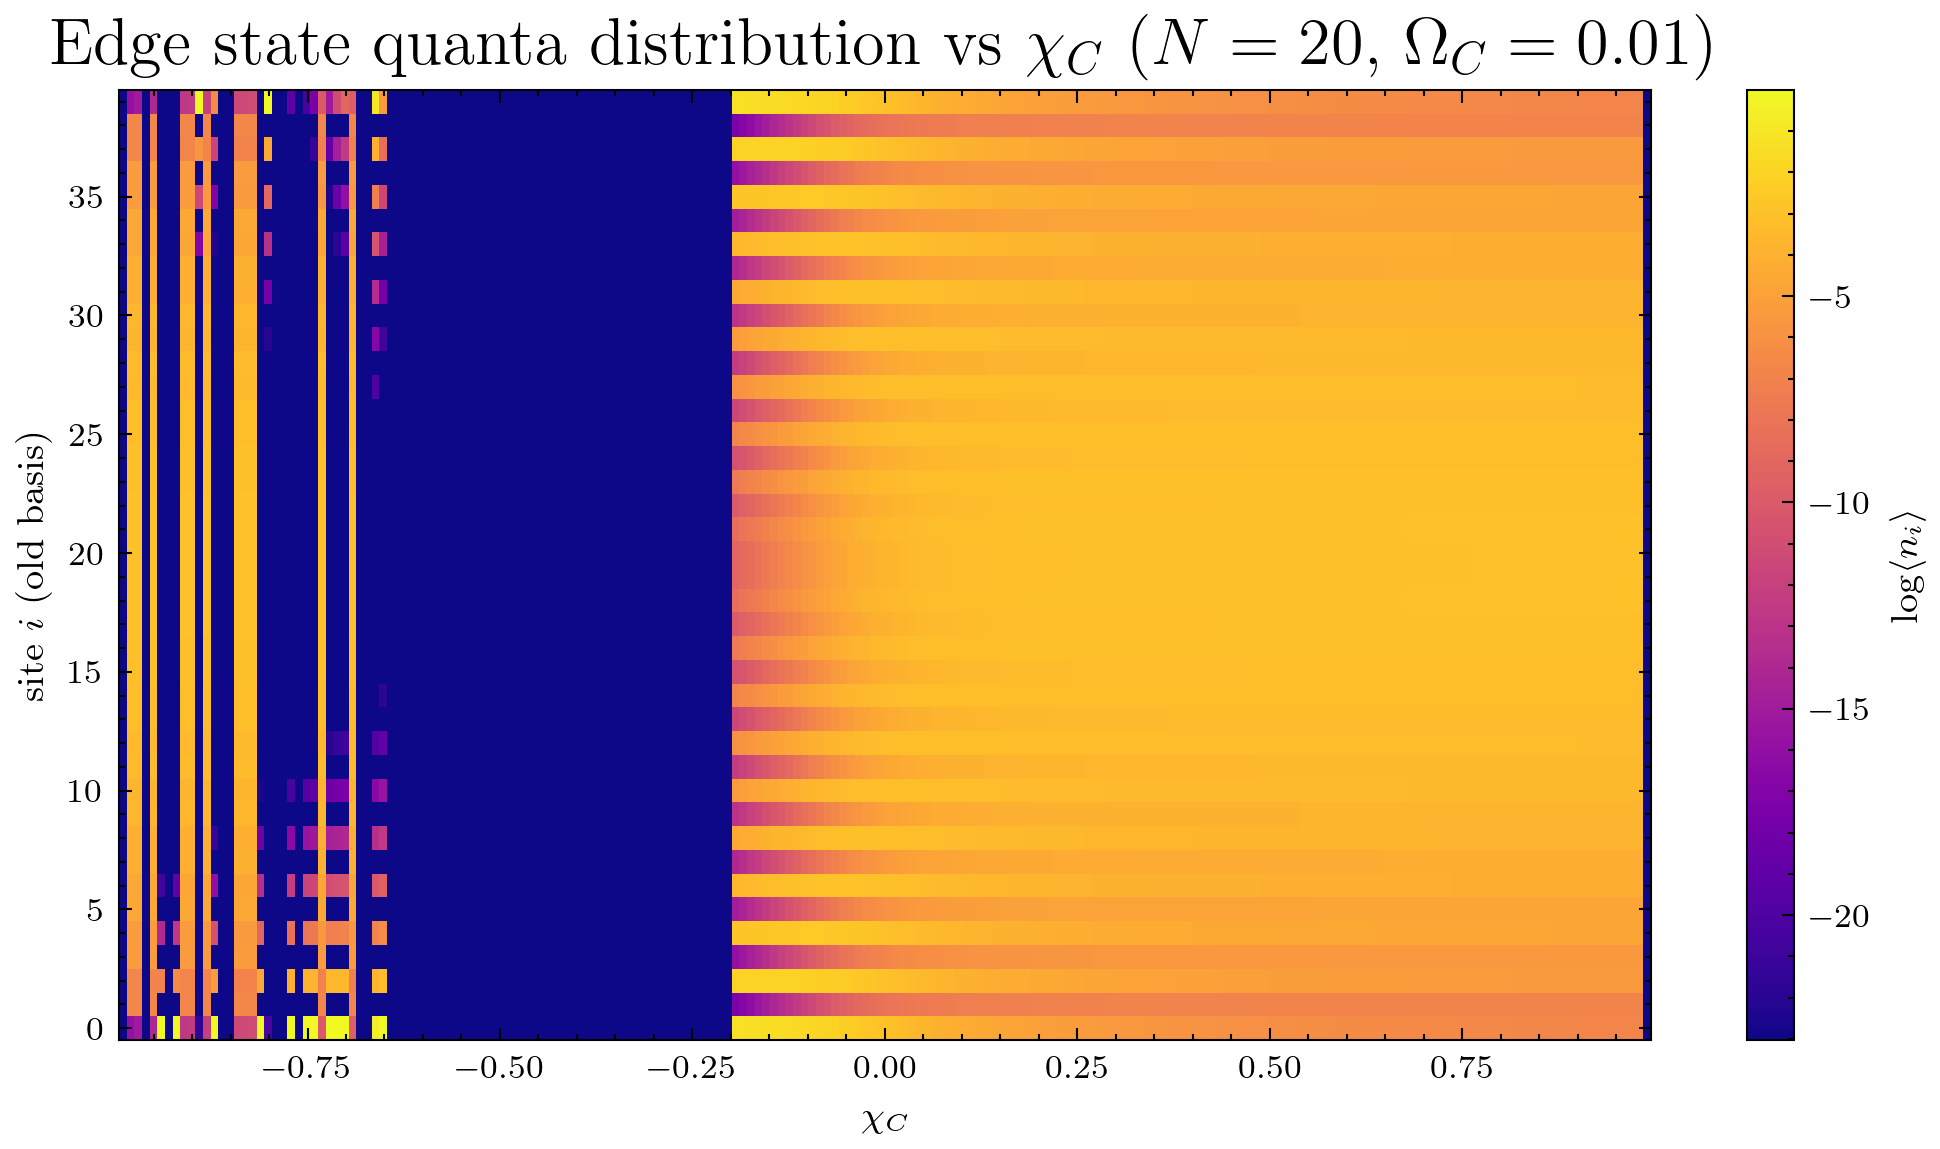

In [339]:
import scipy.sparse.linalg as sla

N_test       = 20
Chi_C_values = np.linspace(-0.99, 0.99, 200)
edge_choice  = 1   # 0: B-sublattice edge, 1: A-sublattice edge

quanta_distributions = []

for Chi_C in Chi_C_values:
    print(f"Chi_C = {Chi_C:.4f}")

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- two-sided eigsh to get states from both sides of sigma=1.0 ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4]:
        for delta in [0, 1e-3, -1e-3, 1e-2, -1e-2]:
            try:
                evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try + delta, which='LM')
                for i, e in enumerate(evals):
                    if not any(abs(e - e2) < 1e-6 for e2 in results):
                        results[e] = evecs[:, i]
                break
            except RuntimeError:
                continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])

    # --- pick one state from each side of 1.0 ---
    above_mask = all_energies > 1.0
    below_mask = all_energies < 1.0

    if not above_mask.any() or not below_mask.any():
        # near the transition — can't resolve edge pair, skip
        quanta_distributions.append(np.zeros(2 * N_test))
        continue

    e_above_idx = np.where(above_mask)[0][np.argmin(all_energies[above_mask] - 1.0)]
    e_below_idx = np.where(below_mask)[0][np.argmax(all_energies[below_mask] - 1.0)]
    V_edge      = all_states[:, [e_below_idx, e_above_idx]]

    # --- sublattice parity disambiguation ---
    sublattice_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            sublattice_diag[offset + s_idx] = sum(
                n * (1 if i % 2 == 0 else -1) for i, n in enumerate(state))

    full_diag_sub    = np.tile(sublattice_diag, d_ph)
    O_sub            = (V_edge.conj().T * full_diag_sub) @ V_edge
    evals_O, evecs_O = np.linalg.eigh(O_sub)

    # sanity check: eigenvalues should have opposite signs
    if evals_O[0] * evals_O[1] > 0:
        # disambiguation failed (near transition), skip
        quanta_distributions.append(np.zeros(2 * N_test))
        continue

    V_localized = V_edge @ evecs_O   # col 0: B-edge, col 1: A-edge
    evec        = V_localized[:, edge_choice]

    # --- partial trace -> dominant matter component ---
    rho_matter       = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho     = np.linalg.eigh(rho_matter)
    matter_vec_new   = evecs_rho[:, -1]

    # --- synthetic full vector in photon sector alpha=0 ---
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    # --- convert to old basis ---
    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx      = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)
    quanta_distributions.append(dist)

# ------------------------------------------------------------------ #
# Plot
# ------------------------------------------------------------------ #
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array),
                   cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state quanta distribution vs $\chi_C$  '
             rf'($N={N_test}$, $\Omega_C=0.01$)')
fig.tight_layout()
plt.show()

In [341]:
# ------------------------------------------------------------------ #
# DIAGNOSTIC: run a few representative Chi_C values and report
# ------------------------------------------------------------------ #
Chi_C_diag = [-0.99, -0.85, -0.70, -0.50, -0.30, -0.10, 0.10]

for Chi_C in Chi_C_diag:
    print(f"\n{'='*60}")
    print(f"Chi_C = {Chi_C:.3f}")

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- two-sided eigsh ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4]:
        for delta in [0, 1e-3, -1e-3, 1e-2, -1e-2]:
            try:
                evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try + delta, which='LM')
                for i, e in enumerate(evals):
                    if not any(abs(e - e2) < 1e-6 for e2 in results):
                        results[e] = evecs[:, i]
                break
            except RuntimeError as ex:
                print(f"  eigsh failed: sigma={sigma_try+delta:.6f}  err={ex}")
                continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])
    print(f"  Found {len(all_energies)} states")
    print(f"  Energies: {all_energies}")
    print(f"  Spread:   {all_energies - 1.0}")

    above_mask = all_energies > 1.0
    below_mask = all_energies < 1.0
    print(f"  Above 1.0: {above_mask.sum()}   Below 1.0: {below_mask.sum()}")

    if not above_mask.any() or not below_mask.any():
        print("  >>> SKIP: no states on one side of sigma")
        continue

    e_above_idx = np.where(above_mask)[0][np.argmin(all_energies[above_mask] - 1.0)]
    e_below_idx = np.where(below_mask)[0][np.argmax(all_energies[below_mask] - 1.0)]
    V_edge = all_states[:, [e_below_idx, e_above_idx]]
    print(f"  Edge pair: {all_energies[e_below_idx]:.8f}  {all_energies[e_above_idx]:.8f}")
    print(f"  Symmetric check: {all_energies[e_above_idx] + all_energies[e_below_idx] - 2.0:.2e}")

    # --- sublattice operator ---
    sublattice_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            sublattice_diag[offset + s_idx] = sum(
                n * (1 if i % 2 == 0 else -1) for i, n in enumerate(state))

    full_diag_sub    = np.tile(sublattice_diag, d_ph)
    O_sub            = (V_edge.conj().T * full_diag_sub) @ V_edge
    evals_O, evecs_O = np.linalg.eigh(O_sub)
    print(f"  Sublattice eigenvalues: {evals_O}")
    print(f"  Product (should be <0): {evals_O[0]*evals_O[1]:.4f}")

    if evals_O[0] * evals_O[1] > 0:
        print("  >>> SKIP: sublattice discrimination failed")
        continue

    V_localized = V_edge @ evecs_O
    evec        = V_localized[:, 1]

    # --- partial trace ---
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    evals_rho, evecs_rho = np.linalg.eigh(rho_matter)
    print(f"  rho_matter eigenvalues (top 3): {evals_rho[-3:]}")
    print(f"  Leading eigenvalue: {evals_rho[-1]:.6f}  (should be ~1 for product state)")
    matter_vec_new = evecs_rho[:, -1]

    # --- old basis conversion ---
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})
    print(f"  old_sector terms: {len(old_sector)}")

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    old_norm = np.linalg.norm(old_vec)
    print(f"  old_vec norm: {old_norm:.6f}  (should be ~1)")

    dist = chain.quanta_distribution(old_vec)
    print(f"  dist sum: {dist.sum():.6f}  (should be 1.0)")
    print(f"  dist max site: {np.argmax(dist)}  max value: {dist.max():.6f}")
    print(f"  dist (all sites): {np.round(dist, 4)}")


Chi_C = -0.990
  Found 7 states
  Energies: [0.99503287 0.99503493 0.99503645 1.         1.00493812 1.00494053
 1.00494258]
  Spread:   [-4.96713477e-03 -4.96506508e-03 -4.96354863e-03 -2.22044605e-16
  4.93811699e-03  4.94053471e-03  4.94258399e-03]
  Above 1.0: 3   Below 1.0: 4
  Edge pair: 1.00000000  1.00493812
  Symmetric check: 4.94e-03
  Sublattice eigenvalues: [-1. -1.]
  Product (should be <0): 1.0000
  >>> SKIP: sublattice discrimination failed

Chi_C = -0.850
  Found 9 states
  Energies: [0.99566275 0.99569612 0.99572075 0.99573584 1.         1.00424605
 1.00426102 1.00428543 1.00431851]
  Spread:   [-4.33724527e-03 -4.30387593e-03 -4.27925396e-03 -4.26415704e-03
 -2.22044605e-16  4.24605105e-03  4.26101981e-03  4.28543179e-03
  4.31851464e-03]
  Above 1.0: 4   Below 1.0: 5
  Edge pair: 1.00000000  1.00424605
  Symmetric check: 4.25e-03
  Sublattice eigenvalues: [-1.         0.9999998]
  Product (should be <0): -1.0000
  rho_matter eigenvalues (top 3): [2.46673253e-48 1.586

Chi_C = -0.9900
Chi_C = -0.9801
Chi_C = -0.9701
Chi_C = -0.9602
Chi_C = -0.9502
Chi_C = -0.9403
Chi_C = -0.9303
Chi_C = -0.9204
Chi_C = -0.9104
Chi_C = -0.9005
Chi_C = -0.8905
Chi_C = -0.8806
Chi_C = -0.8706
Chi_C = -0.8607
Chi_C = -0.8507
Chi_C = -0.8408
Chi_C = -0.8308
Chi_C = -0.8209
Chi_C = -0.8109
Chi_C = -0.8010
Chi_C = -0.7910
Chi_C = -0.7811
Chi_C = -0.7711
Chi_C = -0.7612
Chi_C = -0.7512
Chi_C = -0.7413
Chi_C = -0.7313
Chi_C = -0.7214
Chi_C = -0.7114
Chi_C = -0.7015
Chi_C = -0.6915
Chi_C = -0.6816
Chi_C = -0.6716
Chi_C = -0.6617
Chi_C = -0.6517
Chi_C = -0.6418
Chi_C = -0.6318
Chi_C = -0.6219
Chi_C = -0.6119
Chi_C = -0.6020
Chi_C = -0.5920
Chi_C = -0.5821
Chi_C = -0.5721
Chi_C = -0.5622
Chi_C = -0.5522
Chi_C = -0.5423
Chi_C = -0.5323
Chi_C = -0.5224
Chi_C = -0.5124
Chi_C = -0.5025
Chi_C = -0.4925
Chi_C = -0.4826
Chi_C = -0.4726
Chi_C = -0.4627
Chi_C = -0.4527
Chi_C = -0.4428
Chi_C = -0.4328
Chi_C = -0.4229
Chi_C = -0.4129
Chi_C = -0.4030
Chi_C = -0.3930
Chi_C = -0.3831
Chi_C = 

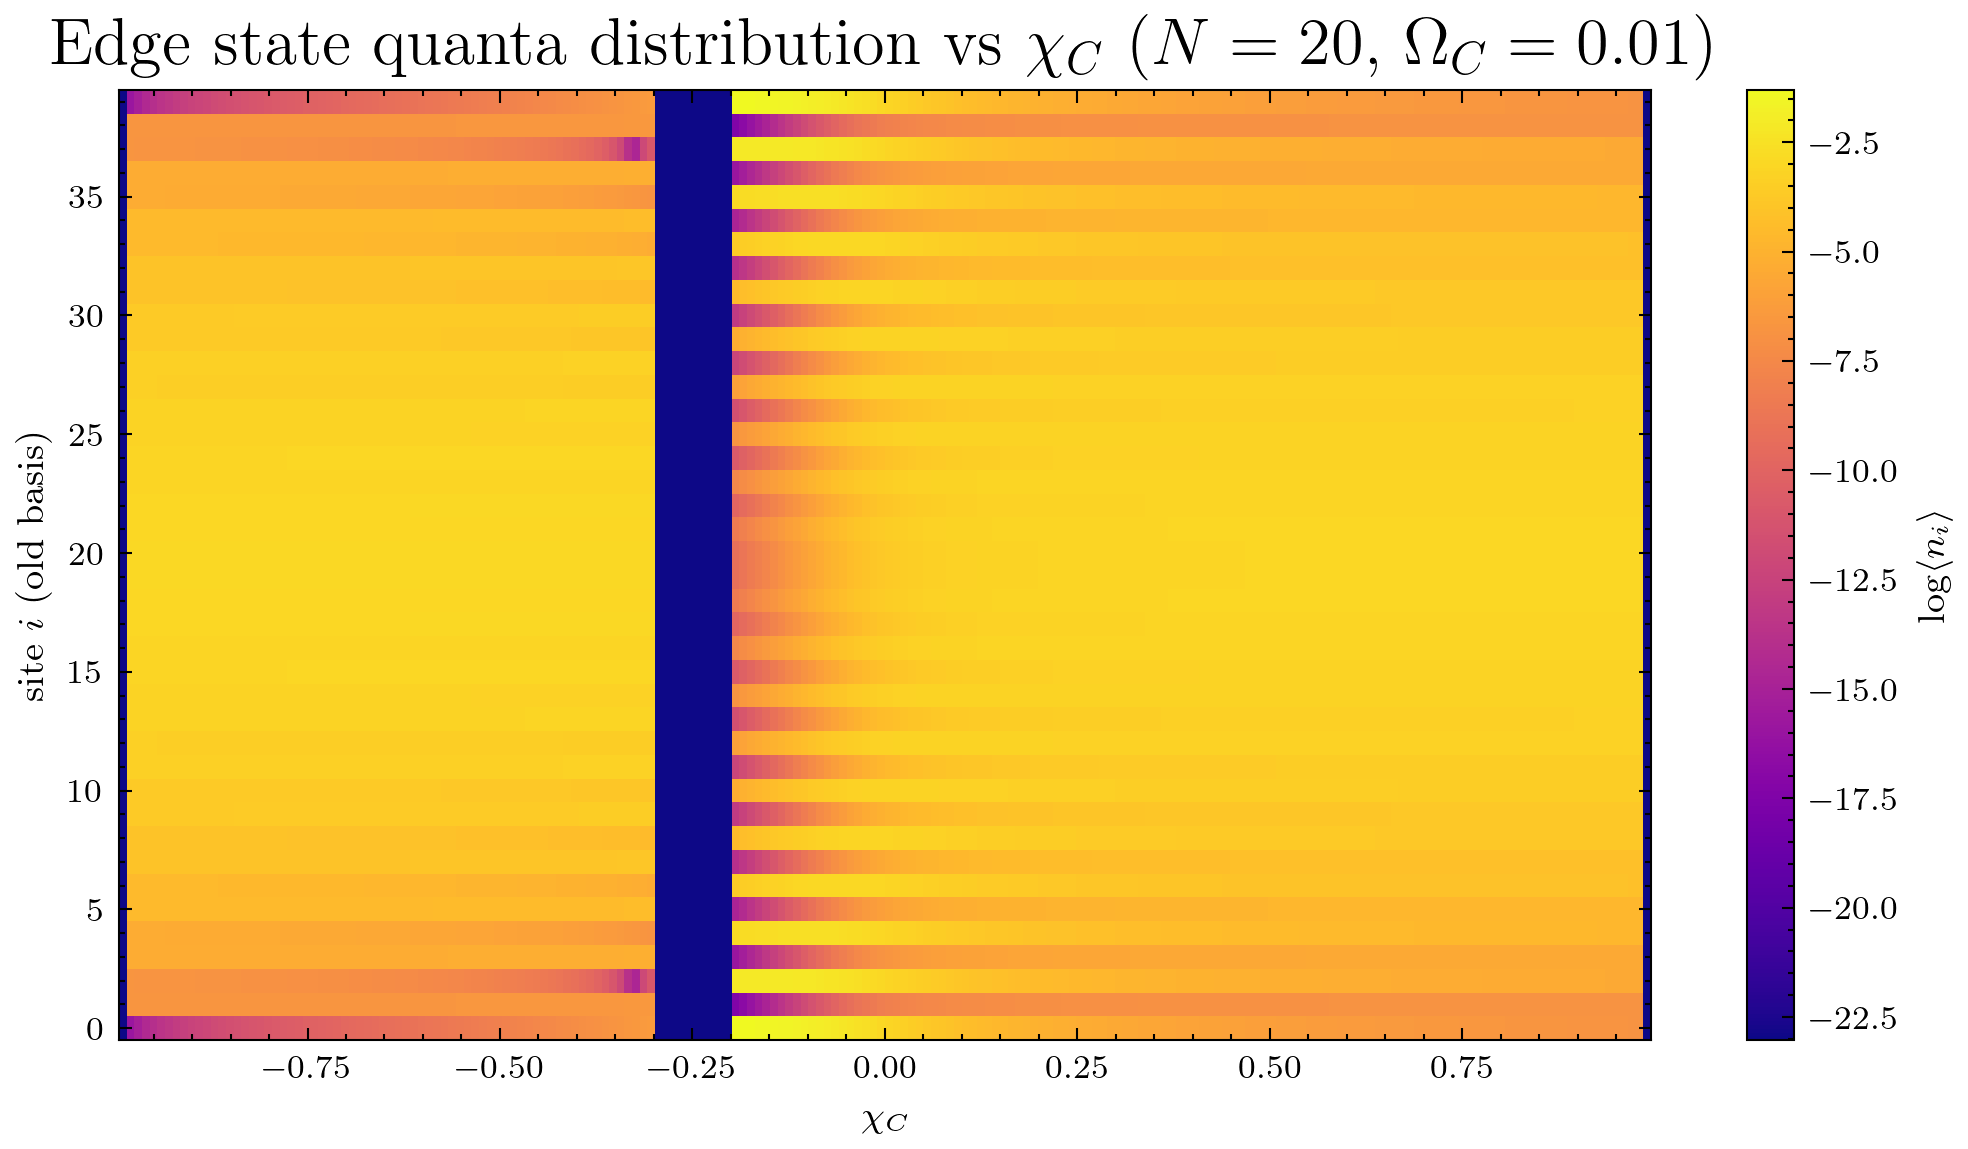

In [342]:
import scipy.sparse.linalg as sla

N_test       = 20
Chi_C_values = np.linspace(-0.99, 0.99, 200)
edge_choice  = 1   # 0: B-sublattice, 1: A-sublattice

quanta_distributions = []

for Chi_C in Chi_C_values:
    print(f"Chi_C = {Chi_C:.4f}")

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- two-sided eigsh ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4]:
        for delta in [0, 1e-3, -1e-3, 1e-2, -1e-2]:
            try:
                evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try + delta, which='LM')
                for i, e in enumerate(evals):
                    if not any(abs(e - e2) < 1e-6 for e2 in results):
                        results[e] = evecs[:, i]
                break
            except RuntimeError:
                continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])

    # --- filter out spurious eigenvalues sitting exactly at sigma=1.0 ---
    # these are numerical artifacts from the shift-invert factorization
    spurious_mask = np.abs(all_energies - 1.0) < 1e-8
    if spurious_mask.any():
        keep          = ~spurious_mask
        all_energies  = all_energies[keep]
        all_states    = all_states[:, keep]

    above_mask = all_energies > 1.0
    below_mask = all_energies < 1.0

    if not above_mask.any() or not below_mask.any():
        quanta_distributions.append(np.zeros(2 * N_test))
        continue

    e_above_idx = np.where(above_mask)[0][np.argmin(all_energies[above_mask] - 1.0)]
    e_below_idx = np.where(below_mask)[0][np.argmax(all_energies[below_mask] - 1.0)]
    V_edge      = all_states[:, [e_below_idx, e_above_idx]]

    # --- sublattice disambiguation ---
    sublattice_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            sublattice_diag[offset + s_idx] = sum(
                n * (1 if i % 2 == 0 else -1) for i, n in enumerate(state))

    full_diag_sub    = np.tile(sublattice_diag, d_ph)
    O_sub            = (V_edge.conj().T * full_diag_sub) @ V_edge
    evals_O, evecs_O = np.linalg.eigh(O_sub)

    if evals_O[0] * evals_O[1] > 0:
        quanta_distributions.append(np.zeros(2 * N_test))
        continue

    V_localized    = V_edge @ evecs_O
    evec           = V_localized[:, edge_choice]

    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat]  = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)
    quanta_distributions.append(dist)

# ------------------------------------------------------------------ #
# Plot
# ------------------------------------------------------------------ #
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array),
                   cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state quanta distribution vs $\chi_C$  ($N={N_test}$, $\Omega_C=0.01$)')
fig.tight_layout()
plt.show()

ok:                  150
sublattice_failed:   10
bulk (ipr too low):  0
no_states_one_side:  40
ok: Chi_C in [-0.751, 0.831]
sublattice_failed: Chi_C in [-0.353, -0.264]
no_states: Chi_C in [-0.990, 0.990]


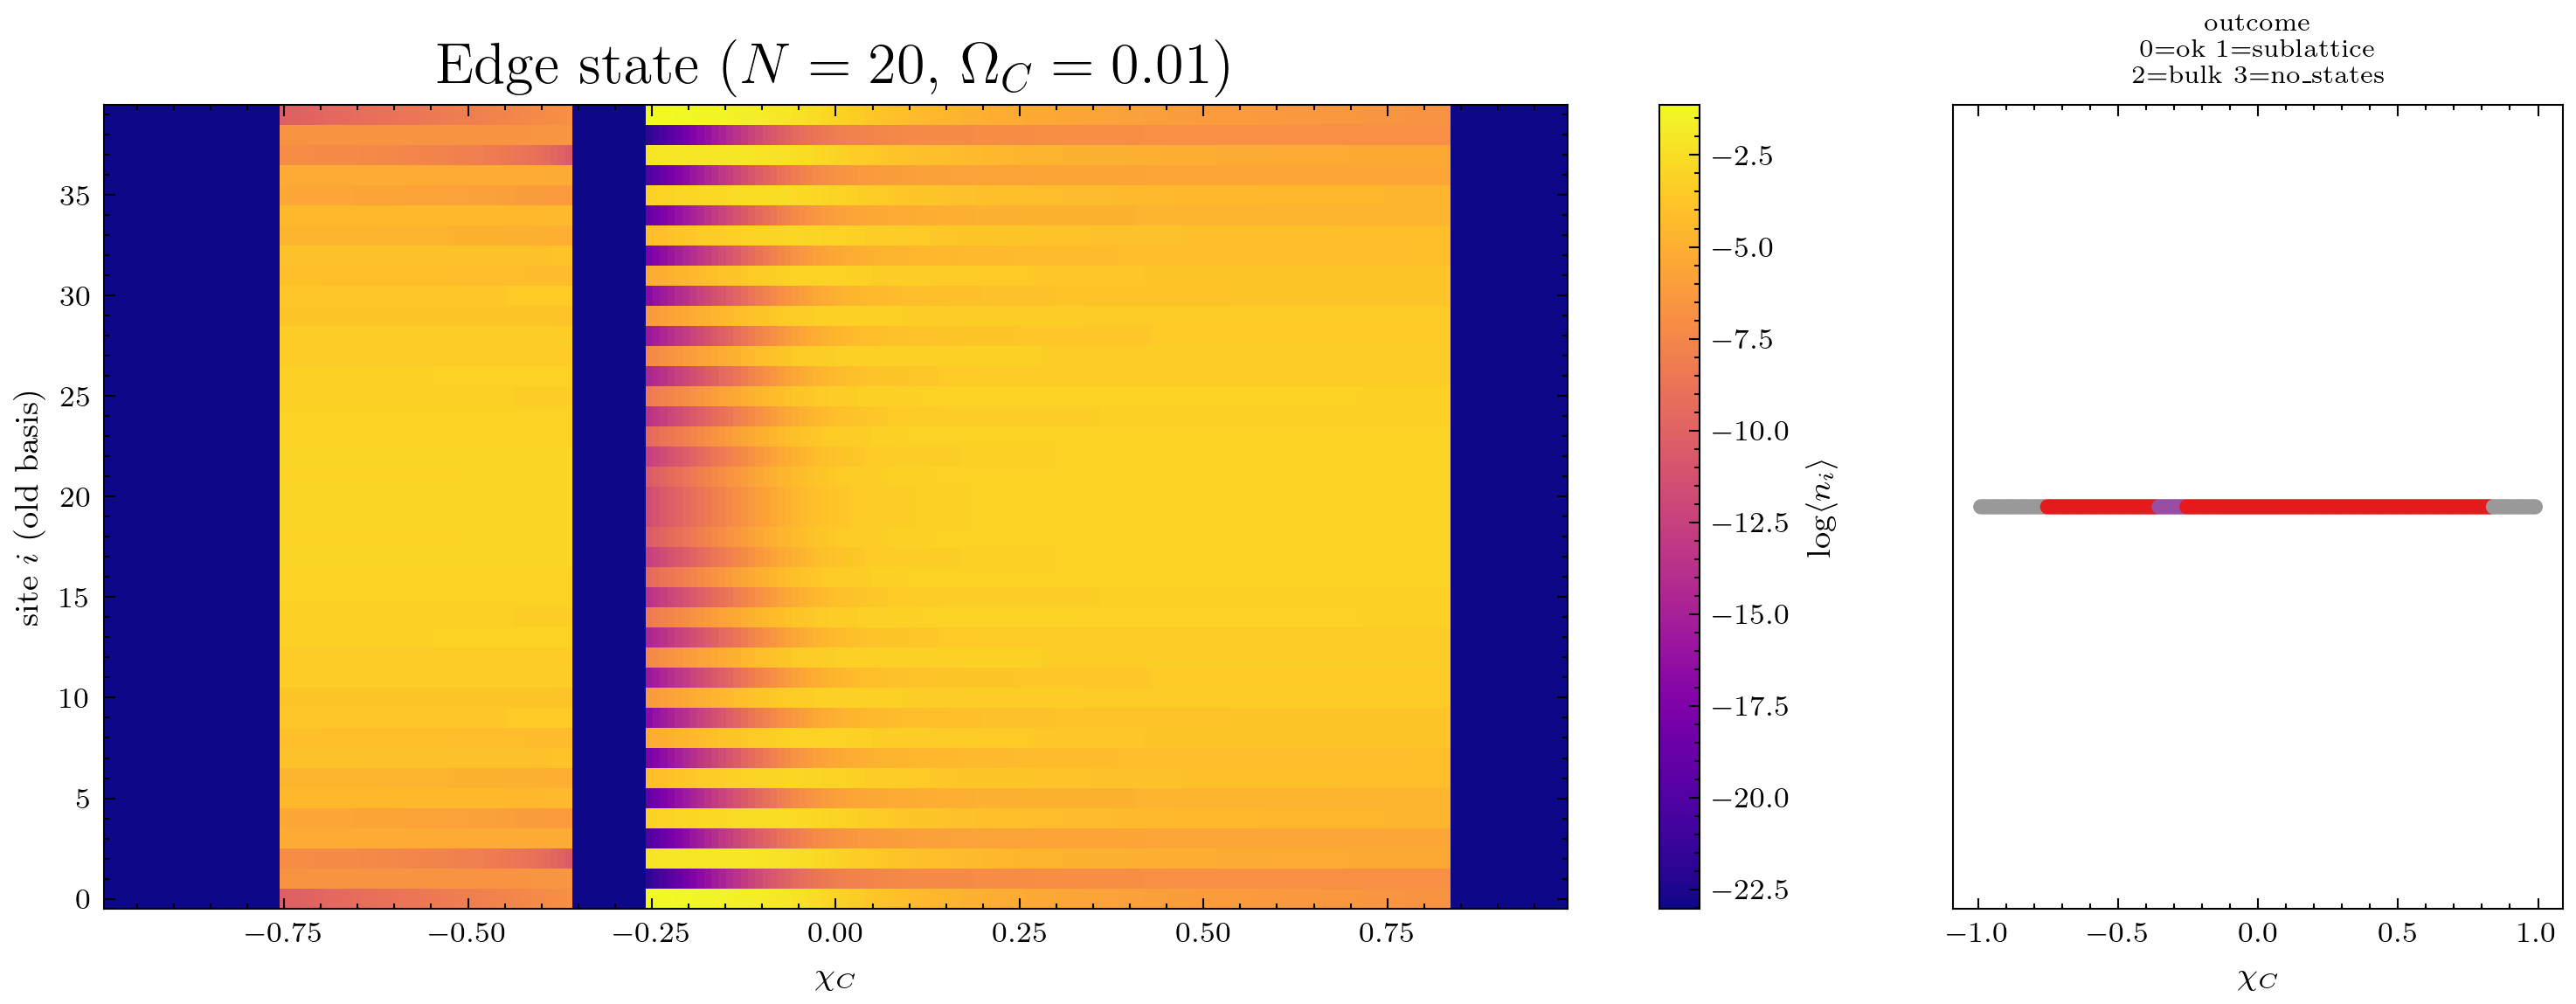

In [350]:
import scipy.sparse.linalg as sla

N_test       = 20
Chi_C_values = np.linspace(-0.99, 0.99, 200)
edge_choice  = 1       # 0: B-sublattice, 1: A-sublattice
ipr_threshold = 5.0 / (2 * N_test)  # must be more localized than ~5 sites

quanta_distributions = []
diagnostics          = []   # track what happened at each Chi_C

for Chi_C in Chi_C_values:

    chain = model(N_test, Omega_C=0.1, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- two-sided eigsh, filter spurious exact hits ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4]:
        for delta in [0, 1e-3, -1e-3, 1e-2, -1e-2]:
            try:
                evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try + delta, which='LM')
                for i, e in enumerate(evals):
                    if not any(abs(e - e2) < 1e-6 for e2 in results):
                        results[e] = evecs[:, i]
                break
            except RuntimeError:
                continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])

    # remove spurious exact eigenvalues at sigma
    keep         = np.abs(all_energies - 1.0) > 1e-8
    all_energies = all_energies[keep]
    all_states   = all_states[:, keep]

    above_mask = all_energies > 1.0
    below_mask = all_energies < 1.0

    if not above_mask.any() or not below_mask.any():
        quanta_distributions.append(np.zeros(2 * N_test))
        diagnostics.append('no_states_one_side')
        continue

    e_above_idx = np.where(above_mask)[0][np.argmin(all_energies[above_mask] - 1.0)]
    e_below_idx = np.where(below_mask)[0][np.argmax(all_energies[below_mask] - 1.0)]
    V_edge      = all_states[:, [e_below_idx, e_above_idx]]

    # --- sublattice disambiguation ---
    sublattice_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            sublattice_diag[offset + s_idx] = sum(
                n * (1 if i % 2 == 0 else -1) for i, n in enumerate(state))

    full_diag_sub    = np.tile(sublattice_diag, d_ph)
    O_sub            = (V_edge.conj().T * full_diag_sub) @ V_edge
    evals_O, evecs_O = np.linalg.eigh(O_sub)

    if evals_O[0] * evals_O[1] > 0:
        quanta_distributions.append(np.zeros(2 * N_test))
        diagnostics.append('sublattice_failed')
        continue

    V_localized    = V_edge @ evecs_O
    evec           = V_localized[:, edge_choice]

    # --- matter state ---
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # --- old basis ---
    synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat]  = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)

    # --- IPR check: reject bulk states ---
    ipr, _, _ = chain.quanta_ipr(matter_vec_new)
    if ipr < ipr_threshold:
        quanta_distributions.append(np.zeros(2 * N_test))
        diagnostics.append(f'bulk_ipr={ipr:.4f}')
        continue

    quanta_distributions.append(dist)
    diagnostics.append(f'ok_ipr={ipr:.4f}')

# ------------------------------------------------------------------ #
# Summary
# ------------------------------------------------------------------ #
diag_arr = np.array(diagnostics)
print(f"ok:                  {np.sum([d.startswith('ok') for d in diagnostics])}")
print(f"sublattice_failed:   {np.sum([d=='sublattice_failed' for d in diagnostics])}")
print(f"bulk (ipr too low):  {np.sum([d.startswith('bulk') for d in diagnostics])}")
print(f"no_states_one_side:  {np.sum([d=='no_states_one_side' for d in diagnostics])}")

# print Chi_C ranges for each outcome
for label in ['ok', 'sublattice_failed', 'bulk', 'no_states']:
    idxs = [i for i, d in enumerate(diagnostics) if d.startswith(label)]
    if idxs:
        print(f"{label}: Chi_C in [{Chi_C_values[idxs[0]]:.3f}, {Chi_C_values[idxs[-1]]:.3f}]")

# ------------------------------------------------------------------ #
# Plot
# ------------------------------------------------------------------ #
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)

fig, axes = plt.subplots(1, 2, figsize=(10, 4),
                         gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array),
                   cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state ($N={N_test}$, $\Omega_C=0.01$)')

# right panel: outcome map
outcome_num = np.array([0 if d.startswith('ok') else
                         1 if d == 'sublattice_failed' else
                         2 if d.startswith('bulk') else 3
                         for d in diagnostics])
axes[1].scatter(Chi_C_values, np.zeros_like(Chi_C_values),
                c=outcome_num, cmap='Set1', s=10)
axes[1].set_xlabel(r'$\chi_C$')
axes[1].set_yticks([])
axes[1].set_title('outcome\n0=ok 1=sublattice\n2=bulk 3=no_states', fontsize=7)

fig.tight_layout()
plt.show()

IPR range in topological region (Chi_C < 0):
  min=0.0000  max=0.1870
IPR range in trivial region (Chi_C > 0):
  min=0.0000  max=0.0357

Points passing IPR cutoff 0.03: 188/200
Chi_C range: [-0.980, 0.980]


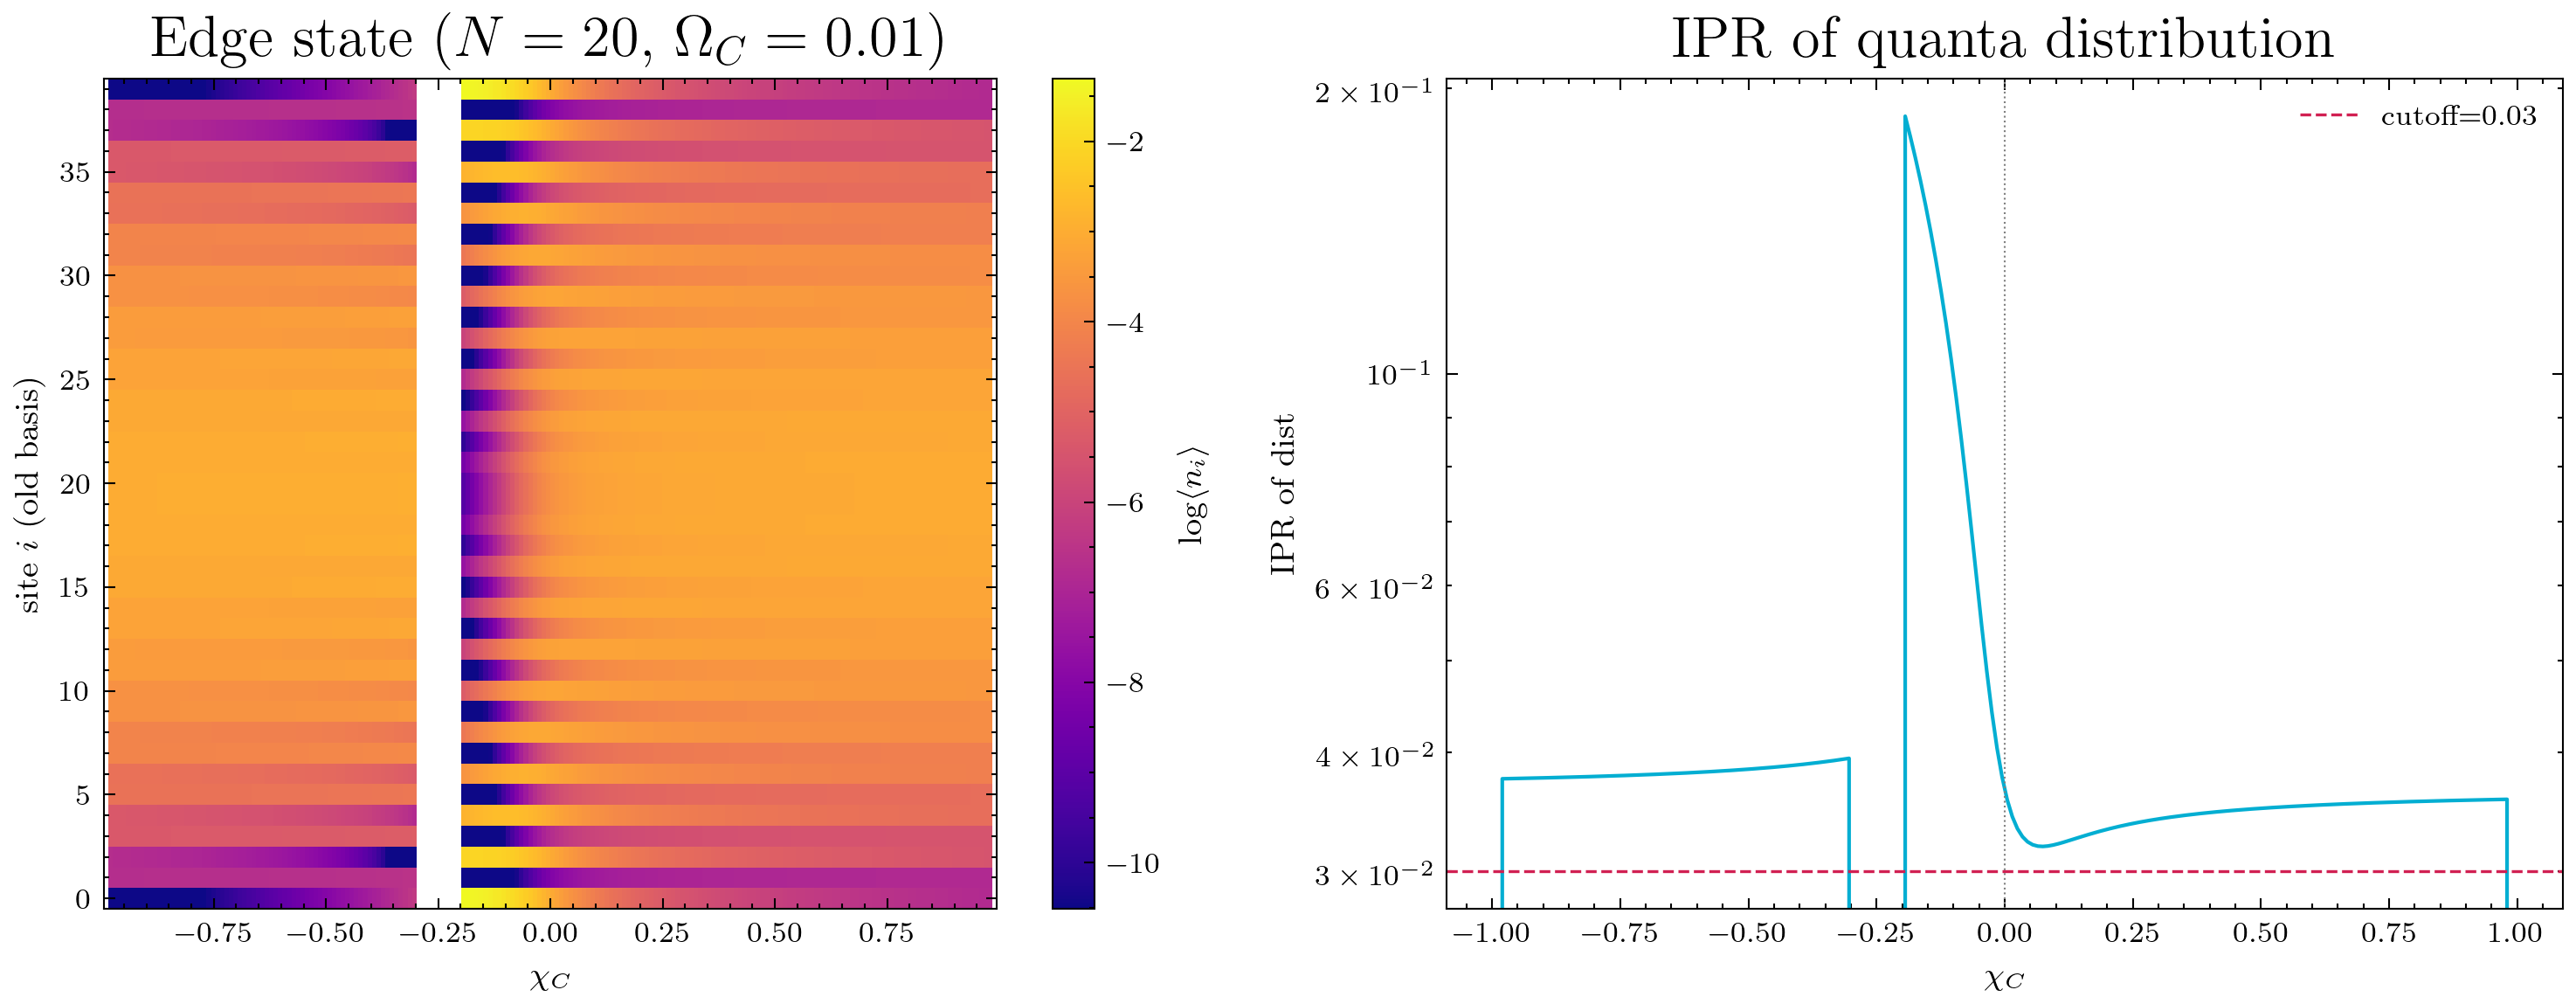

In [347]:
# ------------------------------------------------------------------ #
# Separate topological from trivial using IPR threshold
# and fix colormap per region
# ------------------------------------------------------------------ #
dist_array = np.array(quanta_distributions).T   # (2N, n_Chi)

# --- tune this: from diagnostic, topological states had ipr ~ 1.0
# bulk states had ipr ~ 1/(2N) ~ 0.025
# set threshold between them
ipr_per_chi = []
for i, Chi_C in enumerate(Chi_C_values):
    d = dist_array[:, i]
    if d.sum() > 1e-9:
        ipr_per_chi.append(np.sum(d**2))
    else:
        ipr_per_chi.append(0.0)
ipr_per_chi = np.array(ipr_per_chi)

print("IPR range in topological region (Chi_C < 0):")
topo_mask = Chi_C_values < 0
print(f"  min={ipr_per_chi[topo_mask].min():.4f}  max={ipr_per_chi[topo_mask].max():.4f}")
print("IPR range in trivial region (Chi_C > 0):")
triv_mask = Chi_C_values > 0
print(f"  min={ipr_per_chi[triv_mask].min():.4f}  max={ipr_per_chi[triv_mask].max():.4f}")

# mask out trivial phase and transition
ipr_cutoff = 0.03   # tune based on printout above
valid_mask  = ipr_per_chi > ipr_cutoff
print(f"\nPoints passing IPR cutoff {ipr_cutoff}: {valid_mask.sum()}/200")
print(f"Chi_C range: [{Chi_C_values[valid_mask].min():.3f}, {Chi_C_values[valid_mask].max():.3f}]")

dist_plot = dist_array.copy()
dist_plot[:, ~valid_mask] = np.nan   # blank out non-edge regions

# ------------------------------------------------------------------ #
# Plot with symmetric colormap limits focused on topological region
# ------------------------------------------------------------------ #
valid_data = dist_plot[:, valid_mask]
vmin = np.log(np.nanmax(valid_data) * 1e-4)   # 4 decades below peak
vmax = np.log(np.nanmax(valid_data))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- left: distribution heatmap ---
ax = axes[0]
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(np.clip(dist_plot, 1e-30, None)),
                   cmap='plasma', shading='auto',
                   vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state ($N={N_test}$, $\Omega_C=0.01$)')

# --- right: IPR vs Chi_C to see the threshold ---
ax = axes[1]
ax.plot(Chi_C_values, ipr_per_chi, color='#03AED2', lw=1.0)
ax.axhline(ipr_cutoff, color='#D12052', lw=0.8, ls='--', label=f'cutoff={ipr_cutoff}')
ax.axvline(0, color='gray', lw=0.5, ls=':')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('IPR of dist')
ax.set_title('IPR of quanta distribution')
ax.legend(fontsize=8)
ax.set_yscale('log')

fig.tight_layout()
plt.show()

In [349]:
# diagnostic: inspect old_vec for one topological point
Chi_C = -0.70

chain = model(N_test, Omega_C=0.1, Chi_C=Chi_C, omega_r=10.0,
              gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
chain.matter_hamiltonians(n_excitations=1, layers=0)
chain.build_full_hamiltonian()
chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

d_ph  = chain.fock_photon
d_mat = chain.fock_dim

results = {}
for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4]:
    for delta in [0, 1e-3, -1e-3]:
        try:
            evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try+delta, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-6 for e2 in results):
                    results[e] = evecs[:, i]
            break
        except RuntimeError:
            continue

all_energies = np.array(sorted(results.keys()))
all_states   = np.column_stack([results[e] for e in all_energies])
keep         = np.abs(all_energies - 1.0) > 1e-8
all_energies = all_energies[keep]
all_states   = all_states[:, keep]

above_mask  = all_energies > 1.0
below_mask  = all_energies < 1.0
e_above_idx = np.where(above_mask)[0][np.argmin(all_energies[above_mask] - 1.0)]
e_below_idx = np.where(below_mask)[0][np.argmax(all_energies[below_mask] - 1.0)]
V_edge      = all_states[:, [e_below_idx, e_above_idx]]

sublattice_diag = np.zeros(d_mat)
for exc, arr in chain.fock_states.items():
    offset = chain.fock_offsets[exc]
    for s_idx, state in enumerate(arr):
        sublattice_diag[offset + s_idx] = sum(
            n * (1 if i % 2 == 0 else -1) for i, n in enumerate(state))

full_diag_sub    = np.tile(sublattice_diag, d_ph)
O_sub            = (V_edge.conj().T * full_diag_sub) @ V_edge
evals_O, evecs_O = np.linalg.eigh(O_sub)
V_localized      = V_edge @ evecs_O
evec             = V_localized[:, 1]

rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
_, evecs_rho   = np.linalg.eigh(rho_matter)
matter_vec_new = evecs_rho[:, -1]

synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
synth_vec[:d_mat]  = matter_vec_new

old_decomp = chain.decompose_to_old_fock(synth_vec)
old_sector = old_decomp.get(0, {})

old_vec = np.zeros(d_mat, dtype=complex)
for state_tuple, coeff in old_sector.items():
    exc = sum(state_tuple)
    if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
        s_idx = chain.fock_state_index[exc][state_tuple]
        old_vec[chain.fock_offsets[exc] + s_idx] += coeff

print(f"old_vec norm: {np.linalg.norm(old_vec):.6f}")
print(f"old_sector keys (first 5): {list(old_sector.keys())[:5]}")
print(f"old_sector excitations present: {sorted(set(sum(k) for k in old_sector.keys()))}")

# check weight per excitation layer
for exc in sorted(chain.fock_offsets.keys()):
    offset = chain.fock_offsets[exc]
    n_states = len(chain.fock_states[exc])
    layer_norm = np.linalg.norm(old_vec[offset:offset+n_states])
    print(f"  exc={exc}  layer_norm={layer_norm:.6f}  n_states={n_states}")

dist = chain.quanta_distribution(old_vec)
print(f"\ndist: {np.round(dist, 4)}")
print(f"dist IPR: {np.sum(dist**2):.6f}")

print(f"dist max site: {np.argmax(dist)}  value: {dist.max():.6f}")

old_vec norm: 1.000000
old_sector keys (first 5): [(np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0

Full spectrum:
  [ 0]  E=0.99499521  IPR=1.000000 <-- EDGE
  [ 1]  E=0.99501843  IPR=1.000000 <-- EDGE
  [ 2]  E=0.99505675  IPR=1.000000 <-- EDGE
  [ 3]  E=0.99510959  IPR=1.000000 <-- EDGE
  [ 4]  E=0.99517614  IPR=1.000000 <-- EDGE
  [ 5]  E=0.99525535  IPR=1.000000 <-- EDGE
  [ 6]  E=0.99534590  IPR=1.000000 <-- EDGE
  [ 7]  E=0.99544622  IPR=1.000000 <-- EDGE
  [ 8]  E=0.99555447  IPR=1.000000 <-- EDGE
  [ 9]  E=0.99566851  IPR=1.000000 <-- EDGE
  [10]  E=0.99578593  IPR=1.000000 <-- EDGE
  [11]  E=0.99590402  IPR=1.000000 <-- EDGE
  [12]  E=0.99601978  IPR=1.000000 <-- EDGE
  [13]  E=0.99613001  IPR=1.000000 <-- EDGE
  [14]  E=0.99623133  IPR=1.000000 <-- EDGE
  [15]  E=0.99632031  IPR=1.000000 <-- EDGE
  [16]  E=0.99639367  IPR=1.000000 <-- EDGE
  [17]  E=0.99644848  IPR=1.000000 <-- EDGE
  [18]  E=0.99648238  IPR=1.000000 <-- EDGE
  [19]  E=1.00000000  IPR=0.708555 <-- EDGE
  [20]  E=1.00000000  IPR=0.708555 <-- EDGE
  [21]  E=1.00350529  IPR=1.000000 <-- EDGE
  [22]  E=1.00353

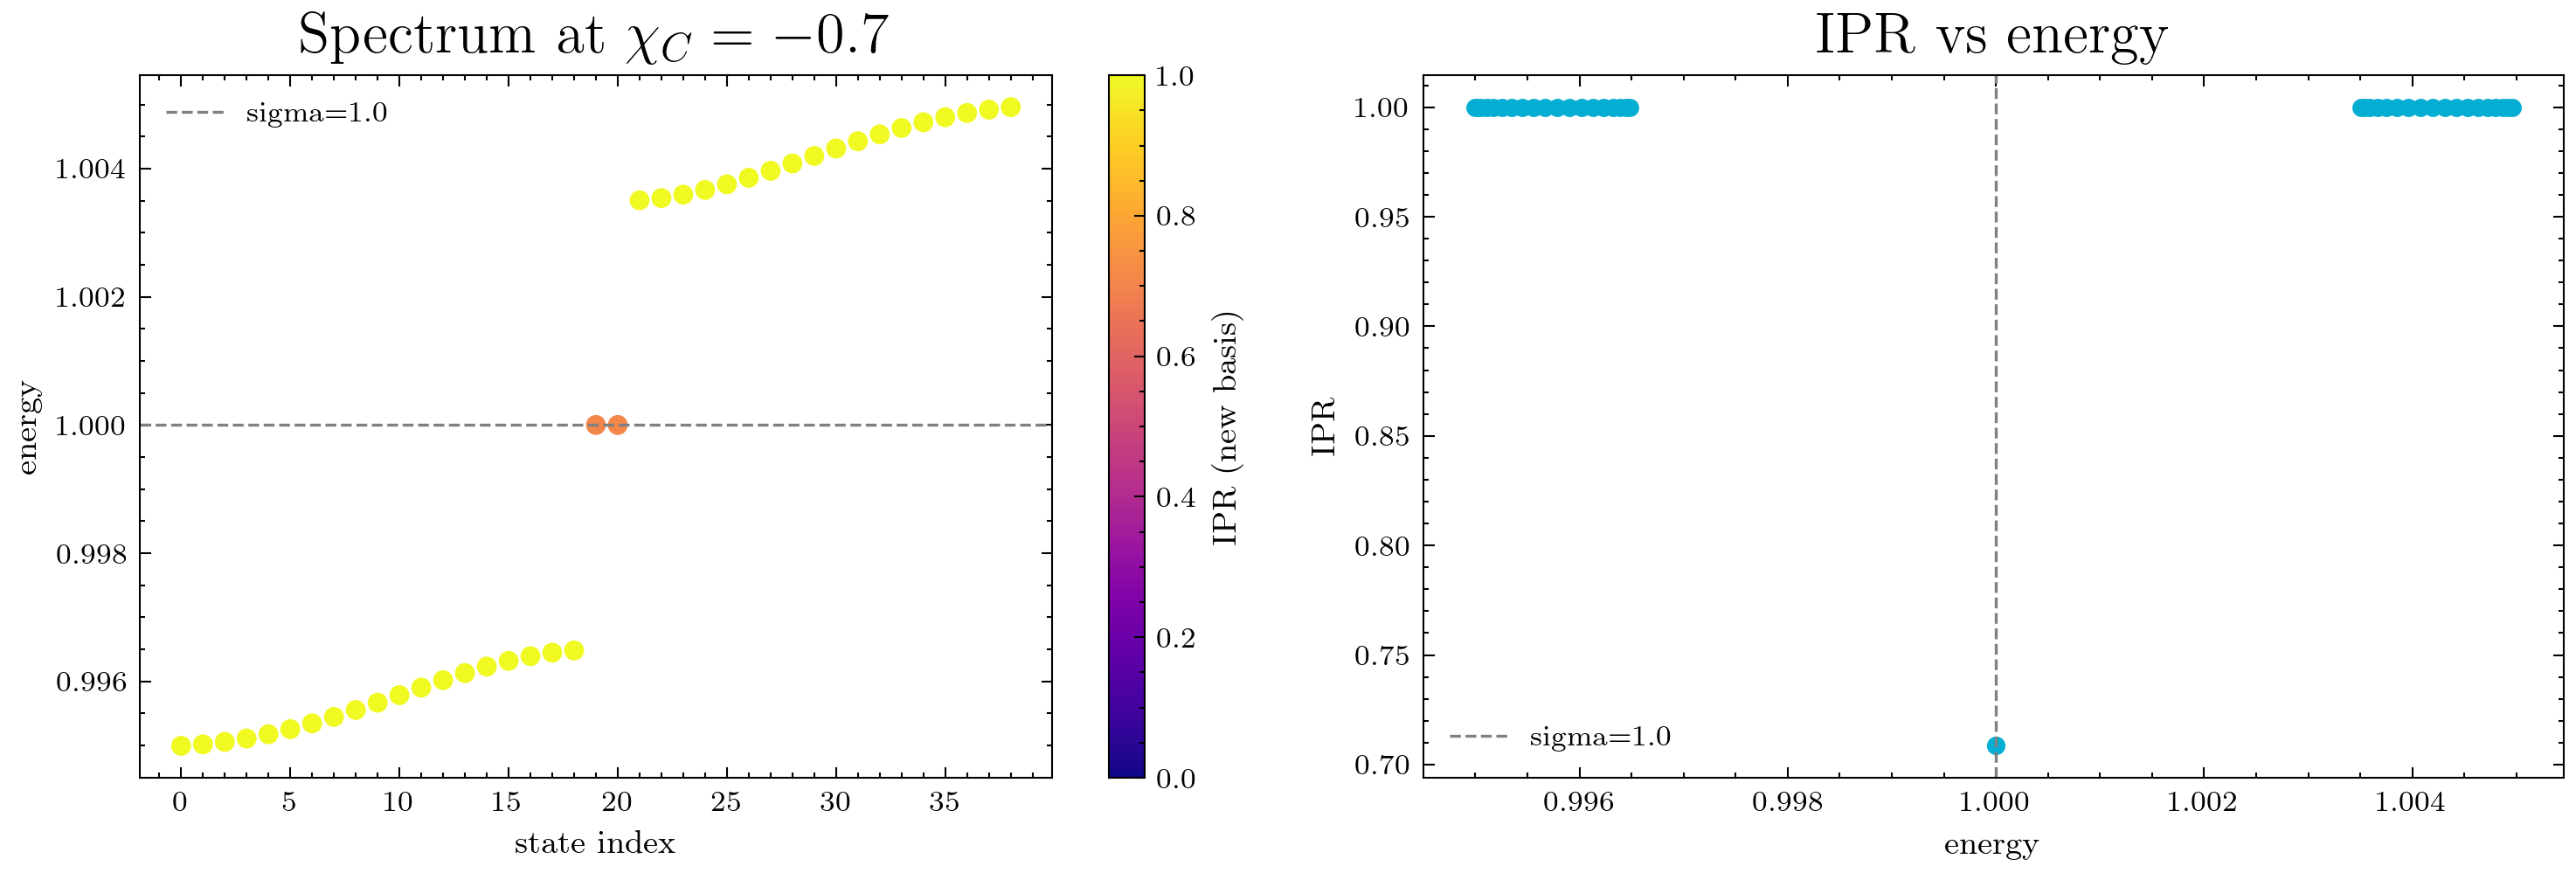

In [352]:
Chi_C = -0.70

chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
              gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
chain.matter_hamiltonians(n_excitations=1, layers=0)
chain.build_full_hamiltonian()
chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

# get full spectrum
k_all = 2 * N_test-1
evals_all, evecs_all = sla.eigsh(chain.H, k=k_all, which='SA')
idx_sort  = np.argsort(evals_all)
evals_all = evals_all[idx_sort]
evecs_all = evecs_all[:, idx_sort]

# IPR in new (Bogoliubov) basis for each state
iprs_new = []
for col in range(evecs_all.shape[1]):
    rho_m = chain.partial_trace(evecs_all[:, col], which_to_keep='matter')
    _, evecs_rho = np.linalg.eigh(rho_m)
    mv = evecs_rho[:, -1]
    ipr, _, _ = chain.quanta_ipr(mv)
    iprs_new.append(ipr)
iprs_new = np.array(iprs_new)

print("Full spectrum:")
for i, (e, ipr) in enumerate(zip(evals_all, iprs_new)):
    marker = ' <-- EDGE' if ipr > 0.3 else ''
    print(f"  [{i:2d}]  E={e:.8f}  IPR={ipr:.6f}{marker}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
sc = ax.scatter(np.arange(k_all), evals_all, c=iprs_new,
                cmap='plasma', s=20, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='IPR (new basis)')
ax.axhline(1.0, color='gray', lw=0.8, ls='--', label='sigma=1.0')
ax.set_xlabel('state index')
ax.set_ylabel('energy')
ax.set_title(rf'Spectrum at $\chi_C={Chi_C}$')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(evals_all, iprs_new, 'o', ms=4, color='#03AED2')
ax.axvline(1.0, color='gray', lw=0.8, ls='--', label='sigma=1.0')
ax.set_xlabel('energy')
ax.set_ylabel('IPR')
ax.set_title('IPR vs energy')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [353]:
# take a bulk state (index 0) and inspect quanta_ipr internals
col = 0
rho_m = chain.partial_trace(evecs_all[:, col], which_to_keep='matter')
_, evecs_rho = np.linalg.eigh(rho_m)
matter_vec = evecs_rho[:, -1]

print(f"matter_vec norm: {np.linalg.norm(matter_vec):.6f}")
print(f"matter_vec nonzero entries: {np.sum(np.abs(matter_vec) > 1e-10)}")
print(f"matter_vec max entry: {np.abs(matter_vec).max():.6f}")
print(f"matter_vec top 5 entries: {np.sort(np.abs(matter_vec))[-5:]}")

# manually compute quanta distribution
n = 2 * chain.N
distribution = np.zeros(n)
total = 0.0
for exc, arr in chain.fock_states.items():
    offset = chain.fock_offsets[exc]
    for s_idx, state in enumerate(arr):
        coeff = matter_vec[offset + s_idx]
        w = abs(coeff)**2
        if w > 1e-15:
            for i, ni in enumerate(state):
                distribution[i] += w * ni
            total += w

print(f"\nManual distribution (unnorm): {np.round(distribution, 4)}")
print(f"Total weight: {total:.6f}")
print(f"Distribution sum: {distribution.sum():.6f}")
if distribution.sum() > 1e-10:
    dist_norm = distribution / distribution.sum()
    ipr_manual = np.sum(dist_norm**2)
    print(f"Manual IPR: {ipr_manual:.6f}")

# now call quanta_ipr directly
ipr, xi, dist_out = chain.quanta_ipr(matter_vec)
print(f"\nquanta_ipr output: IPR={ipr:.6f}, xi={xi:.6f}")
print(f"dist_out: {np.round(dist_out, 4)}")

matter_vec norm: 1.000000
matter_vec nonzero entries: 1
matter_vec max entry: 1.000000
matter_vec top 5 entries: [1.28397293e-13 2.73184253e-13 2.82541351e-13 1.72126202e-12
 1.00000000e+00]

Manual distribution (unnorm): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total weight: 1.000000
Distribution sum: 1.000000
Manual IPR: 1.000000

quanta_ipr output: IPR=1.000000, xi=1.000000
dist_out: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [354]:
# The edge states sit at E=1.0 exactly (the diagonal pinning energy).
# Use sigma=1.0 but filter by |E - 1.0| < gap_threshold
# From spectrum: bulk bands are at ~0.995 and ~1.004, so gap ~ 0.003

gap_threshold = 1e-4   # edge states are within this of 1.0; bulk is >0.003 away

# in the sweep, after getting all_energies:
edge_candidates = np.abs(all_energies - 1.0) < gap_threshold
if edge_candidates.sum() < 2:
    # couldn't find both edge states near 1.0 — fall back to closest pair
    edge_candidates = np.argsort(np.abs(all_energies - 1.0))[:2]
    V_edge = all_states[:, edge_candidates]
else:
    V_edge = all_states[:, edge_candidates]

Total points: 200
  ok_near=2: 45
  ok_near=: 45
  fallback: 155
  sublattice_failed: 42


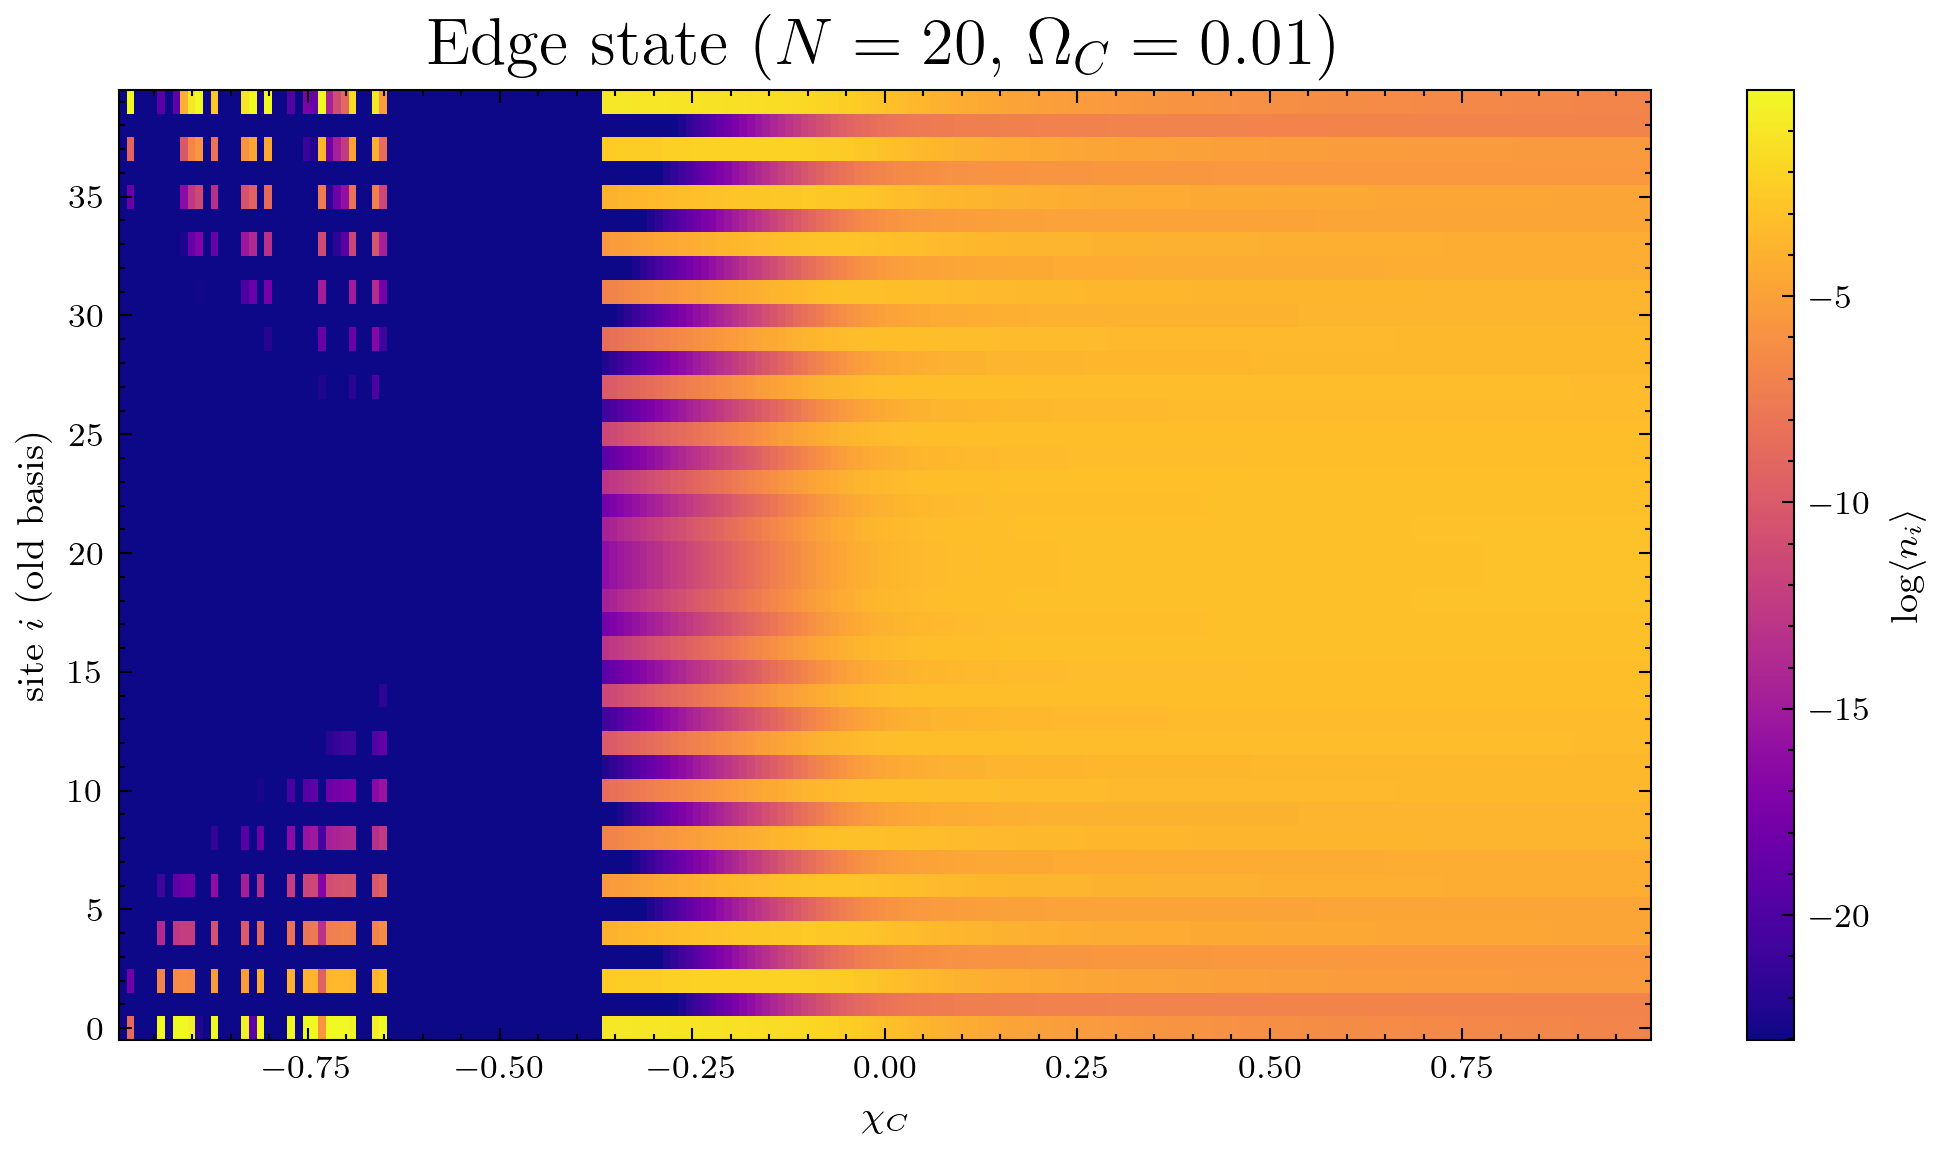

In [355]:
import scipy.sparse.linalg as sla

N_test       = 20
Chi_C_values = np.linspace(-0.99, 0.99, 200)
edge_choice  = 1       # 0: B-sublattice, 1: A-sublattice
gap_threshold = 5e-4   # edge states sit within this of E=1.0; bulk is >0.003 away

quanta_distributions = []
diagnostics          = []

for Chi_C in Chi_C_values:

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- target sigma=1.0 directly, get enough states ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])

    # --- select states within gap_threshold of 1.0 ---
    # DO NOT filter out states at exactly 1.0 — those ARE the edge states
    near_mask = np.abs(all_energies - 1.0) < gap_threshold

    if near_mask.sum() < 2:
        # gap_threshold too tight or near transition — take 2 closest
        near_idx  = np.argsort(np.abs(all_energies - 1.0))[:2]
        near_mask = np.zeros(len(all_energies), dtype=bool)
        near_mask[near_idx] = True
        diagnostics.append('fallback_closest2')
    else:
        diagnostics.append(f'ok_near={near_mask.sum()}')

    V_near = all_states[:, near_mask]

    # if more than 2 candidates, take the 2 closest to 1.0
    if V_near.shape[1] > 2:
        best2    = np.argsort(np.abs(all_energies[near_mask] - 1.0))[:2]
        V_near   = V_near[:, best2]

    # --- sublattice disambiguation ---
    sublattice_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            sublattice_diag[offset + s_idx] = sum(
                n * (1 if i % 2 == 0 else -1) for i, n in enumerate(state))

    full_diag_sub    = np.tile(sublattice_diag, d_ph)
    O_sub            = (V_near.conj().T * full_diag_sub) @ V_near
    evals_O, evecs_O = np.linalg.eigh(O_sub)

    if evals_O[0] * evals_O[1] > 0:
        quanta_distributions.append(np.zeros(2 * N_test))
        diagnostics[-1] += '_sublattice_failed'
        continue

    V_localized    = V_near @ evecs_O
    evec           = V_localized[:, edge_choice]

    # --- matter state ---
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # --- old basis ---
    synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat]  = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)
    quanta_distributions.append(dist)

# summary
print(f"Total points: {len(diagnostics)}")
for label in ['ok_near=2', 'ok_near=', 'fallback', 'sublattice_failed']:
    n = sum(1 for d in diagnostics if label in d)
    if n: print(f"  {label}: {n}")

# ------------------------------------------------------------------ #
# Plot
# ------------------------------------------------------------------ #
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array),
                   cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state ($N={N_test}$, $\Omega_C=0.01$)')
fig.tight_layout()
plt.show()

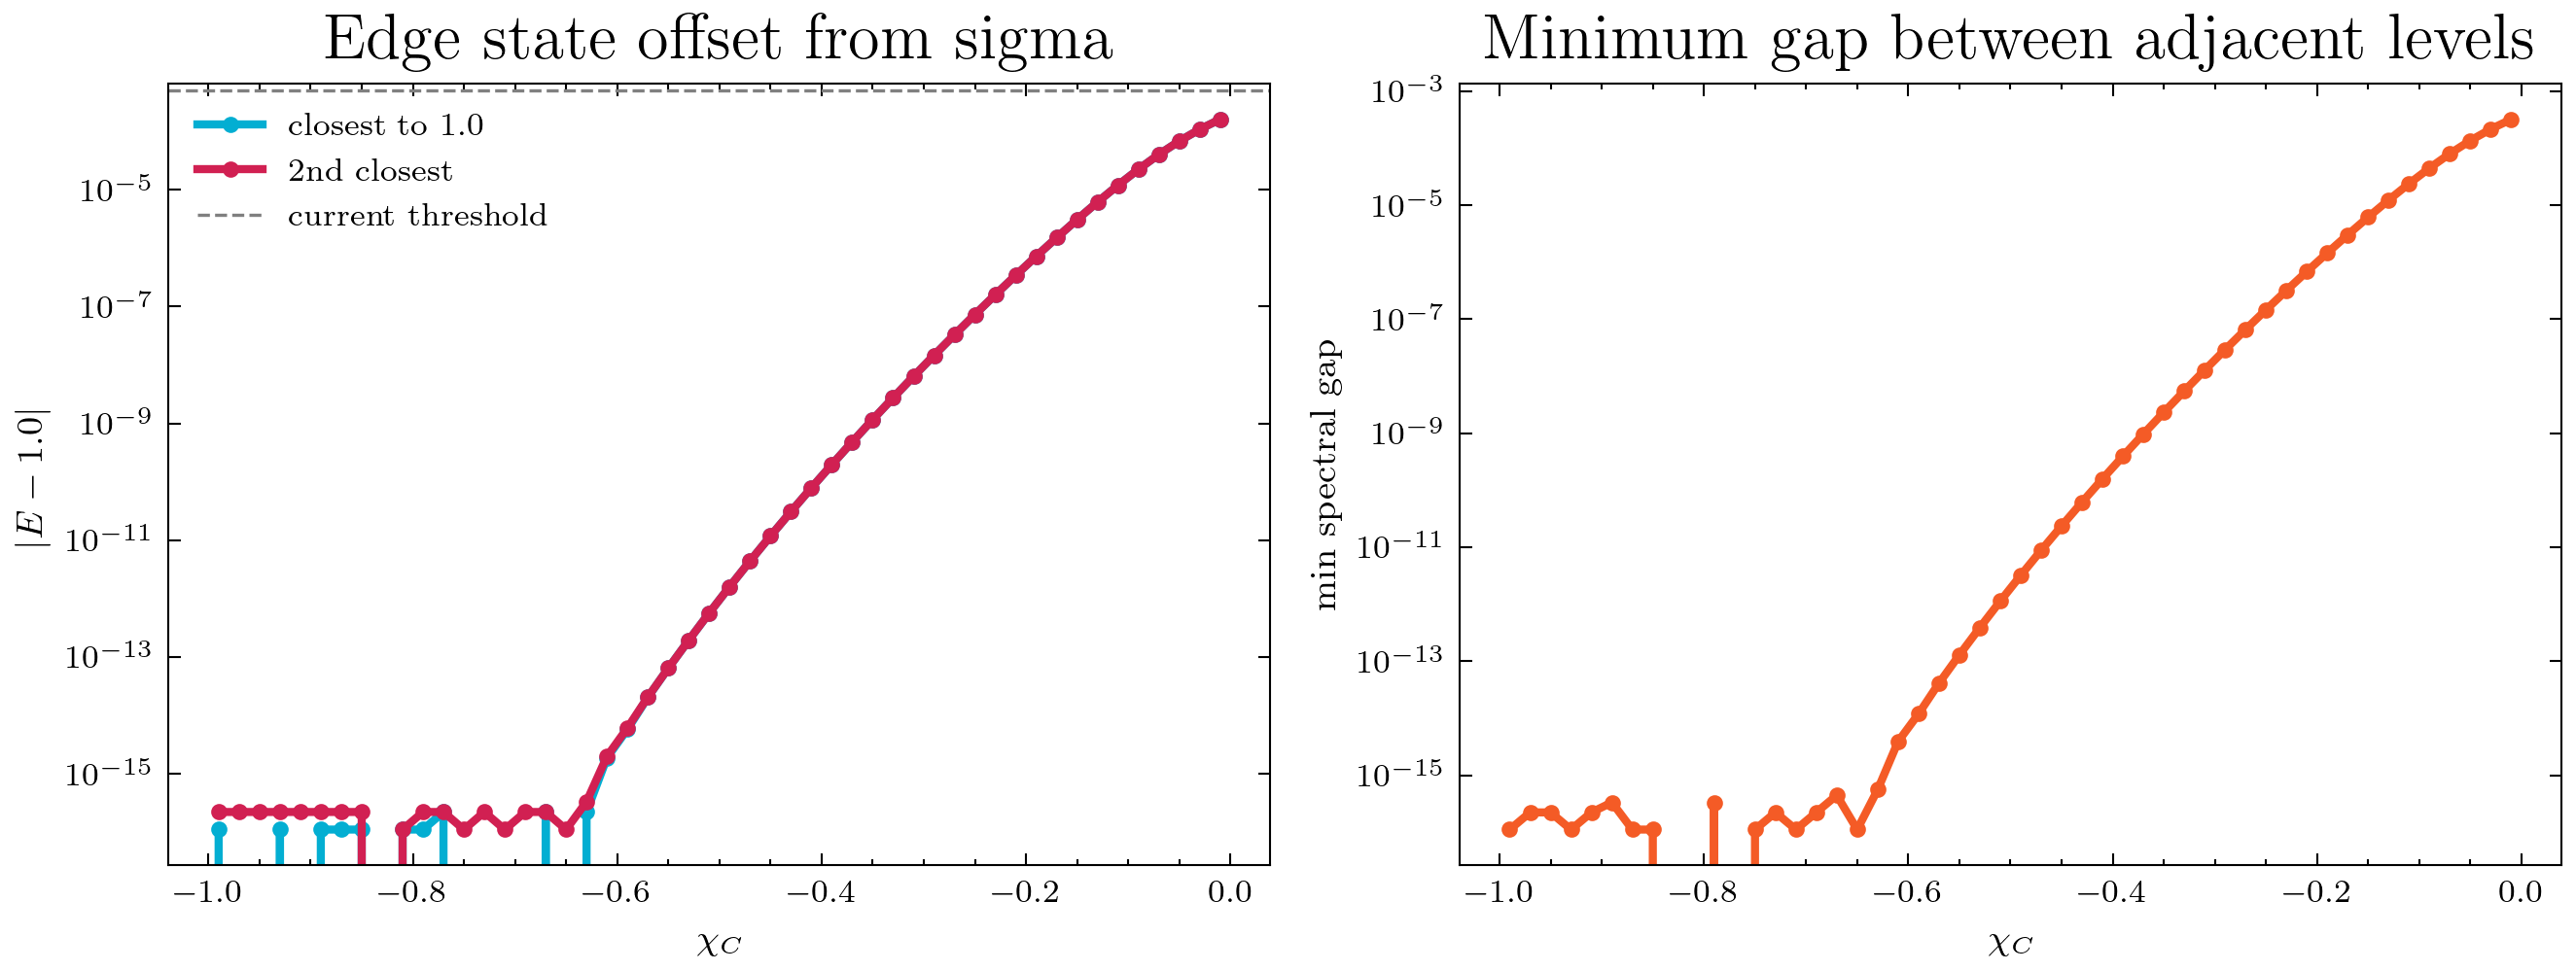

Max |E-1.0| for closest state: 0.00016098522676855076
Min |E-1.0| for 2nd closest:   0.0
-> safe threshold sits between these two values


In [357]:
# scan how close the edge states sit to 1.0 across Chi_C
Chi_C_scan  = np.linspace(-0.99, -0.01, 50)
edge_offsets = []

for Chi_C in Chi_C_scan:
    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()

    try:
        evals, _ = sla.eigsh(chain.H, k=6, sigma=1.0+1e-4, which='LM')
        evals    = np.sort(evals)
        # find the two closest to 1.0
        dists = np.abs(evals - 1.0)
        top2  = np.sort(dists)[:2]
        edge_offsets.append((Chi_C, top2[0], top2[1],
                             np.min(np.diff(np.sort(evals)))))  # min gap in spectrum
    except RuntimeError:
        edge_offsets.append((Chi_C, np.nan, np.nan, np.nan))

edge_offsets = np.array(edge_offsets)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

ax = axes[0]
ax.semilogy(edge_offsets[:, 0], edge_offsets[:, 1], 'o-', ms=3,
            color='#03AED2', label='closest to 1.0')
ax.semilogy(edge_offsets[:, 0], edge_offsets[:, 2], 'o-', ms=3,
            color='#D12052', label='2nd closest')
ax.axhline(5e-4, color='gray', ls='--', lw=0.8, label='current threshold')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel(r'$|E - 1.0|$')
ax.set_title('Edge state offset from sigma')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogy(edge_offsets[:, 0], edge_offsets[:, 3], 'o-', ms=3,
            color='#F45B26')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('min spectral gap')
ax.set_title('Minimum gap between adjacent levels')

fig.tight_layout()
plt.show()

print("Max |E-1.0| for closest state:", np.nanmax(edge_offsets[:, 1]))
print("Min |E-1.0| for 2nd closest:  ", np.nanmin(edge_offsets[:, 2]))
print("-> safe threshold sits between these two values")

  fallback_spatial: 41
  fallback_sublattice: 79
  ok_spatial: 3
  ok_sublattice: 77


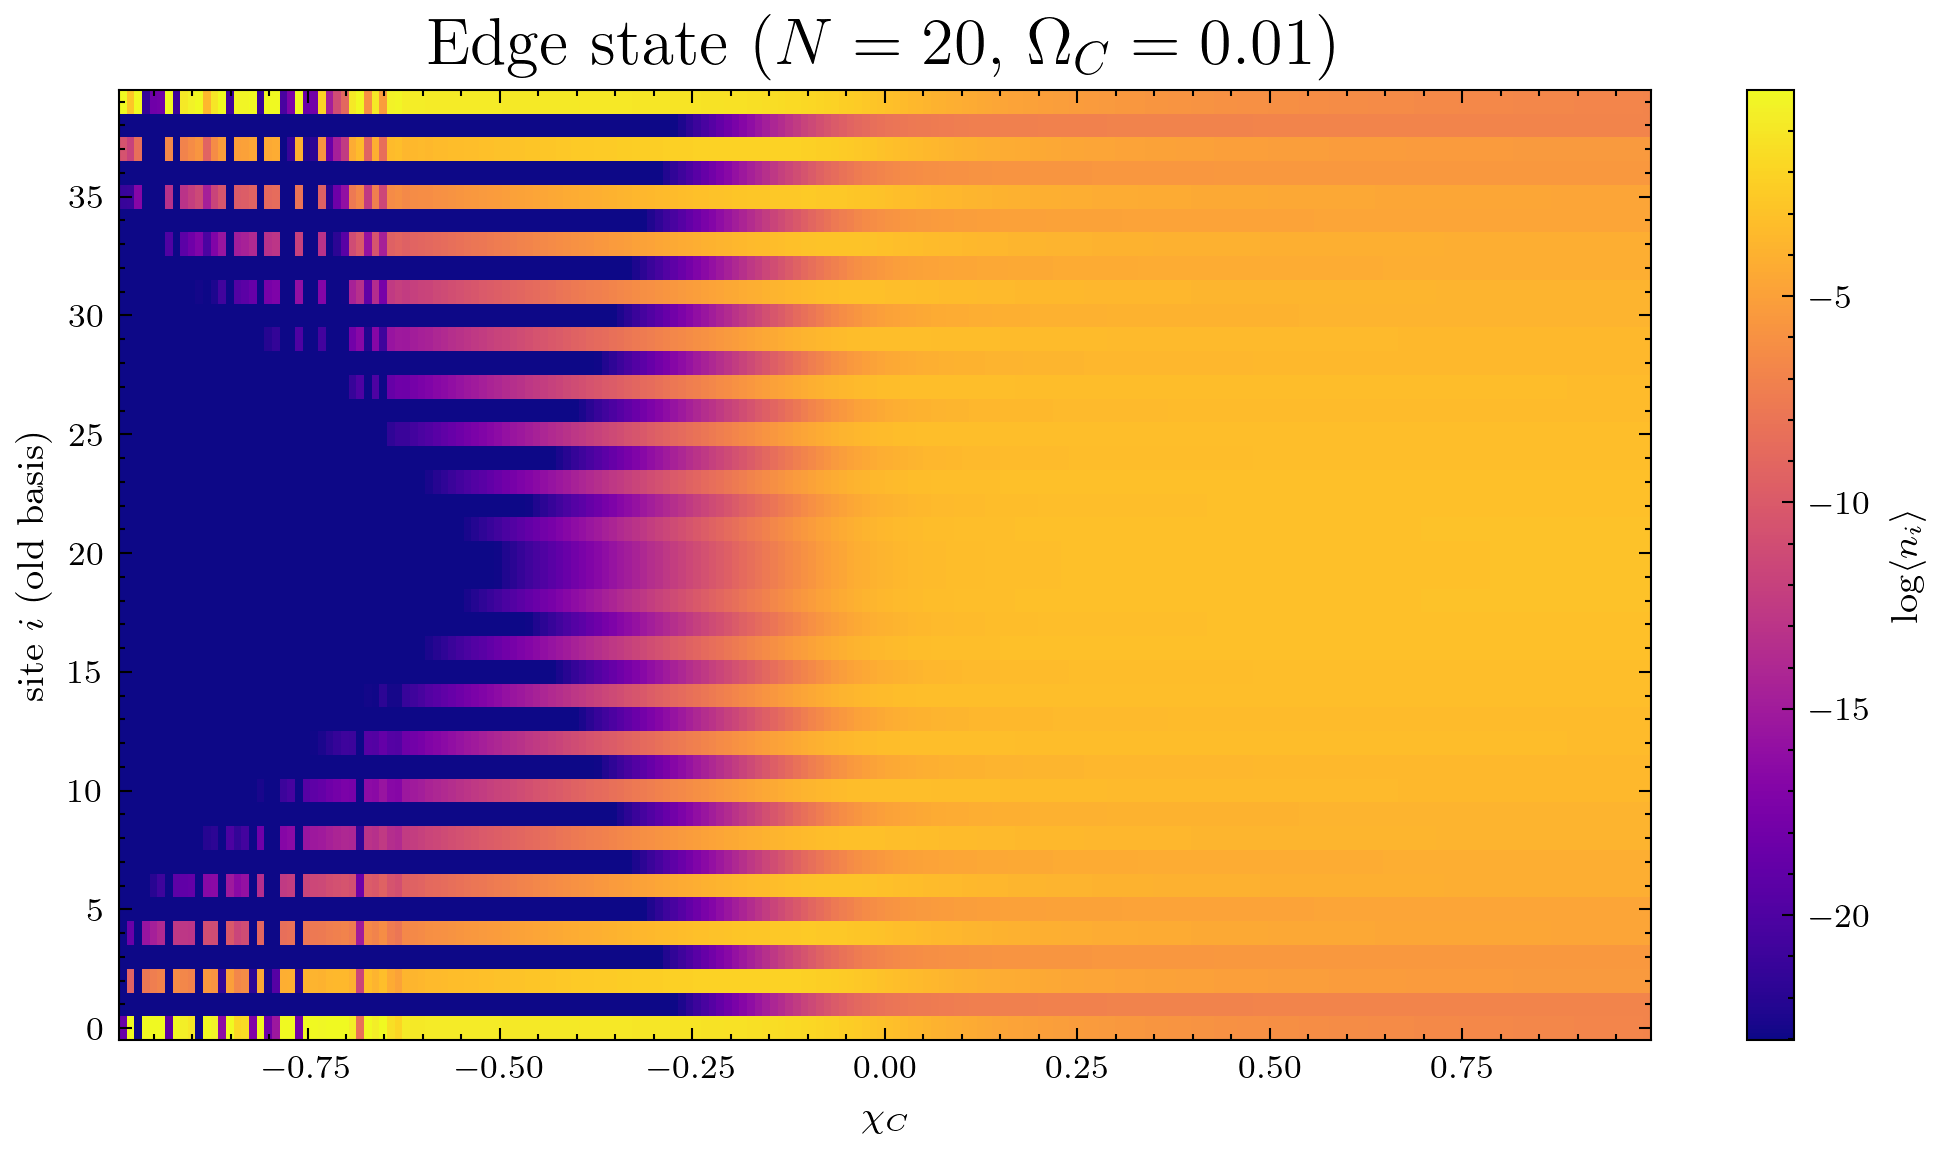

In [358]:
import scipy.sparse.linalg as sla

N_test        = 20
Chi_C_values  = np.linspace(-0.99, 0.99, 200)
edge_choice   = 1        # 0: one edge, 1: other edge
gap_threshold = 2e-3     # safely between 0 (edge) and ~0.003 (bulk)

quanta_distributions = []
diagnostics          = []

for Chi_C in Chi_C_values:

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- eigsh targeting sigma=1.0 ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])

    # select states within gap_threshold of 1.0
    near_mask = np.abs(all_energies - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask              = np.zeros(len(all_energies), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies - 1.0))[:2]] = True
        diagnostics.append('fallback')
    else:
        diagnostics.append('ok')

    V_near = all_states[:, near_mask]
    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(all_energies[near_mask] - 1.0))[:2]
        V_near = V_near[:, best2]

    # --- disambiguation: try sublattice first, fall back to spatial ---
    def make_diag(weights):
        diag = np.zeros(d_mat)
        for exc, arr in chain.fock_states.items():
            offset = chain.fock_offsets[exc]
            for s_idx, state in enumerate(arr):
                diag[offset + s_idx] = sum(
                    n * w for n, w in zip(state, weights))
        return np.tile(diag, d_ph)

    # sublattice: +1 on A (even), -1 on B (odd)
    sublattice_w = [1 if i % 2 == 0 else -1 for i in range(2 * N_test)]
    O_sub        = (V_near.conj().T * make_diag(sublattice_w)) @ V_near
    evals_O, evecs_O = np.linalg.eigh(O_sub)

    if evals_O[0] * evals_O[1] < 0:
        V_localized = V_near @ evecs_O
        diagnostics[-1] += '_sublattice'
    else:
        # fall back to spatial: +1 on left half, -1 on right half
        spatial_w = [1 if i < N_test else -1 for i in range(2 * N_test)]
        O_spa     = (V_near.conj().T * make_diag(spatial_w)) @ V_near
        evals_S, evecs_S = np.linalg.eigh(O_spa)

        if evals_S[0] * evals_S[1] < 0:
            V_localized = V_near @ evecs_S
            diagnostics[-1] += '_spatial'
        else:
            # both failed — states are too mixed, skip
            quanta_distributions.append(np.zeros(2 * N_test))
            diagnostics[-1] += '_failed'
            continue

    evec = V_localized[:, edge_choice]

    # --- matter state -> old basis ---
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat]  = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)
    quanta_distributions.append(dist)

# summary
from collections import Counter
c = Counter(diagnostics)
for k, v in sorted(c.items()):
    print(f"  {k}: {v}")

# plot
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array), cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state ($N={N_test}$, $\Omega_C=0.01$)')
fig.tight_layout()
plt.show()

  fallback_spatial: 43
  fallback_sublattice: 77
  ok_spatial: 3
  ok_sublattice: 77


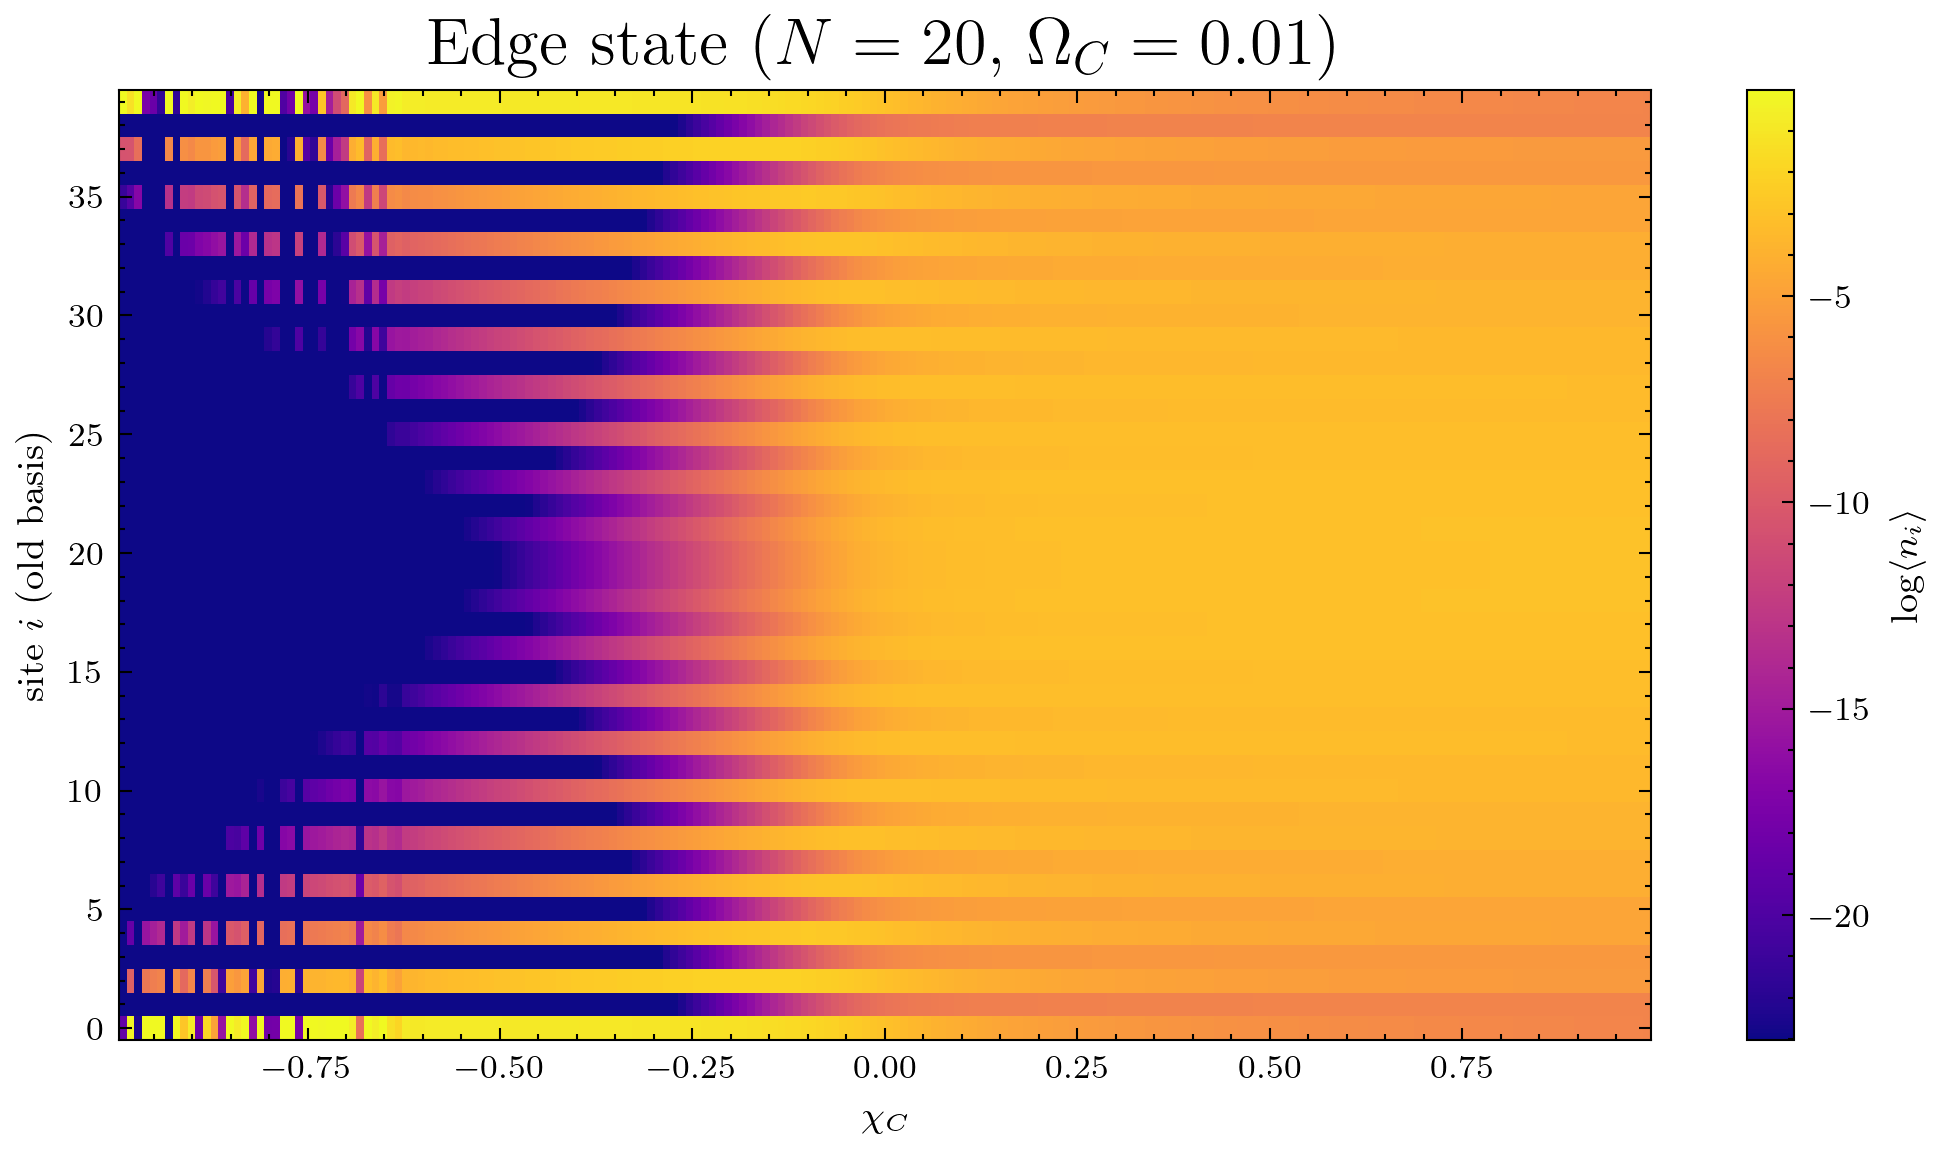

In [359]:
import scipy.sparse.linalg as sla

N_test        = 20
Chi_C_values  = np.linspace(-0.99, 0.99, 200)
edge_choice   = 1        # 0: one edge, 1: other edge
gap_threshold = 2e-3     # safely between 0 (edge) and ~0.003 (bulk)

quanta_distributions = []
diagnostics          = []

for Chi_C in Chi_C_values:

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # --- eigsh targeting sigma=1.0 ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies = np.array(sorted(results.keys()))
    all_states   = np.column_stack([results[e] for e in all_energies])

    # select states within gap_threshold of 1.0
    near_mask = np.abs(all_energies - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask              = np.zeros(len(all_energies), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies - 1.0))[:2]] = True
        diagnostics.append('fallback')
    else:
        diagnostics.append('ok')

    V_near = all_states[:, near_mask]
    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(all_energies[near_mask] - 1.0))[:2]
        V_near = V_near[:, best2]

    # --- disambiguation: try sublattice first, fall back to spatial ---
    def make_diag(weights):
        diag = np.zeros(d_mat)
        for exc, arr in chain.fock_states.items():
            offset = chain.fock_offsets[exc]
            for s_idx, state in enumerate(arr):
                diag[offset + s_idx] = sum(
                    n * w for n, w in zip(state, weights))
        return np.tile(diag, d_ph)

    # sublattice: +1 on A (even), -1 on B (odd)
    sublattice_w = [1 if i % 2 == 0 else -1 for i in range(2 * N_test)]
    O_sub        = (V_near.conj().T * make_diag(sublattice_w)) @ V_near
    evals_O, evecs_O = np.linalg.eigh(O_sub)

    if evals_O[0] * evals_O[1] < 0:
        V_localized = V_near @ evecs_O
        diagnostics[-1] += '_sublattice'
    else:
        # fall back to spatial: +1 on left half, -1 on right half
        spatial_w = [1 if i < N_test else -1 for i in range(2 * N_test)]
        O_spa     = (V_near.conj().T * make_diag(spatial_w)) @ V_near
        evals_S, evecs_S = np.linalg.eigh(O_spa)

        if evals_S[0] * evals_S[1] < 0:
            V_localized = V_near @ evecs_S
            diagnostics[-1] += '_spatial'
        else:
            # both failed — states are too mixed, skip
            quanta_distributions.append(np.zeros(2 * N_test))
            diagnostics[-1] += '_failed'
            continue

    evec = V_localized[:, edge_choice]

    # --- matter state -> old basis ---
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat]  = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)
    quanta_distributions.append(dist)

# summary
from collections import Counter
c = Counter(diagnostics)
for k, v in sorted(c.items()):
    print(f"  {k}: {v}")

# plot
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array), cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state ($N={N_test}$, $\Omega_C=0.01$)')
fig.tight_layout()
plt.show()

In [361]:
import scipy.sparse as sp
def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    This lifts the degeneracy without mixing the states significantly.
    """
    n     = 2 * chain.N
    xi    = n / 4.0   # decay length ~ quarter chain
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # weight per site: +exp on left, -exp on right
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                             for i in range(n)])

    # build diagonal in matter Fock basis
    diag_mat = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            diag_mat[offset + s_idx] = sum(
                ni * site_weights[i] for i, ni in enumerate(state))

    # tensor with photon identity
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')

  fallback: 60
  ok: 140


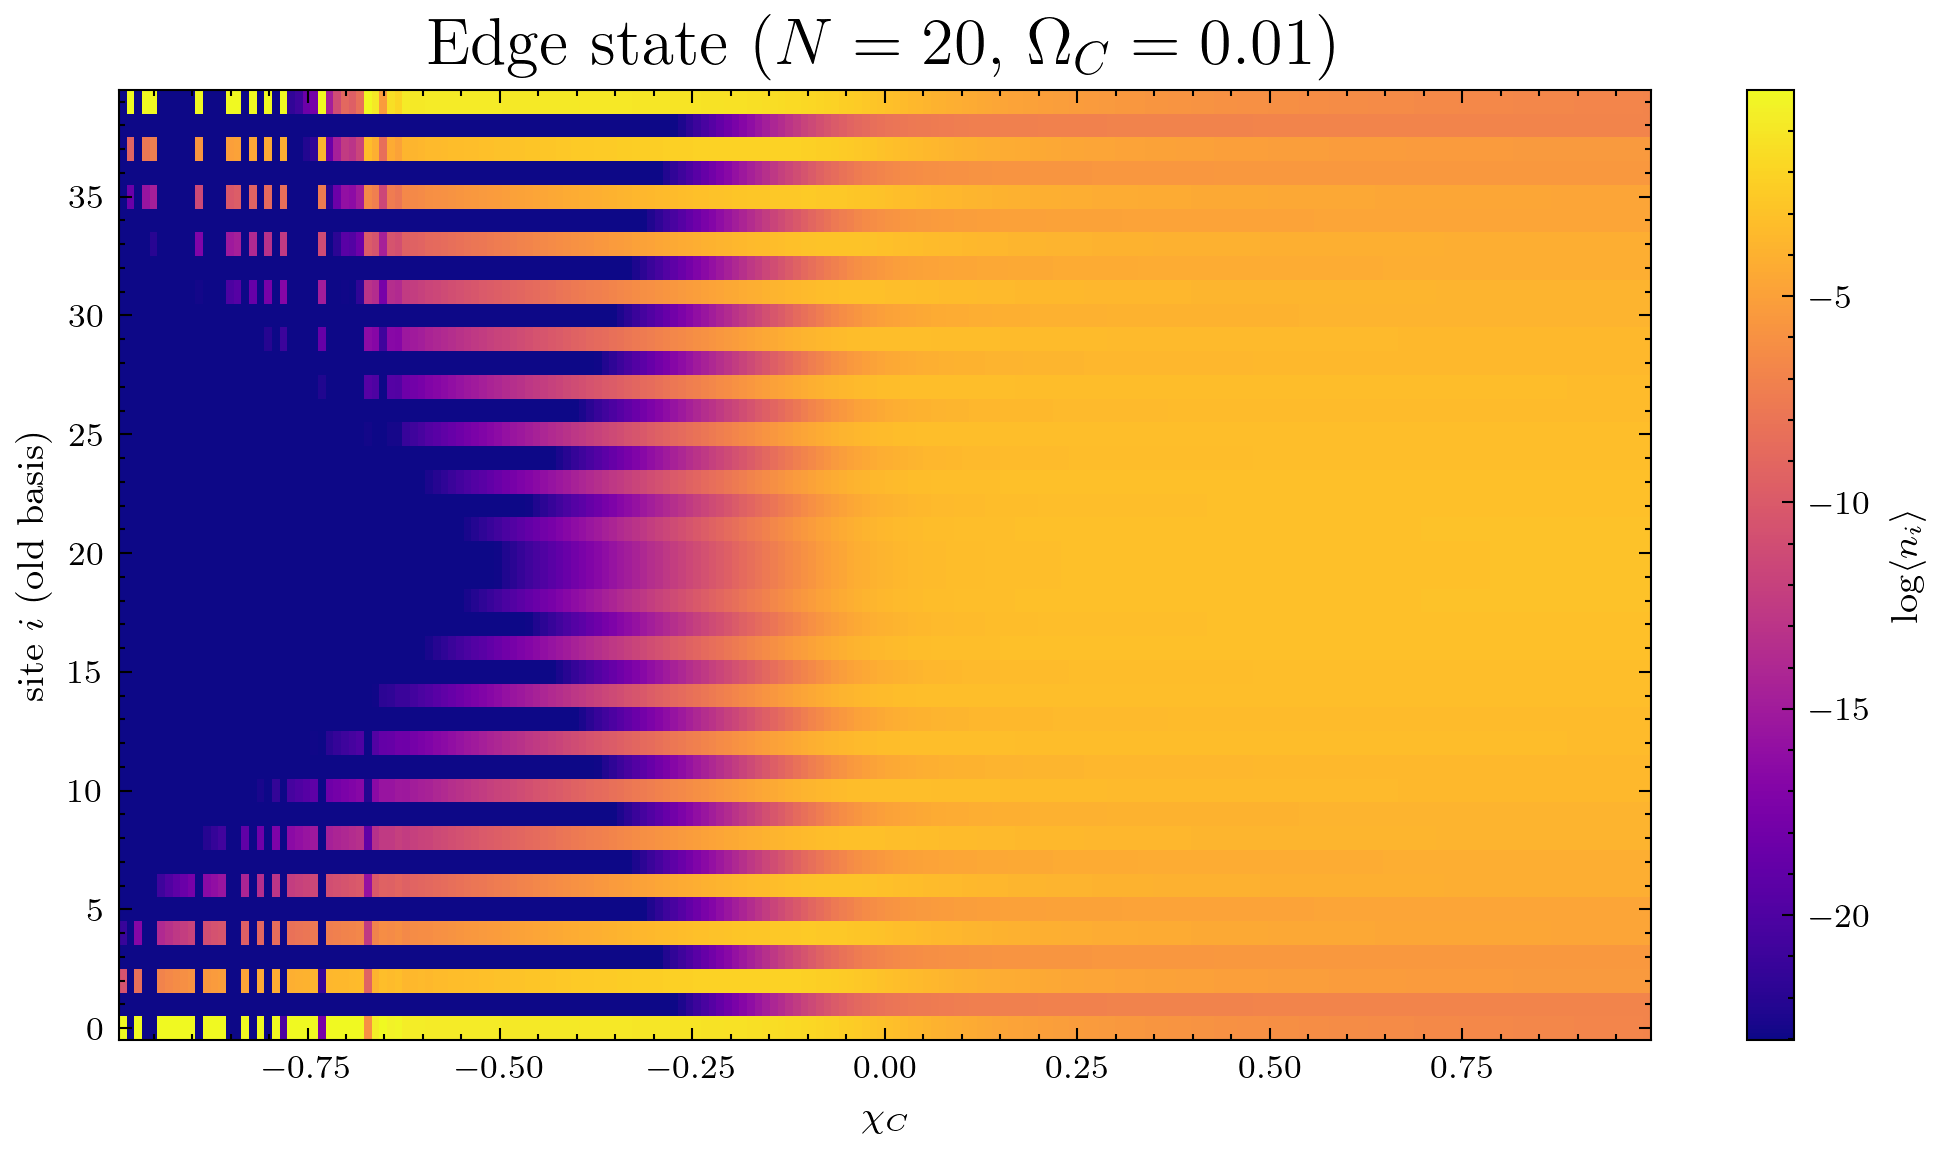

In [373]:
import scipy.sparse.linalg as sla
from collections import Counter

N_test        = 20
Chi_C_values  = np.linspace(-0.99, 0.99, 200)
gap_threshold = 2e-3
edge_choice   = 0    # 0: left-edge state (positive weight), 1: right-edge state

quanta_distributions = []
diagnostics          = []

for Chi_C in Chi_C_values:

    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                  gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    scale = np.exp(10 * np.abs(Chi_C))   # or: 1.0 / (np.abs(1 + Chi_C) + 1e-2)
    # --- add exponential perturbation to lift edge state degeneracy ---
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))
    # scale factor: grows as Chi_C -> -1
    # e.g. exp(alpha * |Chi_C|) or 1/|1 + Chi_C|


    # evals, evecs = sla.eigsh(H_, k=6, sigma=scale * 1.0, which='LM')
    # evals_physical = evals / scale   # rescale back to physical energies
    # --- eigsh on perturbed H ---
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled   = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states            = np.column_stack([results[e] for e in all_energies_scaled])

    # select the two closest to 1.0 in physical units
    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True
        diagnostics.append('fallback')
    else:
        diagnostics.append('ok')

    V_near  = all_states[:, near_mask]
    E_near  = all_energies_physical[near_mask]
    if V_near.shape[1] > 2:
        best2   = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near  = V_near[:, best2]
        E_near  = E_near[best2]

    e_order  = np.argsort(E_near)
    V_sorted = V_near[:, e_order]

    evec = V_sorted[:, edge_choice]

    # --- matter -> old basis ---
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    synth_vec          = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat]  = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    dist = chain.quanta_distribution(old_vec)
    quanta_distributions.append(dist)

c = Counter(diagnostics)
for k, v in sorted(c.items()):
    print(f"  {k}: {v}")

# plot
dist_array = np.clip(np.array(quanta_distributions).T, 1e-10, None)
fig, ax    = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                   np.log(dist_array), cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('site $i$ (old basis)')
ax.set_title(rf'Edge state ($N={N_test}$, $\Omega_C=0.01$)')
fig.tight_layout()
plt.show()

/tmp/ipykernel_34669/650758415.py:45: MatrixRankWarning: Matrix is exactly singular
  v = spsolve(A, v)


    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too small: nan
    [position] eigenvalue split too small: nan
    [sublattice] eigenvalue split too sm

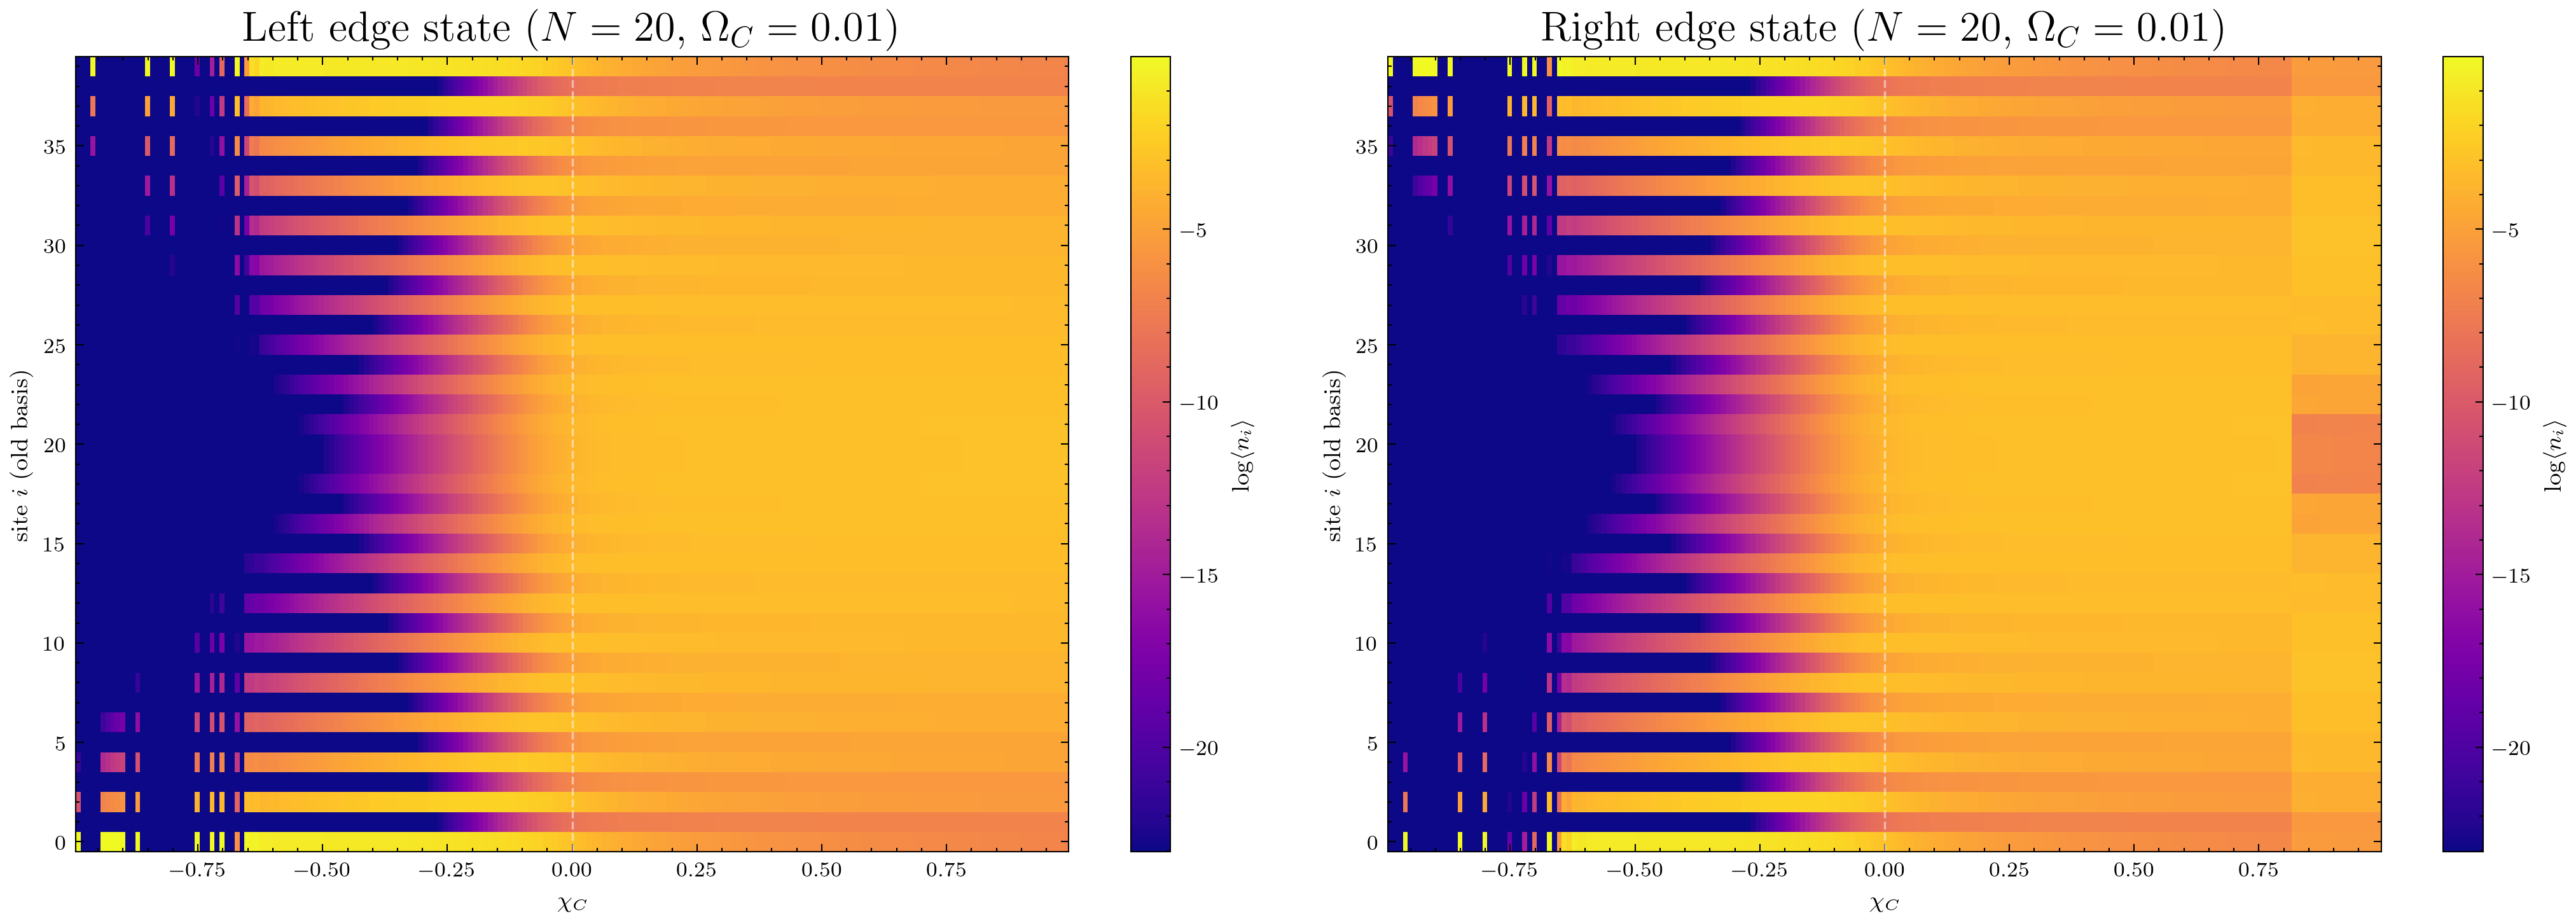

In [ ]:
import scipy.sparse.linalg as sla
from collections import Counter

# ── helpers ────────────────────────────────────────────────────────────────────

def make_sublattice_operator(chain):
    """S = Σ_i (-1)^i n_i  in the full H_ph ⊗ H_matter space."""
    n      = 2 * chain.N
    d_ph   = chain.fock_photon
    d_mat  = chain.fock_dim
    signs  = np.array([(-1)**i for i in range(n)], dtype=float)

    S_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            S_diag[offset + s_idx] = signs @ state

    S_matter = sp.diags(S_diag, format='csr')
    return sp.kron(sp.eye(d_ph, format='csr'), S_matter, format='csr')


def make_position_operator(chain):
    """X = Σ_i i * n_i  in the full H_ph ⊗ H_matter space."""
    n      = 2 * chain.N
    d_ph   = chain.fock_photon
    d_mat  = chain.fock_dim
    pos    = np.arange(n, dtype=float)

    X_diag = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            X_diag[offset + s_idx] = pos @ state

    X_matter = sp.diags(X_diag, format='csr')
    return sp.kron(sp.eye(d_ph, format='csr'), X_matter, format='csr')


def inverse_iterate(H, v, sigma, n_steps=5):
    """Purifies v toward the eigenstate nearest sigma via inverse iteration."""
    from scipy.sparse.linalg import spsolve
    A = (H - sigma * sp.eye(H.shape[0], format='csr')).tocsr()
    for _ in range(n_steps):
        v = spsolve(A, v)
        v /= np.linalg.norm(v)
    return v


def lift_degeneracy(V_near, operator, label='operator'):
    """
    Projects `operator` onto the degenerate subspace spanned by columns of V_near,
    diagonalizes the resulting 2x2 matrix, and returns the rotated eigenvectors
    sorted by eigenvalue (ascending).
    Returns (V_rotated, eigenvalues, success_flag).
    """
    O_sub   = V_near.conj().T @ operator @ V_near          # 2x2
    o_vals, o_vecs = np.linalg.eigh(O_sub)
    V_rot   = V_near @ o_vecs
    # check that eigenvalues are actually split
    split   = abs(o_vals[1] - o_vals[0])
    success = split > 1e-6
    if not success:
        print(f"    [{label}] eigenvalue split too small: {split:.2e}")
    return V_rot, o_vals, success


def get_edge_states(chain, H, gap_threshold=2e-3, n_steps_inv=6):
    """
    Finds the two degenerate edge states near E=1 using a cascade of strategies:
      1. eigsh with multiple sigma values
      2. inverse iteration to purify candidates
      3. sublattice operator to lift degeneracy
      4. position operator as fallback
    Returns (evec_left, evec_right, status_string).
    """
    d     = H.shape[0]
    sigma = 1.0

    # ── step 1: collect candidates from multiple sigma targets ─────────────────
    results = {}
    for sigma_try in [1.0, 1.0 + 5e-4, 1.0 - 5e-4, 1.0 + 2e-3, 1.0 - 2e-3]:
        try:
            evals, evecs = sla.eigsh(H, k=6, sigma=sigma_try, which='LM',
                                     tol=1e-12, maxiter=20000, ncv=50)
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-10 for e2 in results):
                    results[e] = evecs[:, i]
        except Exception:
            continue

    if len(results) < 2:
        return None, None, 'eigsh_failed'

    all_evals = np.array(sorted(results.keys()))
    all_evecs = np.column_stack([results[e] for e in all_evals])

    # select candidates near E=1
    near_mask = np.abs(all_evals - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        # fallback: take 2 closest
        near_mask = np.zeros(len(all_evals), dtype=bool)
        near_mask[np.argsort(np.abs(all_evals - 1.0))[:2]] = True
        status_prefix = 'fallback_gap'
    else:
        status_prefix = 'ok'

    V_near = all_evecs[:, near_mask]
    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(all_evals[near_mask] - 1.0))[:2]
        V_near = V_near[:, best2]

    # ── step 2: inverse iteration to purify each candidate ────────────────────
    V_purified = np.column_stack([
        inverse_iterate(H, V_near[:, i], sigma=1.0, n_steps=n_steps_inv)
        for i in range(V_near.shape[1])
    ])
    # re-orthogonalize
    V_purified, _ = np.linalg.qr(V_purified)

    # ── step 3: sublattice operator ────────────────────────────────────────────
    S_op = make_sublattice_operator(chain)
    V_rot, s_vals, s_ok = lift_degeneracy(V_purified, S_op, label='sublattice')
    if s_ok:
        # s_vals[0] < 0 → right edge (B-sublattice), s_vals[1] > 0 → left edge (A-sublattice)
        evec_left  = V_rot[:, 1]   # positive sublattice eigenvalue → A sites → left
        evec_right = V_rot[:, 0]   # negative → B sites → right
        return evec_left, evec_right, status_prefix + '_sublattice'

    # ── step 4: position operator fallback ────────────────────────────────────
    X_op = make_position_operator(chain)
    V_rot, x_vals, x_ok = lift_degeneracy(V_purified, X_op, label='position')
    if x_ok:
        # x_vals[0] small → left edge, x_vals[1] large → right edge
        evec_left  = V_rot[:, 0]
        evec_right = V_rot[:, 1]
        return evec_left, evec_right, status_prefix + '_position'

    # ── step 5: just return purified columns as-is (best effort) ──────────────
    return V_purified[:, 0], V_purified[:, 1], status_prefix + '_unprojected'


def evec_to_quanta_dist(chain, evec):
    """
    Takes a full eigenvector, partial-traces over photon, extracts leading
    matter eigenvector, converts to old Fock basis, returns quanta distribution.
    """
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # embed into full space (photon sector 0)
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if exc in chain.fock_state_index and state_tuple in chain.fock_state_index[exc]:
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    return chain.quanta_distribution(old_vec)




In [376]:
def inverse_iterate(H, v, sigma, n_steps=5, sigma_shift=1e-8):
    """Purifies v toward the eigenstate nearest sigma via inverse iteration.
    Uses a small shift to avoid exact singularity."""
    from scipy.sparse.linalg import spsolve
    A = (H - (sigma + sigma_shift) * sp.eye(H.shape[0], format='csr')).tocsr()
    for _ in range(n_steps):
        try:
            v = spsolve(A, v)
            norm = np.linalg.norm(v)
            if norm < 1e-14:
                break
            v /= norm
        except Exception:
            break
    return v


def get_edge_states(chain, H, gap_threshold=2e-3, n_steps_inv=8):
    d = H.shape[0]

    # ── step 1: collect candidates ─────────────────────────────────────────────
    results = {}
    for sigma_try in [1.0, 1.0 + 5e-4, 1.0 - 5e-4, 1.0 + 2e-3, 1.0 - 2e-3]:
        try:
            evals, evecs = sla.eigsh(H, k=6, sigma=sigma_try, which='LM',
                                     tol=1e-12, maxiter=20000, ncv=50)
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-10 for e2 in results):
                    results[e] = evecs[:, i]
        except Exception:
            continue

    if len(results) < 2:
        return None, None, 'eigsh_failed'

    all_evals = np.array(sorted(results.keys()))
    all_evecs = np.column_stack([results[e] for e in all_evals])

    near_mask = np.abs(all_evals - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_evals), dtype=bool)
        near_mask[np.argsort(np.abs(all_evals - 1.0))[:2]] = True
        status_prefix = 'fallback_gap'
    else:
        status_prefix = 'ok'

    V_near = all_evecs[:, near_mask]
    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(all_evals[near_mask] - 1.0))[:2]
        V_near = V_near[:, best2]

    # ── step 2: inverse iteration with shift to avoid singularity ─────────────
    # try both signs of shift and pick the one that gives better purification
    V_purified_list = []
    for shift in [+1e-7, -1e-7, +1e-6, -1e-6]:
        try:
            cols = np.column_stack([
                inverse_iterate(H, V_near[:, i], sigma=1.0,
                                n_steps=n_steps_inv, sigma_shift=shift)
                for i in range(V_near.shape[1])
            ])
            V_purified_list.append(cols)
        except Exception:
            continue

    if not V_purified_list:
        V_purified = V_near
    else:
        # pick the purification with smallest residual ||H v - v||
        best_res  = np.inf
        V_purified = V_near
        for V_cand in V_purified_list:
            V_q, _ = np.linalg.qr(V_cand)
            res = sum(np.linalg.norm(H @ V_q[:, i] - V_q[:, i])
                      for i in range(V_q.shape[1]))
            if res < best_res:
                best_res   = res
                V_purified = V_q

    V_purified, _ = np.linalg.qr(V_purified)

    # ── step 3: position operator to split left/right ─────────────────────────
    # X = Σ_i i * n_i  distinguishes left (small <X>) from right (large <X>)
    X_op = make_position_operator(chain)
    X_sub = V_purified.conj().T @ X_op @ V_purified   # 2x2
    x_vals, x_vecs = np.linalg.eigh(X_sub)
    split = abs(x_vals[1] - x_vals[0])

    if split > 1e-3:
        V_rot      = V_purified @ x_vecs
        evec_left  = V_rot[:, 0]   # smaller <X> → left edge
        evec_right = V_rot[:, 1]   # larger  <X> → right edge
        return evec_left, evec_right, status_prefix + '_position'

    # ── step 4: sublattice as secondary fallback ───────────────────────────────
    # (less reliable for left/right but better than nothing)
    S_op  = make_sublattice_operator(chain)
    S_sub = V_purified.conj().T @ S_op @ V_purified
    s_vals, s_vecs = np.linalg.eigh(S_sub)
    split_s = abs(s_vals[1] - s_vals[0])

    if split_s > 1e-3:
        V_rot      = V_purified @ s_vecs
        evec_left  = V_rot[:, 1]
        evec_right = V_rot[:, 0]
        return evec_left, evec_right, status_prefix + '_sublattice_fallback'

    # ── step 5: unprojected best effort ───────────────────────────────────────
    return V_purified[:, 0], V_purified[:, 1], status_prefix + '_unprojected'

Status breakdown:
  fallback_gap_position: 118
  ok_position: 82


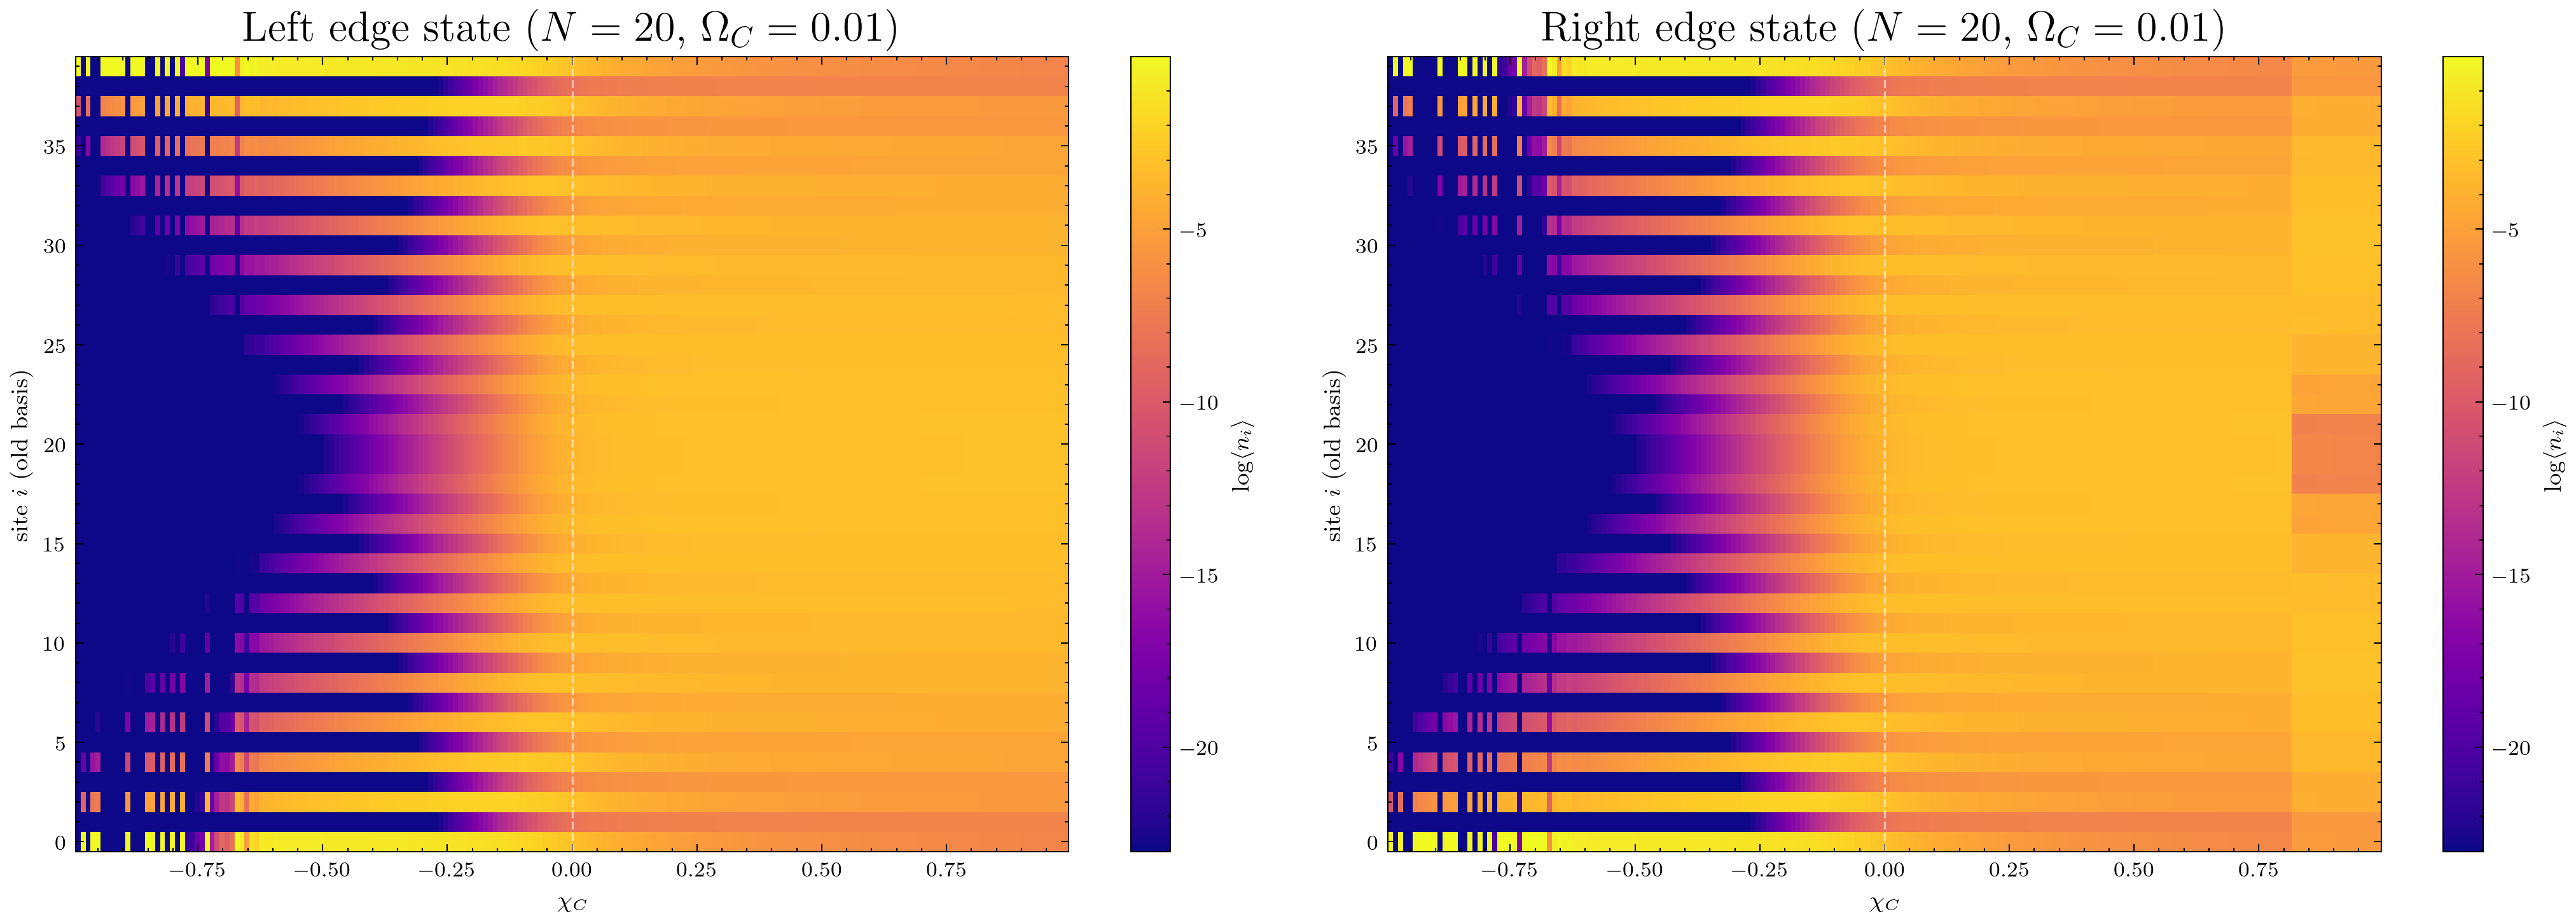

In [377]:
# ── main sweep ─────────────────────────────────────────────────────────────────

N_test       = 20
Chi_C_values = np.linspace(-0.99, 0.99, 200)

quanta_left  = []
quanta_right = []
statuses     = []

for Chi_C in Chi_C_values:
    chain = model(N_test, Omega_C=0.01, Chi_C=Chi_C, omega_r=10.0,
                          gamma=0.0, fock_photon=1, Omega_J=1.0, Chi_J=0.0, PBC=False)
    chain.matter_hamiltonians(n_excitations=1, layers=0)
    chain.build_full_hamiltonian()
    chain.build_squeezed_vacuum(truncation=1, threshold=0.99)

    evec_left, evec_right, status = get_edge_states(chain, chain.H, gap_threshold=2e-3)
    statuses.append(status)

    if evec_left is None:
        quanta_left.append(np.full(2 * N_test, np.nan))
        quanta_right.append(np.full(2 * N_test, np.nan))
        continue

    quanta_left.append(evec_to_quanta_dist(chain, evec_left))
    quanta_right.append(evec_to_quanta_dist(chain, evec_right))

# ── diagnostics ────────────────────────────────────────────────────────────────
c = Counter(statuses)
print("Status breakdown:")
for k, v in sorted(c.items()):
    print(f"  {k}: {v}")

# ── plot both edge states ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dist_list, title in zip(
    axes,
    [quanta_left, quanta_right],
    ['Left edge state', 'Right edge state']
):
    arr = np.clip(np.array(dist_list).T, 1e-10, None)
    im  = ax.pcolormesh(Chi_C_values, np.arange(2 * N_test),
                        np.log(arr), cmap='plasma', shading='auto')
    plt.colorbar(im, ax=ax, label=r'$\log\langle n_i \rangle$')
    ax.set_xlabel(r'$\chi_C$')
    ax.set_ylabel('site $i$ (old basis)')
    ax.set_title(rf'{title} ($N={N_test}$, $\Omega_C=0.01$)')
    ax.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5)

fig.tight_layout()
plt.show()

In [336]:
# --- robust approach: get more states and filter by IPR ---
for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
    try:
        energies, states = sla.eigsh(chain.H, k=10, sigma=sigma_try, which='LM')
        break
    except RuntimeError:
        continue

idx_sort = np.argsort(energies)
energies = energies[idx_sort]
states   = states[:, idx_sort]

# compute IPR for each state and pick the two most localized
iprs = []
for col in range(states.shape[1]):
    rho_m = chain.partial_trace(states[:, col], which_to_keep='matter')
    evals_rho, evecs_rho = np.linalg.eigh(rho_m)
    mv = evecs_rho[:, -1]
    ipr, _, _ = chain.quanta_ipr(mv)
    iprs.append(ipr)

iprs = np.array(iprs)
print(f"IPRs: {iprs}")
print(f"Energies: {energies}")

# take the two highest-IPR states
edge_mask   = np.argsort(iprs)[-2:]
V_localized = states[:, edge_mask]
E_localized = energies[edge_mask]
print(f"Selected edge state energies: {E_localized}")
print(f"Selected IPRs: {iprs[edge_mask]}")

IPRs: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Energies: [1.00493809 1.00493892 1.00494028 1.00494215 1.00494448 1.00494721
 1.00495029 1.00495365 1.0049572  1.00496088]
Selected edge state energies: [1.0049572  1.00496088]
Selected IPRs: [1. 1.]


In [337]:
results = {}
for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4]:
    for delta in [0, 1e-3, -1e-3, 1e-2, -1e-2]:
        try:
            evals, evecs = sla.eigsh(chain.H, k=6, sigma=sigma_try + delta, which='LM')
            for i, e in enumerate(evals):
                # deduplicate: only keep if no existing result is within 1e-6
                if not any(abs(e - e2) < 1e-6 for e2 in results):
                    results[e] = evecs[:, i]
            break
        except RuntimeError:
            continue

# sort all found states by energy
all_energies = np.array(sorted(results.keys()))
all_states   = np.array([results[e] for e in all_energies]).T

print(f"Found {len(all_energies)} distinct states")
print(f"Energies: {all_energies}")
print(f"Spread around 1.0: {all_energies - 1.0}")

# now pick the two closest to 1.0 from both sides
edge_mask = np.argsort(np.abs(all_energies - 1.0))[:2]
V_edge    = all_states[:, edge_mask]
E_edge    = all_energies[edge_mask]
print(f"Edge pair energies: {E_edge}")
print(f"Symmetric? {E_edge[0] + E_edge[1] - 2.0:.2e}  (should be ~0)")

Found 10 distinct states
Energies: [0.99502819 0.99503095 0.9950333  0.99503519 0.99503657 1.00493809
 1.00494028 1.00494215 1.00494448 1.00494721]
Spread around 1.0: [-0.00497181 -0.00496905 -0.0049667  -0.00496481 -0.00496343  0.00493809
  0.00494028  0.00494215  0.00494448  0.00494721]
Edge pair energies: [1.00493809 1.00494028]
Symmetric? 9.88e-03  (should be ~0)


In [338]:
above = all_energies[all_energies > 1.0]
below = all_energies[all_energies < 1.0]
e_above = above.min()   # closest from above
e_below = below.max()   # closest from below
print(f"Edge pair: {e_below:.8f}  {e_above:.8f}")
print(f"Symmetric check: {e_above + e_below - 2.0:.2e}")

V_edge = np.column_stack([results[e_below], results[e_above]])

Edge pair: 0.99503657  1.00493809
Symmetric check: -2.53e-05


In [333]:
print(4*(energies-1)/Omega_C)

[0.06584118 0.06585226]


In [80]:
print(list(edge_state_old)[-1])

(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1))


/tmp/ipykernel_34669/2711781066.py:1: RuntimeWarning: divide by zero encountered in log
  im = plt.pcolormesh(Chi_C_values, np.arange(2 * N_test), np.log(np.array(quanta_distributions).T))


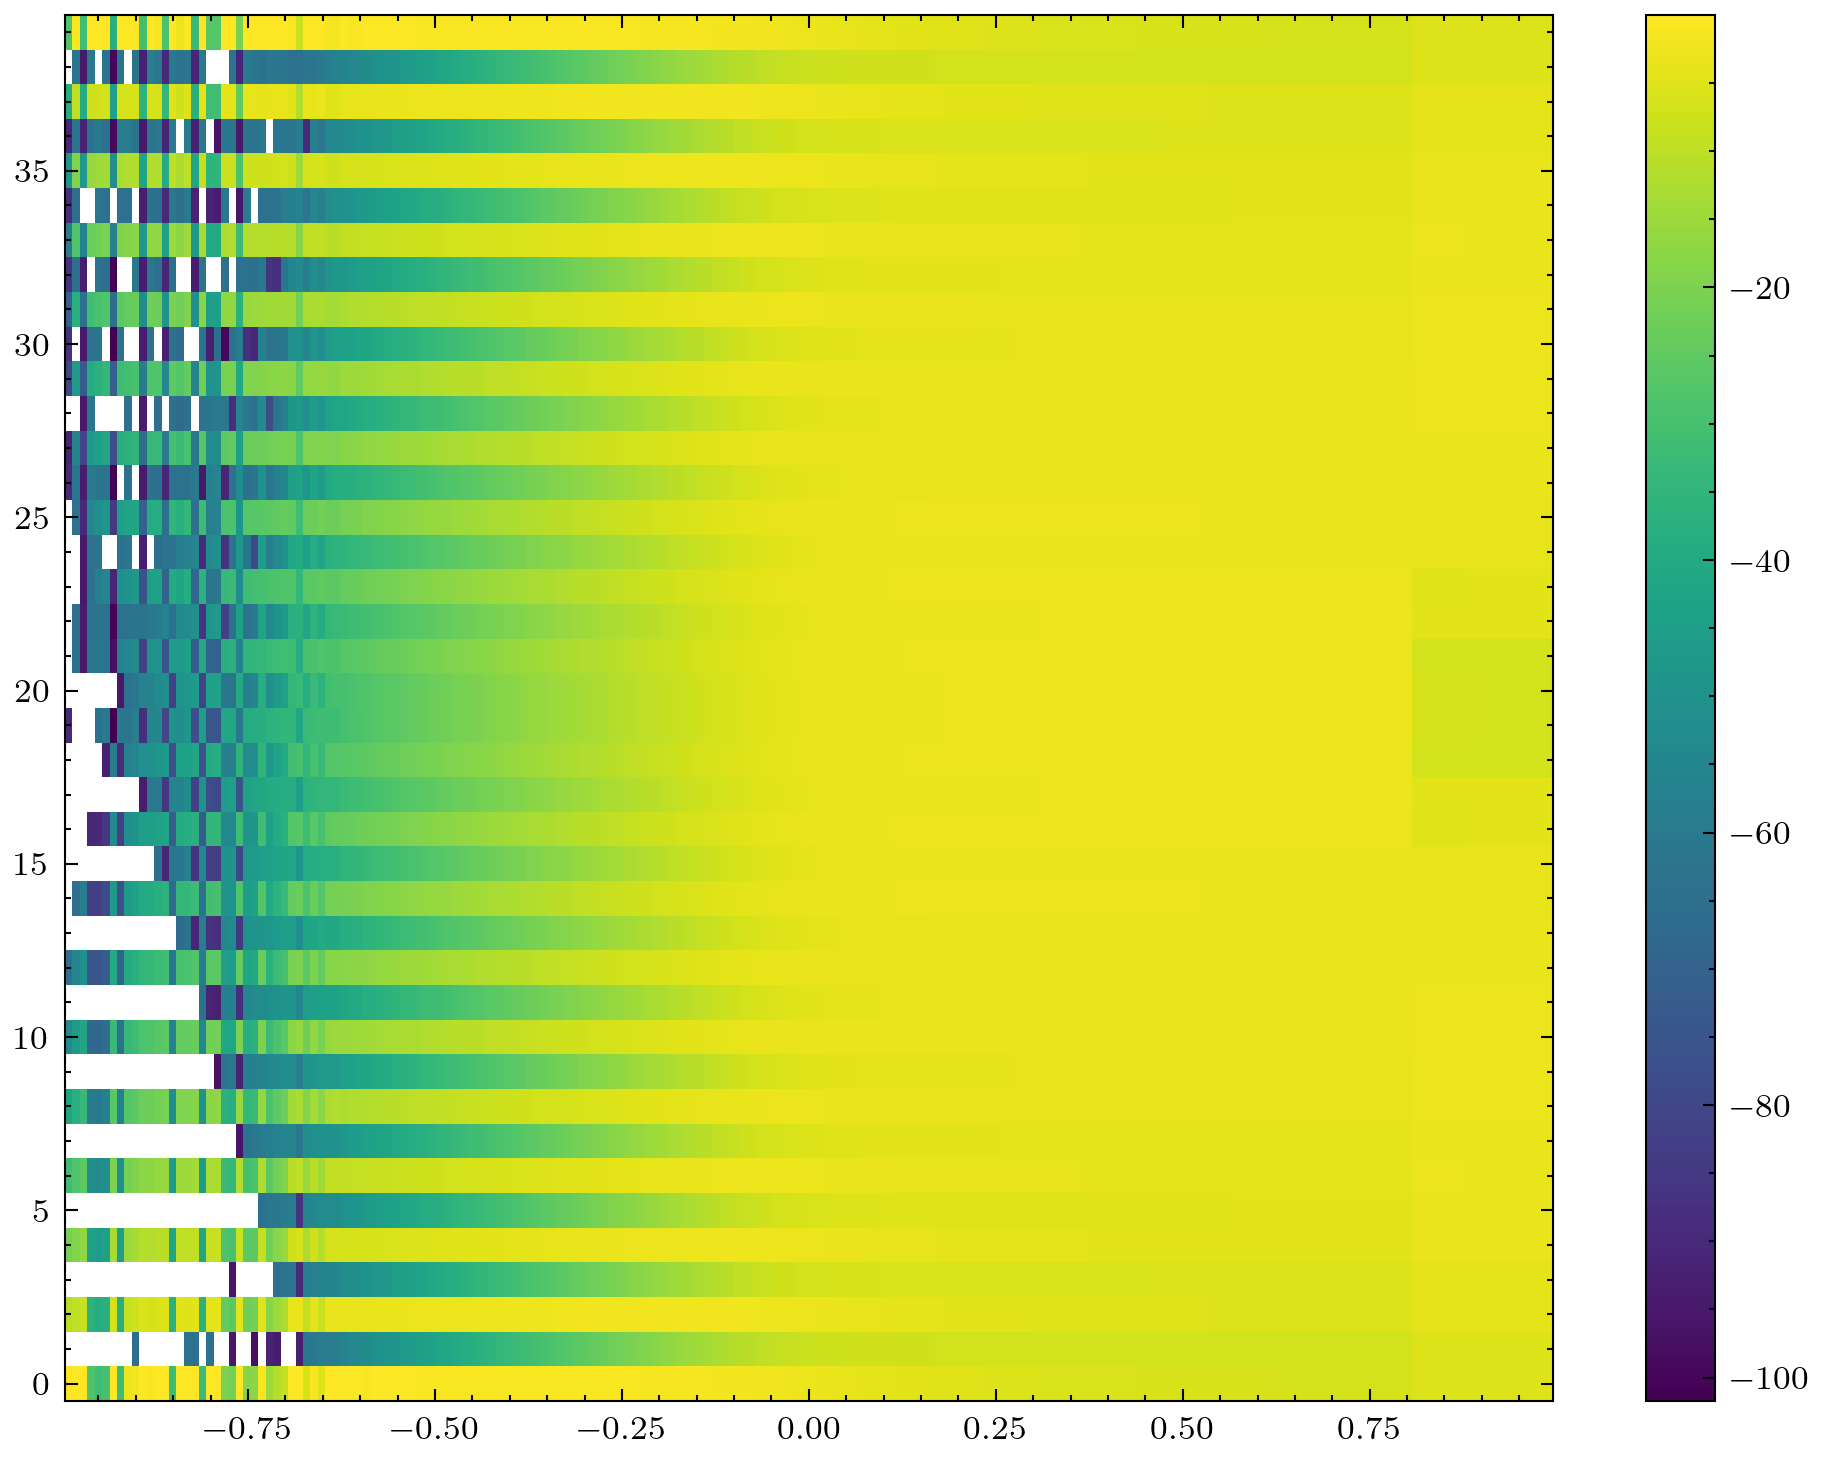

In [330]:
im = plt.pcolormesh(Chi_C_values, np.arange(2 * N_test), np.log(np.array(quanta_distributions).T))
plt.colorbar(im)

<>:31: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:31: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_34669/1553511732.py:31: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_title('Wavefunction Distribution evolution by $\chi_C$')
/tmp/ipykernel_34669/1553511732.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma') # 'magma', 'plasma', or 'viridis' work well


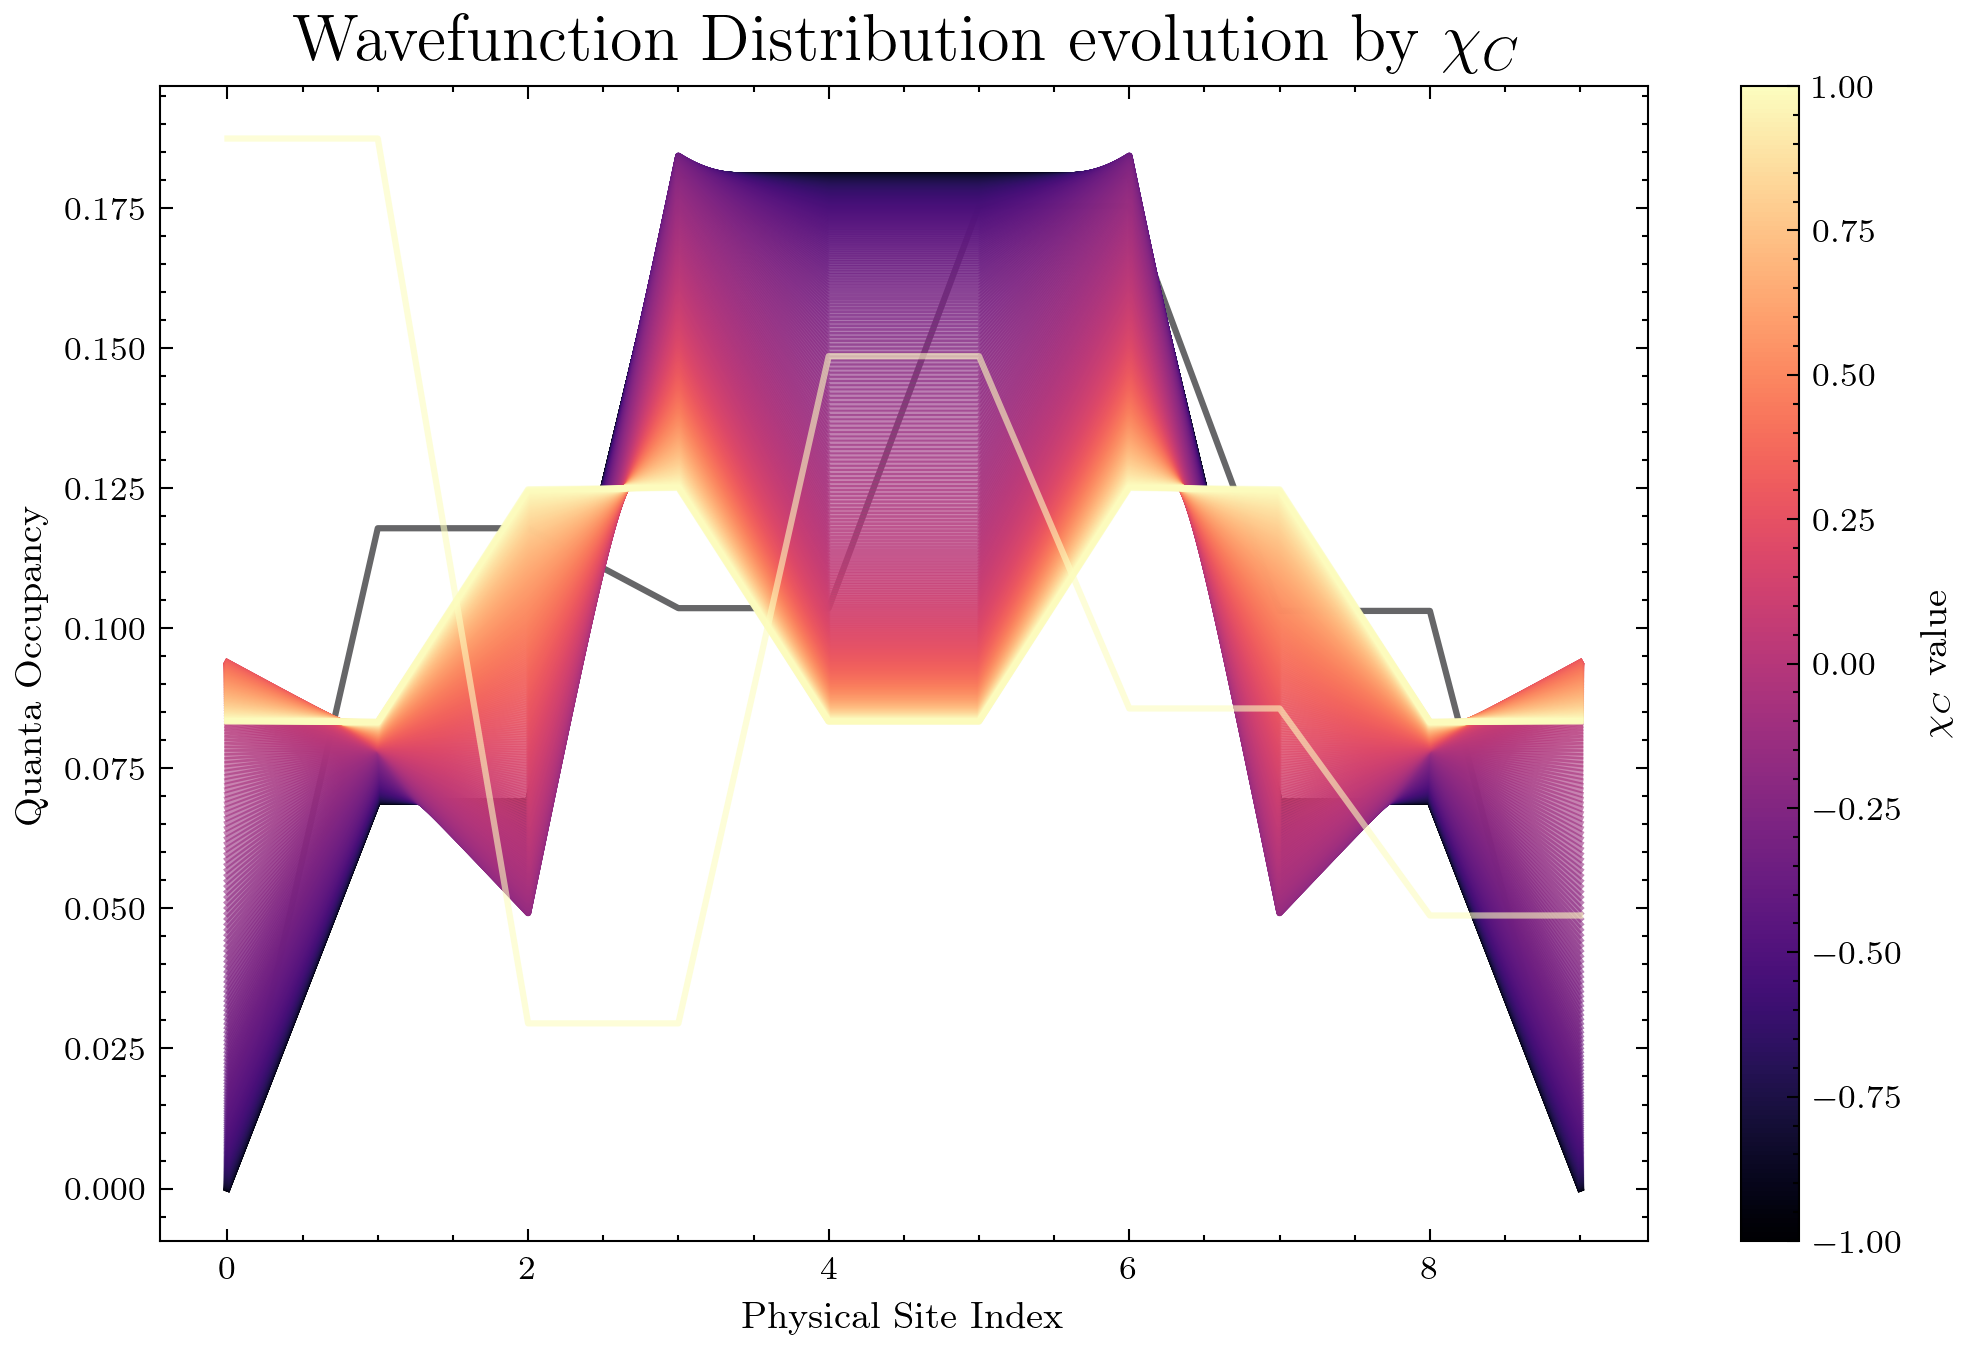

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Setup the colormap
# Normalize Chi_C_values to [0, 1] for the colormap
norm = mcolors.Normalize(vmin=Chi_C_values.min(), vmax=Chi_C_values.max())
cmap = cm.get_cmap('magma') # 'magma', 'plasma', or 'viridis' work well

fig, ax = plt.subplots(figsize=(8, 5))

# 2. Iterate through each Chi_C calculation
# quanta_distributions is a list of arrays, each of shape (N_test,)
for i, Chi_C in enumerate(Chi_C_values):
    dist = quanta_distributions[i]
    
    # Get color based on the current Chi_C
    color = cmap(norm(Chi_C))
    
    # Plot site index (x) vs occupation (y)
    ax.plot(np.arange(2*N_test), dist, color=color, alpha=0.6, linewidth=1.5)

# 3. Add a colorbar to interpret the colors
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$\chi_C$ value')

ax.set_xlabel('Physical Site Index')
ax.set_ylabel('Quanta Occupancy')
ax.set_title('Wavefunction Distribution evolution by $\chi_C$')
plt.show()

<>:40: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:40: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_33048/2072465224.py:40: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_title('Edge State Localization vs $\chi_C$')


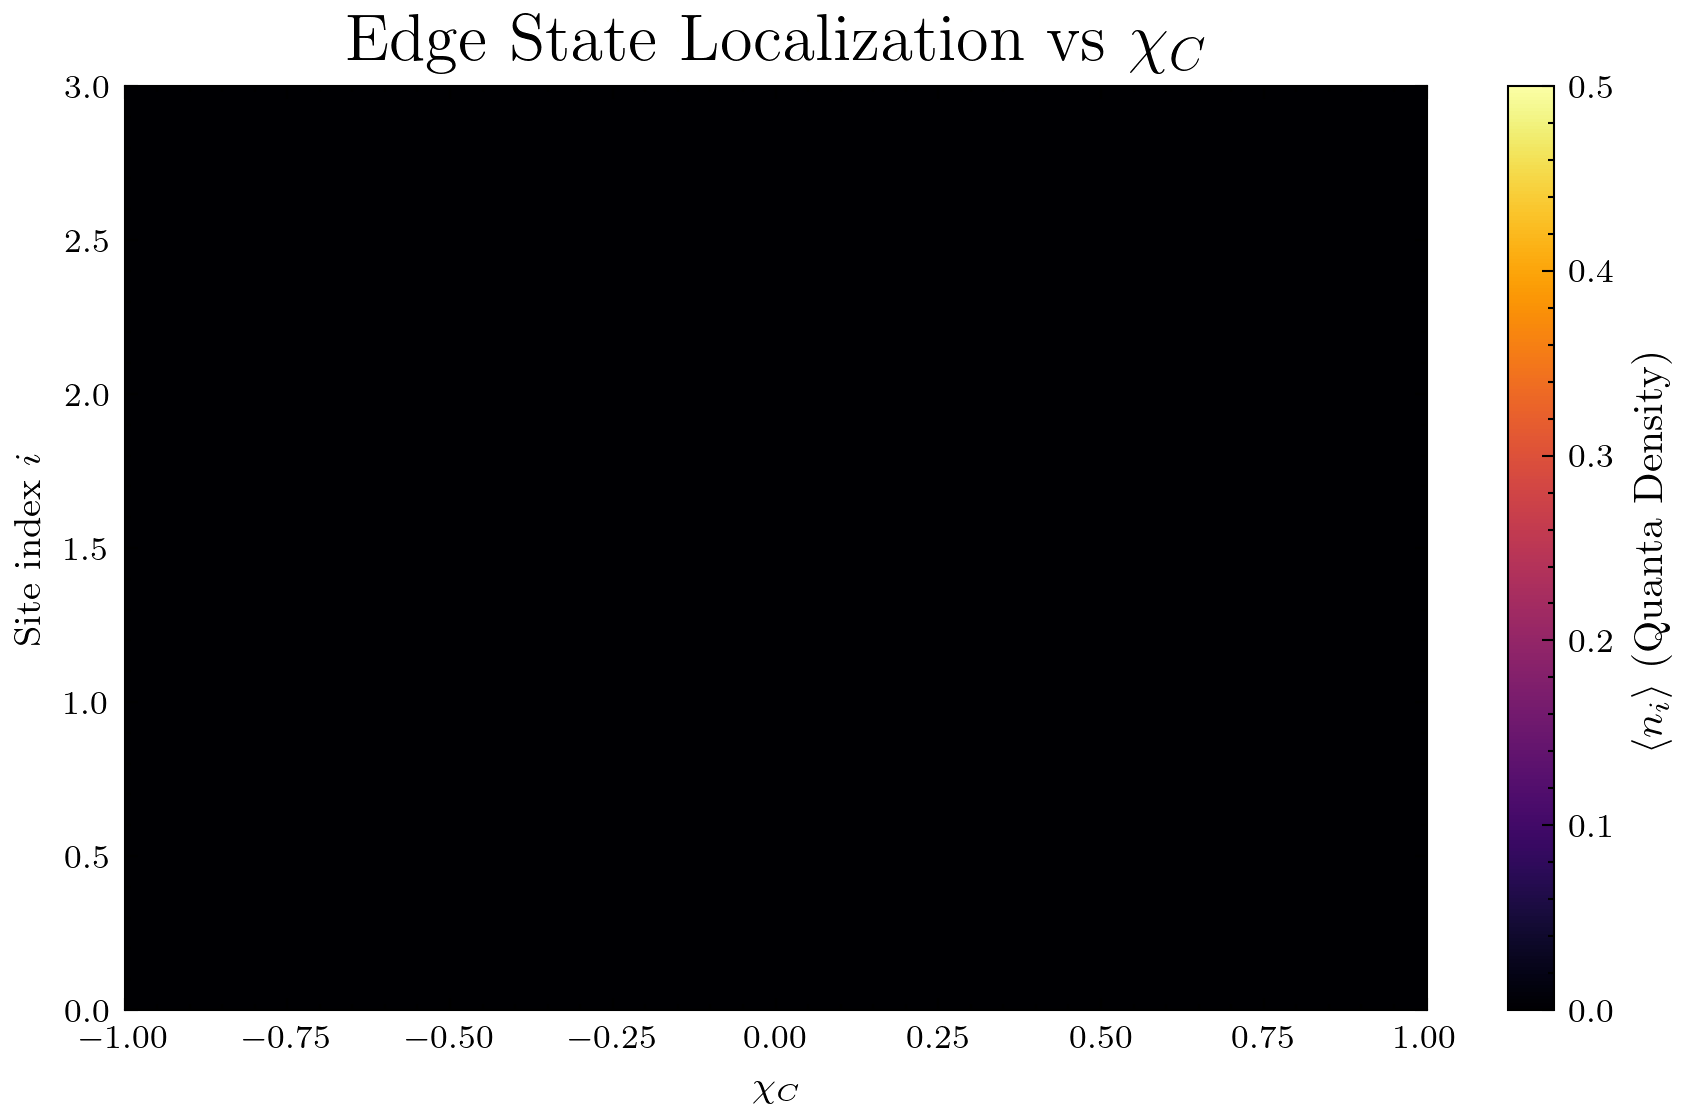

In [ ]:
# ------------------------------------------------------------------ #
# Plot: Edge State Quanta Distribution vs Chi_C
# ------------------------------------------------------------------ #

# 1. Pre-allocate storage
# Shape: (n_chi_steps, N)
Chi_C_values = np.linspace(-1.0, 1.0, 20)
distribution_map = np.zeros((len(Chi_C_values), N))

# 2. Iterate and extract
for i, Chi_C in enumerate(Chi_C_values):
    # Re-initialize or use cached chain
    chain.chi_c = Chi_C # Update parameter
    chain.build_full_hamiltonian()
    
    # Get the specific edge state (lowest energy eigenvector)
    vals, vecs = chain.get_low_lying_spectrum(k=1)
    evec = vecs[:, 0]
    
    # Partial trace to get matter sector
    rho = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho = np.linalg.eigh(rho)
    matter_vec = evecs_rho[:, -1]
    
    # Extract distribution (assuming your function returns an array)
    dist = chain.quanta_distribution(matter_vec)
    # 1. Pre-allocate using chain.fock_dim instead of N
    distribution_map = np.zeros((len(Chi_C_values), chain.fock_dim))

# 3. Plotting the heatmap
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(distribution_map.T, aspect='auto', origin='lower',
               extent=[Chi_C_values[0], Chi_C_values[-1], 0, N-1],
               cmap='inferno', vmin=0, vmax=0.5)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\langle n_i \rangle$ (Quanta Density)', fontsize=10)
ax.set_xlabel(r'$\chi_C$')
ax.set_ylabel('Site index $i$')
ax.set_title('Edge State Localization vs $\chi_C$')
plt.show()